In [3]:
# -*- coding: utf-8 -*-
"""
NKPC HSA decomposition via state-space model with FFBS Gibbs sampler
Python translation of the provided MATLAB code.

Dependencies:
  numpy
  scipy

Notes:
- Inverse-Gamma prior is parameterized as shape-scale for sigma^2:
    sigma2 ~ InvGamma(a, b)  (shape=a, scale=b)
  Sampling uses: sigma2 = 1 / Gamma(a_post, scale=1/b_post)
- The AR(2) stationarity check matches the MATLAB helper.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple

import numpy as np
from numpy.linalg import inv, eig
from scipy.stats import multivariate_normal
import pandas as pd

def getd(d: Optional[Dict[str, Any]], key: str, default: Any) -> Any:
    if isinstance(d, dict) and (key in d) and (d[key] is not None):
        return d[key]
    return default


def assert_all_pos(arr, msg: str):
    arr = np.asarray(arr, dtype=float)
    if np.any(~np.isfinite(arr)) or np.any(arr <= 0):
        raise ValueError(msg)


def is_stationary_ar2(r1: float, r2: float) -> bool:
    # Sufficient constraints for AR(2) stationarity (same as MATLAB code)
    return (abs(r2) < 1.0) and ((r1 + r2) < 1.0) and ((r2 - r1) < 1.0)


def force_pd(S: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    S = (S + S.T) / 2.0
    vals, vecs = eig(S)
    vals = np.maximum(vals.real, eps)
    return (vecs.real @ np.diag(vals) @ vecs.real.T)


def mvnrnd(mean: np.ndarray, cov: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    cov_pd = force_pd(cov)
    return rng.multivariate_normal(mean, cov_pd)


def sample_ar2_states_ffbs_ext(
    y_target: np.ndarray,
    rho1: float,
    rho2: float,
    sigma_eps2: float,
    pi_t: np.ndarray,
    alpha: float,
    pi_tm1: np.ndarray,
    E_pi_tp1: np.ndarray,
    kappa: float,
    x_t: np.ndarray,
    theta: float,
    sigma_v2: float,
    r_target_scale: float,
    rng: np.random.Generator,
) -> np.ndarray:
    T = len(y_target)
    if T < 3:
        return y_target.copy()

    F = np.array([[rho1, rho2],
                  [1.0,  0.0]], dtype=float)
    Q = np.array([[sigma_eps2, 0.0],
                  [0.0,       0.0]], dtype=float)

    m = np.zeros((2, T), dtype=float)
    P = np.zeros((2, 2, T), dtype=float)
    m_pred = np.zeros((2, T), dtype=float)
    P_pred = np.zeros((2, 2, T), dtype=float)

    # init: [Nhat_1; Nhat_0=0]
    m[:, 0] = np.array([y_target[0], 0.0])
    P[:, :, 0] = np.eye(2) * 10.0

    for t in range(1, T):
        if t > 1:
            m_pred[:, t] = F @ m[:, t - 1]
            P_pred[:, :, t] = F @ P[:, :, t - 1] @ F.T + Q
        else:
            m_pred[:, t] = m[:, t - 1]
            P_pred[:, :, t] = P[:, :, t - 1]

        # Obs 1: target proxy (small noise)
        H1 = np.array([[1.0, 0.0]])
        R1 = sigma_eps2 * r_target_scale

        # Obs 2: NKPC-implied relation for Nhat_t
        nkpc_obs = alpha * pi_tm1[t] + (1.0 - alpha) * E_pi_tp1[t] + kappa * x_t[t] - pi_t[t]
        H2 = np.array([[theta, 0.0]])
        R2 = sigma_v2

        H = np.vstack([H1, H2])                         # 2x2
        y = np.array([y_target[t], nkpc_obs], dtype=float)
        R = np.diag([R1, R2])

        S = H @ P_pred[:, :, t] @ H.T + R              # 2x2
        K = P_pred[:, :, t] @ H.T @ inv(S)             # 2x2

        m[:, t] = m_pred[:, t] + K @ (y - H @ m_pred[:, t])
        P[:, :, t] = P_pred[:, :, t] - K @ H @ P_pred[:, :, t]

    # Backward sampling
    states = np.zeros((2, T), dtype=float)
    states[:, T - 1] = mvnrnd(m[:, T - 1], P[:, :, T - 1], rng)

    C_s_next = P[:, :, T - 1].copy()
    for t in range(T - 2, -1, -1):
        if t >= 1:
            A = P[:, :, t] @ F.T @ inv(P_pred[:, :, t + 1])
            m_s = m[:, t] + A @ (states[:, t + 1] - m_pred[:, t + 1])
            P_s = P[:, :, t] - A @ (P_pred[:, :, t + 1] - C_s_next) @ A.T
            states[:, t] = mvnrnd(m_s, P_s, rng)
            C_s_next = P_s
        else:
            states[:, t] = states[:, t + 1]

    return states[0, :].copy()


def sample_rw_states_ffbs_ext(
    y_target: np.ndarray,
    n_drift: float,
    sigma_eta2: float,
    r_rw_scale: float,
    rng: np.random.Generator,
) -> np.ndarray:
    T = len(y_target)
    if T < 2:
        return y_target.copy()

    m = np.zeros(T, dtype=float)
    P = np.zeros(T, dtype=float)
    m[0] = y_target[0]
    P[0] = 10.0

    for t in range(1, T):
        m_pred = n_drift + m[t - 1]
        P_pred = P[t - 1] + sigma_eta2
        R_obs = sigma_eta2 * r_rw_scale
        K = P_pred / (P_pred + R_obs)
        m[t] = m_pred + K * (y_target[t] - m_pred)
        P[t] = (1.0 - K) * P_pred

    Nbar = np.zeros(T, dtype=float)
    Nbar[T - 1] = m[T - 1] + np.sqrt(max(P[T - 1], 1e-8)) * rng.standard_normal()

    for t in range(T - 2, -1, -1):
        A = P[t] / (P[t] + sigma_eta2)
        m_s = m[t] + A * (Nbar[t + 1] - n_drift - m[t])
        P_s = P[t] * (1.0 - A)
        Nbar[t] = m_s + np.sqrt(max(P_s, 1e-8)) * rng.standard_normal()

    return Nbar


def invgamma_sample_from_posterior(a_post: float, b_post: float, rng: np.random.Generator) -> float:
    # If X ~ InvGamma(a, b) (shape-scale), then 1/X ~ Gamma(a, scale=1/b)
    return 1.0 / rng.gamma(shape=a_post, scale=1.0 / b_post)


def func_nkpc_hsa_decomp(
    pi_data,
    pi_prev_data,
    Epi_data,
    x_data,
    N_data,
    n_burn: int,
    n_keep: int,
    priors: Optional[Dict[str, Any]] = None,
    opts: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    # ---- Data ----
    pi_t = np.asarray(pi_data, dtype=float).reshape(-1)
    pi_tm1 = np.asarray(pi_prev_data, dtype=float).reshape(-1)
    E_pi_tp1 = np.asarray(Epi_data, dtype=float).reshape(-1)
    x_t = np.asarray(x_data, dtype=float).reshape(-1)
    N_obs = np.asarray(N_data, dtype=float).reshape(-1)

    T = pi_t.size
    if not (pi_tm1.size == E_pi_tp1.size == x_t.size == N_obs.size == T):
        raise ValueError("All input series must have the same length T.")

    # ---- Priors ----
    priors = priors or {}
    mu_alpha = getd(priors, "mu_alpha", 0.5)
    sigma_alpha = getd(priors, "sigma_alpha", 0.2)
    mu_kappa = getd(priors, "mu_kappa", 0.0)
    sigma_kappa = getd(priors, "sigma_kappa", 0.3)
    mu_theta = getd(priors, "mu_theta", 0.0)
    sigma_theta = getd(priors, "sigma_theta", 0.3)

    mu_rho1 = getd(priors, "mu_rho1", 0.5)
    sigma_rho1 = getd(priors, "sigma_rho1", 0.2)
    mu_rho2 = getd(priors, "mu_rho2", -0.5)
    sigma_rho2 = getd(priors, "sigma_rho2", 0.2)

    mu_n = getd(priors, "mu_n", 0.0)
    sigma_n = getd(priors, "sigma_n", 0.1)

    a_v = getd(priors, "a_v", 2.0)
    b_v = getd(priors, "b_v", 2.0)
    a_eps = getd(priors, "a_eps", 2.0)
    b_eps = getd(priors, "b_eps", 2.0)
    a_eta = getd(priors, "a_eta", 2.0)
    b_eta = getd(priors, "b_eta", 2.0)

    assert_all_pos(
        [sigma_alpha, sigma_kappa, sigma_theta, sigma_rho1, sigma_rho2, sigma_n,
         a_v, b_v, a_eps, b_eps, a_eta, b_eta],
        "Prior stds and IG params must be positive."
    )

    # ---- Options ----
    opts = opts or {}
    alpha = float(getd(opts, "alpha0", 0.6))
    kappa = float(getd(opts, "kappa0", 0.3))
    theta = float(getd(opts, "theta0", 0.5))
    rho1 = float(getd(opts, "rho10", 0.5))
    rho2 = float(getd(opts, "rho20", -0.5))
    n_drift = float(getd(opts, "n0", 0.01))

    sigma_v2 = float(getd(opts, "sigma_v20", 1.0))
    sigma_eps2 = float(getd(opts, "sigma_eps20", 0.5))
    sigma_eta2 = float(getd(opts, "sigma_eta20", 0.1))

    seed = getd(opts, "seed", None)
    verbose = bool(getd(opts, "verbose", True))
    store_every = int(max(1, getd(opts, "store_every", 1)))

    enforce_station = bool(getd(opts, "enforce_stationary", True))
    r_target_scale = float(getd(opts, "r_target_scale", 0.1))
    r_rw_scale = float(getd(opts, "r_rw_scale", 0.1))

    rng = np.random.default_rng(seed)

    # ---- Initialize states by simple smoothing of N_obs ----
    Nbar = np.zeros(T, dtype=float)
    k0 = min(2, T)
    Nbar[:k0] = N_obs[:k0]
    for t in range(2, T):
        Nbar[t] = 0.7 * Nbar[t - 1] + 0.3 * N_obs[t]
    Nhat = N_obs - Nbar

    # ---- Storage ----
    n_store = int(np.ceil(n_keep / store_every))
    alpha_draws = np.zeros(n_store)
    kappa_draws = np.zeros(n_store)
    theta_draws = np.zeros(n_store)
    rho1_draws = np.zeros(n_store)
    rho2_draws = np.zeros(n_store)
    n_draws = np.zeros(n_store)
    sv_draws = np.zeros(n_store)
    se_draws = np.zeros(n_store)
    seta_draws = np.zeros(n_store)

    Nbar_draws = np.zeros((n_store, T))
    Nhat_draws = np.zeros((n_store, T))

    if verbose:
        print(f"Gibbs start: burn-in={n_burn}, keep={n_keep} (thin={store_every})")

    # ---- Gibbs ----
    total_iter = n_burn + n_keep
    store_idx = 0

    for it in range(1, total_iter + 1):
        # ---- NKPC regression blocks ----
        # alpha | .
        y_a = pi_t - E_pi_tp1 - kappa * x_t + theta * Nhat
        X_a = pi_tm1 - E_pi_tp1
        XtX = float(X_a @ X_a)
        if XtX > 1e-12:
            prec0 = 1.0 / (sigma_alpha ** 2)
            precD = XtX / sigma_v2
            postP = prec0 + precD
            postV = 1.0 / postP
            postM = postV * (prec0 * mu_alpha + (X_a @ y_a) / sigma_v2)
            alpha = float(postM + np.sqrt(postV) * rng.standard_normal())

        # kappa | .
        y_k = pi_t - alpha * pi_tm1 - (1.0 - alpha) * E_pi_tp1 + theta * Nhat
        X_k = x_t
        XtX = float(X_k @ X_k)
        if XtX > 1e-12:
            prec0 = 1.0 / (sigma_kappa ** 2)
            precD = XtX / sigma_v2
            postP = prec0 + precD
            postV = 1.0 / postP
            postM = postV * (prec0 * mu_kappa + (X_k @ y_k) / sigma_v2)
            kappa = float(postM + np.sqrt(postV) * rng.standard_normal())

        # theta | .
        y_th = pi_t - alpha * pi_tm1 - (1.0 - alpha) * E_pi_tp1 - kappa * x_t
        X_th = -Nhat
        XtX = float(X_th @ X_th)
        if XtX > 1e-12:
            prec0 = 1.0 / (sigma_theta ** 2)
            precD = XtX / sigma_v2
            postP = prec0 + precD
            postV = 1.0 / postP
            postM = postV * (prec0 * mu_theta + (X_th @ y_th) / sigma_v2)
            theta = float(postM + np.sqrt(postV) * rng.standard_normal())

        # ---- AR(2) params for Nhat ----
        if T >= 3:
            y_r = Nhat[2:]
            X_r = np.column_stack([Nhat[1:-1], Nhat[:-2]])
            if X_r.shape[0] > 0:
                Prec0 = np.diag([1.0 / (sigma_rho1 ** 2), 1.0 / (sigma_rho2 ** 2)])
                PrecD = (X_r.T @ X_r) / sigma_eps2
                PostP = Prec0 + PrecD
                PostC = inv(PostP)
                mu0 = np.array([mu_rho1, mu_rho2], dtype=float)
                PostM = PostC @ (Prec0 @ mu0 + (X_r.T @ y_r) / sigma_eps2)

                ok = False
                tries = 0
                maxTries = 2000
                while (not ok) and (tries < maxTries):
                    rdraw = mvnrnd(PostM, PostC, rng)
                    if (not enforce_station) or is_stationary_ar2(float(rdraw[0]), float(rdraw[1])):
                        rho1, rho2 = float(rdraw[0]), float(rdraw[1])
                        ok = True
                    tries += 1

                if not ok:
                    rho1, rho2 = float(PostM[0]), float(PostM[1])

        # ---- RW drift n ----
        if T >= 2:
            y_n = Nbar[1:] - Nbar[:-1]
            Tn = y_n.size
            prec0 = 1.0 / (sigma_n ** 2)
            precD = Tn / sigma_eta2
            postP = prec0 + precD
            postV = 1.0 / postP
            postM = postV * (prec0 * mu_n + np.sum(y_n) / sigma_eta2)
            n_drift = float(postM + np.sqrt(postV) * rng.standard_normal())

            tries = 0
            while (n_drift <= 0.0) and (tries < 10000):
                n_drift = float(postM + np.sqrt(postV) * rng.standard_normal())
                tries += 1
            if n_drift <= 0.0:
                n_drift = float(abs(postM))

        # ---- Variances ----
        nkpc_resid = pi_t - alpha * pi_tm1 - (1.0 - alpha) * E_pi_tp1 - kappa * x_t + theta * Nhat
        a_post = a_v + T / 2.0
        b_post = b_v + 0.5 * float(np.sum(nkpc_resid ** 2))
        sigma_v2 = float(invgamma_sample_from_posterior(a_post, b_post, rng))

        if T >= 3:
            ar_res = Nhat[2:] - rho1 * Nhat[1:-1] - rho2 * Nhat[:-2]
            a_post = a_eps + ar_res.size / 2.0
            b_post = b_eps + 0.5 * float(np.sum(ar_res ** 2))
            sigma_eps2 = float(invgamma_sample_from_posterior(a_post, b_post, rng))

        if T >= 2:
            rw_res = Nbar[1:] - n_drift - Nbar[:-1]
            a_post = a_eta + rw_res.size / 2.0
            b_post = b_eta + 0.5 * float(np.sum(rw_res ** 2))
            sigma_eta2 = float(invgamma_sample_from_posterior(a_post, b_post, rng))

        # ---- FFBS for states ----
        Nhat = sample_ar2_states_ffbs_ext(
            y_target=N_obs - Nbar,
            rho1=rho1,
            rho2=rho2,
            sigma_eps2=sigma_eps2,
            pi_t=pi_t,
            alpha=alpha,
            pi_tm1=pi_tm1,
            E_pi_tp1=E_pi_tp1,
            kappa=kappa,
            x_t=x_t,
            theta=theta,
            sigma_v2=sigma_v2,
            r_target_scale=r_target_scale,
            rng=rng,
        )

        Nbar = sample_rw_states_ffbs_ext(
            y_target=N_obs - Nhat,
            n_drift=n_drift,
            sigma_eta2=sigma_eta2,
            r_rw_scale=r_rw_scale,
            rng=rng,
        )

        # ---- Store ----
        if (it > n_burn) and ((it - n_burn) % store_every == 0):
            idx = store_idx
            alpha_draws[idx] = alpha
            kappa_draws[idx] = kappa
            theta_draws[idx] = theta
            rho1_draws[idx] = rho1
            rho2_draws[idx] = rho2
            n_draws[idx] = n_drift
            sv_draws[idx] = sigma_v2
            se_draws[idx] = sigma_eps2
            seta_draws[idx] = sigma_eta2
            Nbar_draws[idx, :] = Nbar
            Nhat_draws[idx, :] = Nhat
            store_idx += 1

        if verbose and (it % 5000 == 0):
            print(f"Iter {it}/{total_iter}: a={alpha:.3f} k={kappa:.3f} th={theta:.3f} r1={rho1:.3f} r2={rho2:.3f}")

    # ---- Results ----
    def add_sum(v: np.ndarray) -> Dict[str, Any]:
        v = np.asarray(v, dtype=float)
        qs = np.quantile(v, [0.025, 0.05, 0.25, 0.5, 0.75, 0.95, 0.975])
        return {
            "draws": v,
            "mean": float(np.mean(v)),
            "std": float(np.std(v, ddof=1)) if v.size > 1 else 0.0,
            "quantiles": qs,
        }

    results: Dict[str, Any] = {}
    results["alpha"] = add_sum(alpha_draws)
    results["kappa"] = add_sum(kappa_draws)
    results["theta"] = add_sum(theta_draws)
    results["rho1"] = add_sum(rho1_draws)
    results["rho2"] = add_sum(rho2_draws)
    results["n"] = add_sum(n_draws)
    results["sigma_v2"] = add_sum(sv_draws)
    results["sigma_eps2"] = add_sum(se_draws)
    results["sigma_eta2"] = add_sum(seta_draws)

    results["states"] = {
        "Nbar_mean": np.mean(Nbar_draws, axis=0),
        "Nhat_mean": np.mean(Nhat_draws, axis=0),
    }
    results["states"]["N_mean"] = results["states"]["Nbar_mean"] + results["states"]["Nhat_mean"]

    results["priors"] = priors
    results["opts"] = opts

    if verbose:
        q = results["alpha"]["quantiles"]
        print("\n=== NKPC-HSA (Gibbs) — Posterior means and 95% CI ===")
        print(f"alpha: {results['alpha']['mean']:.4f}  [{q[0]:.4f}, {q[6]:.4f}]")
        q = results["kappa"]["quantiles"]
        print(f"kappa: {results['kappa']['mean']:.4f}  [{q[0]:.4f}, {q[6]:.4f}]")
        q = results["theta"]["quantiles"]
        print(f"theta: {results['theta']['mean']:.4f}  [{q[0]:.4f}, {q[6]:.4f}]")

    return results

In [5]:
try:
    from scipy.interpolate import PchipInterpolator
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

# ---- helper functions ----
def to_datetime(s, fmt=None):
    return pd.to_datetime(s, format=fmt) if fmt else pd.to_datetime(s)

def yoy_pct(series_q):
    # Exact YoY percent change: 100*(x/lag4 - 1)
    return 100 * (series_q / series_q.shift(4) - 1)

def log_yoy(series_q):
    # Log-difference YoY ×100
    return 100 * (np.log(series_q) - np.log(series_q).shift(4))

def resample_quarterly_mean(df, date_col, value_cols):
    x = df.copy()
    x[date_col] = to_datetime(x[date_col])
    x = x.set_index(date_col).sort_index()
    q = x.resample("Q").mean()  # quarterly mean
    q.index.freq = "Q"
    return q[value_cols]

def annual_to_quarterly_pchip(df, date_col, value_col):
    """
    Convert annual data to quarterly using PCHIP interpolation.
    Falls back to time/polynomial interpolation if scipy unavailable.
    """
    x = df[[date_col, value_col]].copy()
    x[date_col] = to_datetime(x[date_col])
    x = x.set_index(date_col).sort_index()

    a = x.asfreq("YS")
    q_index = pd.date_range(a.index.min(), a.index.max(), freq="Q")
    q = pd.DataFrame(index=q_index, data=np.nan, columns=[value_col])
    q.index.freq = "Q"
    merged = a.reindex(a.index.union(q.index)).sort_index()

    if _HAS_SCIPY:
        xi = merged.index.view("i8")
        mask = merged[value_col].notna().values
        xx = xi[mask].astype(float)
        yy = merged.loc[mask, value_col].astype(float).values
        if len(xx) >= 2:
            f = PchipInterpolator(xx, yy)
            merged[value_col] = pd.Series(f(xi.astype(float)), index=merged.index)
        else:
            merged[value_col] = merged[value_col].interpolate(method="time")
    else:
        try:
            merged[value_col] = merged[value_col].interpolate(method="time")
            merged[value_col] = merged[value_col].interpolate(method="polynomial", order=3)
        except Exception:
            merged[value_col] = merged[value_col].interpolate()

    return merged.reindex(q_index)

# ---- SPF (xlsx) ----
spf = pd.read_excel("../data/inflation/Inflation.xlsx")
q_month = (spf["QUARTER"] * 3)
spf["DATE"] = pd.to_datetime(
    spf["YEAR"].astype(str) + "-" + q_month.astype(str) + "-01"
) + pd.offsets.MonthEnd(0)
spf["Epi_spf_gdp"] = spf["INFPGDP1YR"]
spf["Epi_spf_cpi"] = spf["INFCPI1YR"]
tt_spf = spf[["DATE", "Epi_spf_gdp", "Epi_spf_cpi"]].set_index("DATE").sort_index()
tt_spf.index = tt_spf.index.to_period("Q").to_timestamp(how="end")
tt_spf.index.freq = "Q"

# ---- CPI headline (monthly → quarterly → YoY%) ----
cpi = pd.read_csv("../data/inflation/CPIAUCSL.csv")
date_col = "DATE" if "DATE" in cpi.columns else ("observation_date" if "observation_date" in cpi.columns else None)
if date_col is None:
    raise ValueError("CPIAUCSL.csv must have DATE or observation_date column.")
tt_cpi_q = resample_quarterly_mean(cpi, date_col, ["CPIAUCSL"])
tt_cpi_q["pi_cpi"] = yoy_pct(tt_cpi_q["CPIAUCSL"])
tt_cpi_q = tt_cpi_q[["pi_cpi"]]

# ---- Core CPI (log YoY) ----
core = pd.read_csv("../data/inflation/CPILFESL.csv")
date_col = "DATE" if "DATE" in core.columns else ("observation_date" if "observation_date" in core.columns else None)
if date_col is None:
    raise ValueError("CPILFESL.csv must have DATE or observation_date column.")
tt_core_m = core[[date_col, "CPILFESL"]].copy()
tt_core_m[date_col] = to_datetime(tt_core_m[date_col])
tt_core_q = tt_core_m.set_index(date_col).sort_index().resample("Q").mean()
tt_core_q.index.freq = "Q"
tt_core_q["pi_cpi_core"] = log_yoy(tt_core_q["CPILFESL"])
tt_core = tt_core_q[["pi_cpi_core"]]

# ---- PCE headline (log YoY) ----
pce = pd.read_csv("../data/inflation/PCEPI.csv")
date_col = "DATE" if "DATE" in pce.columns else ("observation_date" if "observation_date" in pce.columns else None)
tt_pce_m = pce[[date_col, "PCEPI"]].copy()
tt_pce_m[date_col] = to_datetime(tt_pce_m[date_col])
tt_pce_q = tt_pce_m.set_index(date_col).sort_index().resample("Q").mean()
tt_pce_q.index.freq = "Q"
tt_pce_q["pi_pce"] = log_yoy(tt_pce_q["PCEPI"])
tt_pce = tt_pce_q[["pi_pce"]]

# ---- PCE core (log YoY) ----
pce_core = pd.read_csv("../data/inflation/PCEPILFE.csv")
date_col = "DATE" if "DATE" in pce_core.columns else ("observation_date" if "observation_date" in pce_core.columns else None)
tt_pce_core_m = pce_core[[date_col, "PCEPILFE"]].copy()
tt_pce_core_m[date_col] = to_datetime(tt_pce_core_m[date_col])
tt_pce_core_q = tt_pce_core_m.set_index(date_col).sort_index().resample("Q").mean()
tt_pce_core_q.index.freq = "Q"
tt_pce_core_q["pi_pce_core"] = log_yoy(tt_pce_core_q["PCEPILFE"])
tt_pce_core = tt_pce_core_q[["pi_pce_core"]]

# ---- N (annual → quarterly, cubic interp) ----
hhi = pd.read_csv("../data/competition/BN_N_26.csv")
hhi["N"] = hhi["original_series"]
hhi["year"] = pd.to_datetime(pd.to_datetime(hhi["date"]).dt.year.astype(str) + "-01-01")
tt_hhi_q = annual_to_quarterly_pchip(hhi.rename(columns={"year": "DATE"}), "DATE", "N")
# ---- N cycle and trend (annual → quarterly, cubic interp) ----
nb = pd.read_csv("../data/competition/BN_N_26.csv")
nb["N_BN_cycle"] = nb["cycle"]
nb["N_BN_trend"] = nb["trend"]
nb["DATE"] = pd.to_datetime(pd.to_datetime(nb["date"]).dt.year.astype(str) + "-01-01")
nb = nb[["DATE", "N_BN_cycle","N_BN_trend"]].dropna()
tt_nb_q = annual_to_quarterly_pchip(nb, "DATE", "N_BN_cycle")
tt_nb_trend_q = annual_to_quarterly_pchip(nb, "DATE", "N_BN_trend")

# ---- Markup levels ----
mk = pd.read_excel("../data/markup/nekarda_ramey_markups.xlsx")
mk["DATE"] = to_datetime(mk["qdate"])
mk["markup"] = mk["mu_bus"]
tt_mk = mk[["DATE", "markup"]].dropna().set_index("DATE").sort_index()
tt_mk.index = tt_mk.index.to_period("Q").to_timestamp(how="end")
tt_mk.index.freq = "Q"

# ---- BN inverse markup ----
mk_bn = pd.read_csv("../data/markup/BN_markup_inv.csv")
mk_bn["markup_BN_inv"] = mk_bn["cycle"]
mk_bn["DATE"] = to_datetime(mk_bn["date"])
tt_mk_bn = mk_bn[["DATE", "markup_BN_inv"]].dropna().set_index("DATE").sort_index()
tt_mk_bn.index = tt_mk_bn.index.to_period("Q").to_timestamp(how="end")
tt_mk_bn.index.freq = "Q"

# ---- Employment gap (NROU - UNRATENSA) ----
nairu = pd.read_csv("../data/unemp_gap/NROU.csv")
unemp = pd.read_csv("../data/unemp_gap/UNRATENSA.csv")

dc1 = "DATE" if "DATE" in nairu.columns else "observation_date"
dc2 = "DATE" if "DATE" in unemp.columns else "observation_date"

# Make sure both DATE columns are real datetimes (on both sides!)
n = nairu[[dc1, "NROU"]].rename(columns={dc1: "DATE"})
u = unemp[[dc2, "UNRATENSA"]].rename(columns={dc2: "DATE"})
n["DATE"] = pd.to_datetime(n["DATE"], errors="coerce")
u["DATE"] = pd.to_datetime(u["DATE"], errors="coerce")

tt_gap = (
    n.merge(u, on="DATE", how="outer")
     .set_index("DATE")
     .sort_index()
     .resample("Q").mean()
)
tt_gap.index.freq = "Q"
tt_gap["unemp_gap"] = tt_gap["NROU"] - tt_gap["UNRATENSA"]
tt_gap = tt_gap[["unemp_gap"]].dropna()

# ---- Output gap data (BN filter) ----
out = pd.read_csv("../data/output_gap/BN_filter_GDPC1_quaterly.csv")
out["output_BN"] = out["GDPC1_transformed_series"]
out["output_gap_BN"] = out["cycle"]
out["output"] = np.log(out["GDPC1_original_series"] * 0.01)
out["DATE"] = to_datetime(out["date"])
out["output_trend_BN"] = out["output_BN"] - out["output_gap_BN"]
tt_out = (
    out[["DATE", "output_BN", "output_gap_BN", "output_trend_BN", "output"]]
    .dropna()
    .set_index("DATE")
    .sort_index()
)
tt_out.index = tt_out.index.to_period("Q").to_timestamp(how="end")
tt_out.index.freq = "Q"

# ---- Oil prices (WTI deflated by CPI, log YoY) ----
oil = pd.read_csv("../data/others/WTISPLC_CPIAUCSL.csv")
dc = "DATE" if "DATE" in oil.columns else "observation_date"
tt_oil = oil[[dc, "WTISPLC_CPIAUCSL"]].copy()
tt_oil[dc] = to_datetime(tt_oil[dc])
tt_oil = tt_oil.set_index(dc).sort_index().resample("Q").mean()
tt_oil.index.freq = "Q"
tt_oil["log_oil"] = np.log(tt_oil["WTISPLC_CPIAUCSL"])
tt_oil["oil"] = tt_oil["log_oil"] - tt_oil["log_oil"].shift(4)
tt_oil = tt_oil[["oil"]]

# ---- Inflation expectations (monthly → quarterly mean ×100) ----
epi = pd.read_csv("../data/inflation/one_year_inflation_expectation.csv")
epi["DATE"] = to_datetime(epi["Date"], fmt="%Y-%m-%d")
epi.astype({"DATE": str}).set_index("DATE", inplace=True)
epi["Epi"] = epi[" Epi"] * 100
epi = epi[["DATE","Epi"]]
tt_epi_m = pd.DataFrame({"DATE": epi["DATE"], "Epi": epi["Epi"]}).set_index("DATE").sort_index()
tt_epi = tt_epi_m.resample("Q").mean()

def as_qe_midnight(df):
    """Force index to quarter-end at 00:00:00 (no nanoseconds)."""
    out = df.copy()
    # ensure datetime index
    out.index = pd.to_datetime(out.index)
    # convert to quarter periods then back to Timestamps at end-of-quarter
    out.index = pd.PeriodIndex(out.index, freq="Q").to_timestamp(how="end").normalize()
    out.index.name = "DATE"
    # freq is not needed; leave it unset to avoid surprises
    out.index.freq = None
    return out
dfs = [
    tt_cpi_q, tt_epi, tt_spf, tt_core, tt_out, tt_hhi_q, tt_nb_q,tt_nb_trend_q,
    tt_mk, tt_pce_core, tt_pce, tt_mk_bn, tt_gap, tt_oil
]
dfs = [as_qe_midnight(d) for d in dfs] 
data = pd.concat(dfs, axis=1).sort_index()

data.index = data.index.to_period("Q").to_timestamp(how="end")
data.index.freq = "Q"

# ---- Add lagged variables ----
for col in ["pi_cpi", "pi_cpi_core", "pi_pce", "pi_pce_core", "N_BN_trend"]:
    if col in data.columns:
        data[f"{col}_prev"] = data[col].shift(1)

    
data = data.loc["1982-01-01":"2012-12-31"]
data['DATE'] = pd.to_datetime(data.index)


/opt/homebrew/Caskroom/miniforge/base/envs/bayes-env/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/var/folders/91/wx_qf8ds1cs4xnr_s16s8nk00000gn/T/ipykernel_87294/3662720470.py:71: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  tt_spf.index.freq = "Q"
/var/folders/91/wx_qf8ds1cs4xnr_s16s8nk00000gn/T/ipykernel_87294/3662720470.py:23: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q = x.resample("Q").mean()  # quarterly mean
/var/folders/91/wx_qf8ds1cs4xnr_s16s8nk00000gn/T/ipykernel_87294/3662720470.py:24: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q.index.freq = "Q"
/var/folders/91/wx_qf8ds1cs4xnr_s16s8nk00000gn/T/ipykernel_87294/3662720470.py:89: FutureWarning: 'Q' is de

In [10]:
rng = np.random.default_rng(0)
# for MCMC
pi = np.array(data['pi_cpi'],dtype=np.float64)
pi_prev = np.array(data['pi_cpi_prev'],dtype=np.float64)
pi_expect = np.array(data['Epi_spf_cpi'],dtype=np.float64)
N = np.array(data['N'],dtype=np.float64)
Nhat = np.array(data['N_BN_cycle'],dtype=np.float64)
Nbar = np.array(data['N_BN_trend'],dtype=np.float64)
Y = np.array(data['output'],dtype=np.float64)
x_markup = np.array(1/data['markup'],dtype=np.float64)
x_output_gap = np.array(data['output_gap_BN'],dtype=np.float64)
x_markup_bn = np.array(data['markup_BN_inv'],dtype=np.float64)
x_unempgap = np.array(data['unemp_gap'],dtype=np.float64)

priors = {
    "mu_alpha": 0.5, "sigma_alpha": 0.2,
    "mu_kappa": 0.0, "sigma_kappa": 0.3,
    "mu_theta": 0.0, "sigma_theta": 0.3,
    "mu_rho1": 0.5, "sigma_rho1": 0.2,
    "mu_rho2": -0.5, "sigma_rho2": 0.2,
    "mu_n": 0.0, "sigma_n": 0.1,
    "a_v": 2.0, "b_v": 2.0,
    "a_eps": 2.0, "b_eps": 2.0,
    "a_eta": 2.0, "b_eta": 2.0,
}

opts = {
    "seed": 123,
    "verbose": True,
    "store_every": 1,
    "enforce_stationary": True,
    "r_target_scale": 0.1,
    "r_rw_scale": 0.1,

    # 初期値（必要なら調整）
    "alpha0": 0.6, "kappa0": 0.3, "theta0": 0.5,
    "rho10": 0.5, "rho20": -0.5, "n0": 0.01,
    "sigma_v20": 1.0, "sigma_eps20": 0.5, "sigma_eta20": 0.1,
}

res = func_nkpc_hsa_decomp(
    pi_data=pi,
    pi_prev_data=pi_prev,
    Epi_data=pi_expect,
    x_data=x_unempgap,
    N_data=N,
    n_burn=2000,
    n_keep=5000,
    priors=priors,
    opts=opts,
)

print("alpha mean:", res["alpha"]["mean"])
print("kappa mean:", res["kappa"]["mean"])
print("theta mean:", res["theta"]["mean"])
print("N_mean first 5:", res["states"]["N_mean"][:5])

Gibbs start: burn-in=2000, keep=5000 (thin=1)
Iter 5000/7000: a=0.792 k=0.099 th=-0.088 r1=0.949 r2=-0.065

=== NKPC-HSA (Gibbs) — Posterior means and 95% CI ===
alpha: 0.6220  [0.4938, 0.7374]
kappa: 0.0885  [0.0167, 0.1647]
theta: 0.0836  [-0.2060, 0.4013]
alpha mean: 0.6220060291747099
kappa mean: 0.08846543133792102
theta mean: 0.08363424927275911
N_mean first 5: [7.56131397 7.58756413 7.55178117 7.52930448 7.52539851]


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, invgamma, gaussian_kde


def plot_nkpc_hsa_results(results, priors=None, t=None, params=None, bins=40, kde=True):
    """
    Plot:
      (1) Prior vs Posterior densities for parameters
      (2) Time series of N trend (Nbar), cycle (Nhat), and total N

    Parameters
    ----------
    results : dict
        Output from func_nkpc_hsa_decomp()
    priors : dict or None
        Same priors dict passed to estimation. If None, uses results.get("priors", {}).
    t : array-like or None
        Time index for plotting states. If None, uses 1..T.
    params : list[str] or None
        Which parameters to plot in prior vs posterior. If None, uses a default set.
    bins : int
        Histogram bins for posterior density fallback.
    kde : bool
        If True, use KDE for posterior density; else use normalized histogram.

    Returns
    -------
    figs : dict
        {"prior_posterior": fig1, "states": fig2}
    """
    priors = priors if priors is not None else results.get("priors", {}) or {}

    # ----- default params -----
    if params is None:
        params = ["alpha", "kappa", "theta", "rho1", "rho2", "n",
                  "sigma_v2", "sigma_eps2", "sigma_eta2"]

    # ----- prior helpers -----
    def prior_dist(name):
        # normals
        if name in ["alpha", "kappa", "theta", "rho1", "rho2", "n"]:
            mu_key = f"mu_{name}"
            sig_key = f"sigma_{name}"
            # mapping for rho1/rho2 keys in priors
            if name == "rho1":
                mu_key, sig_key = "mu_rho1", "sigma_rho1"
            elif name == "rho2":
                mu_key, sig_key = "mu_rho2", "sigma_rho2"
            mu = priors.get(mu_key, None)
            sd = priors.get(sig_key, None)
            if mu is None or sd is None:
                return None
            return ("normal", float(mu), float(sd))

        # inv-gamma on variances
        if name in ["sigma_v2", "sigma_eps2", "sigma_eta2"]:
            a_key = {"sigma_v2": "a_v", "sigma_eps2": "a_eps", "sigma_eta2": "a_eta"}[name]
            b_key = {"sigma_v2": "b_v", "sigma_eps2": "b_eps", "sigma_eta2": "b_eta"}[name]
            a = priors.get(a_key, None)
            b = priors.get(b_key, None)
            if a is None or b is None:
                return None
            # scipy invgamma: a=shape, scale=b
            return ("invgamma", float(a), float(b))

        return None

    def posterior_draws(name):
        if name not in results or "draws" not in results[name]:
            return None
        v = np.asarray(results[name]["draws"], dtype=float)
        v = v[np.isfinite(v)]
        return v if v.size else None

    # =========================
    # (1) Prior vs Posterior
    # =========================
    nplots = len(params)
    ncols = 3
    nrows = int(np.ceil(nplots / ncols))
    fig1, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.2 * ncols, 3.6 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, p in enumerate(params):
        ax = axes[i]
        post = posterior_draws(p)
        pr = prior_dist(p)

        if post is None:
            ax.text(0.5, 0.5, f"No posterior draws for {p}", ha="center", va="center")
            ax.set_axis_off()
            continue

        # x-range (use posterior central mass; extend a bit)
        lo, hi = np.quantile(post, [0.005, 0.995])
        span = hi - lo
        if not np.isfinite(span) or span <= 0:
            lo, hi = np.min(post), np.max(post)
            span = hi - lo if hi > lo else 1.0
        x = np.linspace(lo - 0.2 * span, hi + 0.2 * span, 400)

        # prior line
        if pr is not None:
            kind = pr[0]
            if kind == "normal":
                _, mu, sd = pr
                y_prior = norm.pdf(x, loc=mu, scale=sd)
                ax.plot(x, y_prior, label="prior")
            elif kind == "invgamma":
                _, a, b = pr
                # invgamma pdf is only for x>0
                x_pos = x[x > 0]
                if x_pos.size:
                    y_prior = invgamma.pdf(x_pos, a=a, scale=b)
                    ax.plot(x_pos, y_prior, label="prior")

        # posterior density
        if kde and post.size >= 5:
            kde_est = gaussian_kde(post)
            y_post = kde_est(x)
            ax.plot(x, y_post, label="posterior")
        else:
            ax.hist(post, bins=bins, density=True, alpha=0.6, label="posterior")

        ax.set_title(p)
        ax.grid(True, alpha=0.3)
        ax.legend()

    # turn off unused axes
    for j in range(nplots, axes.size):
        axes[j].set_axis_off()

    fig1.suptitle("Prior vs Posterior", y=1.02, fontsize=14)
    fig1.tight_layout()

    # =========================
    # (2) States time series
    # =========================
    states = results.get("states", {})
    Nbar = np.asarray(states.get("Nbar_mean", []), dtype=float)
    Nhat = np.asarray(states.get("Nhat_mean", []), dtype=float)
    N = np.asarray(states.get("N_mean", []), dtype=float)

    T = max(Nbar.size, Nhat.size, N.size)
    if T == 0:
        fig2, ax = plt.subplots(figsize=(10, 4))
        ax.text(0.5, 0.5, "No states found in results['states']", ha="center", va="center")
        ax.set_axis_off()
    else:
        if t is None:
            t = np.arange(1, T + 1)
        else:
            t = np.asarray(t)
            if t.size != T:
                raise ValueError(f"t length ({t.size}) must match state length ({T}).")

        fig2, ax = plt.subplots(figsize=(12, 4.5))
        if Nbar.size:
            ax.plot(t, Nbar, label="N trend (Nbar)")
        if Nhat.size:
            ax.plot(t, Nhat, label="N cycle (Nhat)")
        if N.size:
            ax.plot(t, N, label="N total (N)")

        ax.set_title("N decomposition: trend / cycle / total")
        ax.set_xlabel("t")
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig2.tight_layout()

    return {"prior_posterior": fig1, "states": fig2}

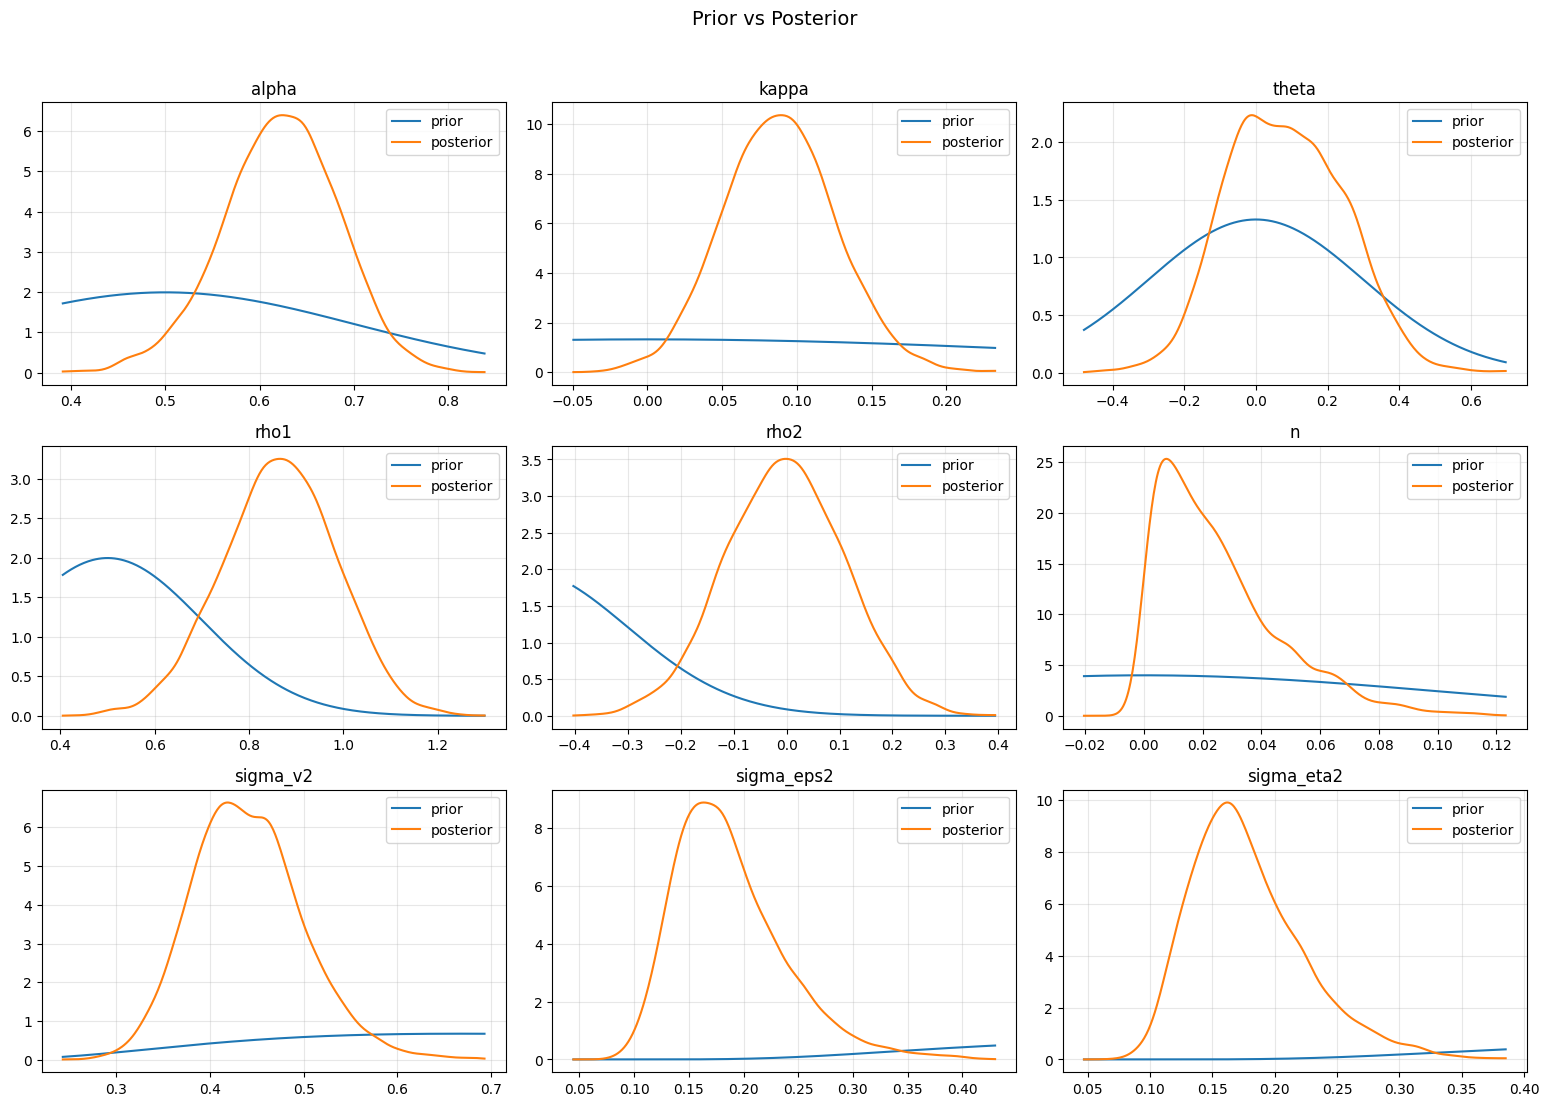

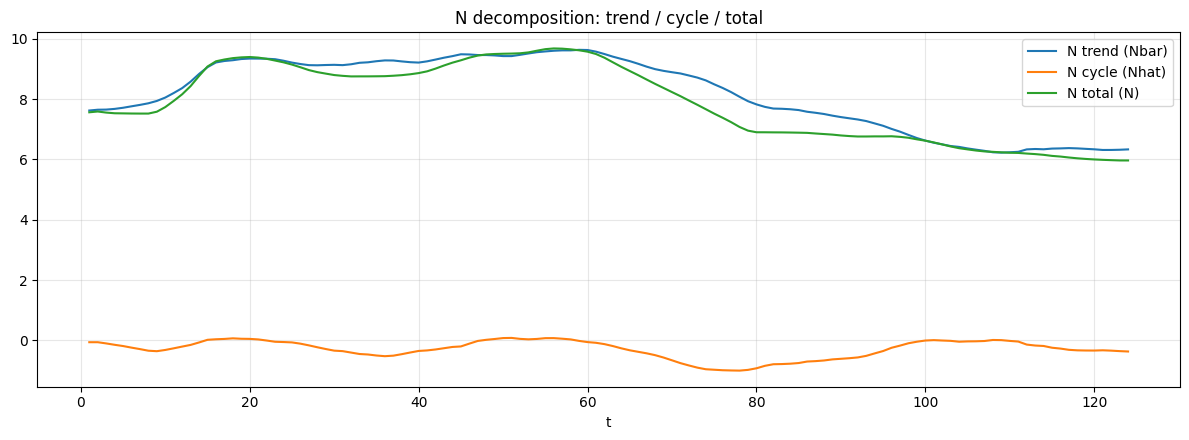

In [13]:
figs = plot_nkpc_hsa_results(res)   # priorsは res["priors"] を自動で使います
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
"""
NKPC-HSA decomposition with time-varying kappa_t driven by ΔNbar:

  π_t = α π_{t-1} + (1-α) E_t π_{t+1} + κ_t x_t − θ N̂_t + v_t
  κ_t = κ_{t-1} + γ ΔN̄_t + u_t
  N̂_t = ρ1 N̂_{t-1} + ρ2 N̂_{t-2} + ε_t
  N̄_t = N̄_{t-1} + n + η_t

FFBS for N̂ (AR2), N̄ (RW), and κ (RW with input), within a Gibbs sampler.

Dependencies:
  numpy
  scipy  (only for multivariate draws; could be removed, but kept minimal)

Priors (dict, optional; defaults in parentheses):
  mu_alpha(0.5),  sigma_alpha(0.2)
  mu_theta(0.0),  sigma_theta(0.3)
  mu_rho1(0.5),   sigma_rho1(0.2)
  mu_rho2(-0.5),  sigma_rho2(0.2)
  mu_n(0.0),      sigma_n(0.1)

  # kappa_t state initial level prior (for κ_1):
  mu_kappa(0.0),  sigma_kappa(0.3)

  # kappa_t drift sensitivity:
  mu_gamma(0.0),  sigma_gamma(0.3)

  # variances (InvGamma shape-scale):
  a_v(2.0),   b_v(2.0)        for sigma_v^2
  a_eps(2.0), b_eps(2.0)      for sigma_eps^2
  a_eta(2.0), b_eta(2.0)      for sigma_eta^2
  a_kappa(2.0), b_kappa(2.0)  for sigma_kappa^2

Options (dict, optional; defaults in parentheses):
  alpha0(0.6), theta0(0.5), rho10(0.5), rho20(-0.5), n0(0.01)
  kappa0(0.3)       # initial κ_t level (vector init)
  gamma0(0.0)
  sigma_v20(1.0), sigma_eps20(0.5), sigma_eta20(0.1), sigma_kappa20(0.1)
  seed(None), verbose(True), store_every(1)
  enforce_stationary(True)
  r_target_scale(0.1)   # obs noise scale for target proxy of Nhat in AR(2) FF
  r_rw_scale(0.1)       # obs noise scale for RW FF

Output:
  results dict with posterior summaries for scalar params + state means:
    results["alpha"], ["theta"], ["rho1"], ["rho2"], ["n"],
    ["gamma"], ["sigma_kappa2"], ["sigma_v2"], ["sigma_eps2"], ["sigma_eta2"]
    results["states"]["Nbar_mean"], ["Nhat_mean"], ["N_mean"], ["kappa_mean"]
"""

from __future__ import annotations

from typing import Any, Dict, Optional

import numpy as np
from numpy.linalg import inv, eig


# ----------------- small utilities -----------------

def getd(d: Optional[Dict[str, Any]], key: str, default: Any) -> Any:
    if isinstance(d, dict) and (key in d) and (d[key] is not None):
        return d[key]
    return default


def assert_all_pos(arr, msg: str):
    arr = np.asarray(arr, dtype=float)
    if np.any(~np.isfinite(arr)) or np.any(arr <= 0):
        raise ValueError(msg)


def is_stationary_ar2(r1: float, r2: float) -> bool:
    return (abs(r2) < 1.0) and ((r1 + r2) < 1.0) and ((r2 - r1) < 1.0)


def force_pd(S: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    S = (S + S.T) / 2.0
    vals, vecs = eig(S)
    vals = np.maximum(vals.real, eps)
    return (vecs.real @ np.diag(vals) @ vecs.real.T)


def mvnrnd(mean: np.ndarray, cov: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    return rng.multivariate_normal(mean, force_pd(cov))


def invgamma_sample_from_posterior(a_post: float, b_post: float, rng: np.random.Generator) -> float:
    # sigma2 ~ InvGamma(a_post, b_post) (shape-scale)  <=>  1/sigma2 ~ Gamma(a_post, scale=1/b_post)
    return 1.0 / rng.gamma(shape=a_post, scale=1.0 / b_post)


# ----------------- FFBS blocks -----------------

def sample_rw_states_ffbs_ext(
    y_target: np.ndarray,
    n_drift: float,
    sigma_eta2: float,
    r_rw_scale: float,
    rng: np.random.Generator,
) -> np.ndarray:
    T = len(y_target)
    if T < 2:
        return y_target.copy()

    m = np.zeros(T, dtype=float)
    P = np.zeros(T, dtype=float)
    m[0] = y_target[0]
    P[0] = 10.0

    for t in range(1, T):
        m_pred = n_drift + m[t - 1]
        P_pred = P[t - 1] + sigma_eta2
        R_obs = sigma_eta2 * r_rw_scale
        K = P_pred / (P_pred + R_obs)
        m[t] = m_pred + K * (y_target[t] - m_pred)
        P[t] = (1.0 - K) * P_pred

    Nbar = np.zeros(T, dtype=float)
    Nbar[T - 1] = m[T - 1] + np.sqrt(max(P[T - 1], 1e-8)) * rng.standard_normal()

    for t in range(T - 2, -1, -1):
        A = P[t] / (P[t] + sigma_eta2)
        m_s = m[t] + A * (Nbar[t + 1] - n_drift - m[t])
        P_s = P[t] * (1.0 - A)
        Nbar[t] = m_s + np.sqrt(max(P_s, 1e-8)) * rng.standard_normal()

    return Nbar


def sample_kappa_states_ffbs(
    y: np.ndarray,                 # y_t = pi - alpha*pi_prev - (1-alpha)Epi + theta*Nhat
    x: np.ndarray,                 # x_t
    dNbar: np.ndarray,             # ΔNbar_t (len T), dNbar[0]=0 recommended
    gamma: float,
    sigma_kappa2: float,
    sigma_v2: float,
    kappa1_mean: float,
    kappa1_var: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    State:
      kappa_t = kappa_{t-1} + gamma*dNbar_t + u_t,  u_t~N(0,sigma_kappa2)
    Obs:
      y_t = x_t * kappa_t + v_t, v_t~N(0,sigma_v2)
    """
    T = len(y)
    m = np.zeros(T, dtype=float)
    P = np.zeros(T, dtype=float)
    m_pred = np.zeros(T, dtype=float)
    P_pred = np.zeros(T, dtype=float)

    m[0] = kappa1_mean
    P[0] = kappa1_var

    for t in range(1, T):
        m_pred[t] = m[t - 1] + gamma * dNbar[t]
        P_pred[t] = P[t - 1] + sigma_kappa2

        H = x[t]
        if abs(H) < 1e-12:
            m[t] = m_pred[t]
            P[t] = P_pred[t]
            continue

        S = (H * H) * P_pred[t] + sigma_v2
        K = (P_pred[t] * H) / S
        m[t] = m_pred[t] + K * (y[t] - H * m_pred[t])
        P[t] = (1.0 - K * H) * P_pred[t]

    kappa = np.zeros(T, dtype=float)
    kappa[T - 1] = m[T - 1] + np.sqrt(max(P[T - 1], 1e-12)) * rng.standard_normal()

    for t in range(T - 2, -1, -1):
        A = P[t] / (P[t] + sigma_kappa2)
        # predicted mean for kappa_{t+1} given kappa_t is (kappa_t + gamma*dNbar[t+1])
        m_s = m[t] + A * (kappa[t + 1] - (m[t] + gamma * dNbar[t + 1]))
        P_s = P[t] * (1.0 - A)
        kappa[t] = m_s + np.sqrt(max(P_s, 1e-12)) * rng.standard_normal()

    return kappa


def sample_ar2_states_ffbs_ext(
    y_target: np.ndarray,
    rho1: float,
    rho2: float,
    sigma_eps2: float,
    # NKPC pieces (kappa is now time-varying)
    pi_t: np.ndarray,
    alpha: float,
    pi_tm1: np.ndarray,
    E_pi_tp1: np.ndarray,
    kappa_t: np.ndarray,
    x_t: np.ndarray,
    theta: float,
    sigma_v2: float,
    r_target_scale: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    State vector: [Nhat_t; Nhat_{t-1}]
    Transition: AR(2)
    Observations at time t:
      (1) target proxy: Nhat_t ≈ y_target_t with noise R1
      (2) NKPC-implied: theta*Nhat_t ≈ alpha*pi_{t-1} + (1-alpha)Epi_{t+1} + kappa_t*x_t - pi_t  with noise R2
    """
    T = len(y_target)
    if T < 3:
        return y_target.copy()

    F = np.array([[rho1, rho2],
                  [1.0,  0.0]], dtype=float)
    Q = np.array([[sigma_eps2, 0.0],
                  [0.0,       0.0]], dtype=float)

    m = np.zeros((2, T), dtype=float)
    P = np.zeros((2, 2, T), dtype=float)
    m_pred = np.zeros((2, T), dtype=float)
    P_pred = np.zeros((2, 2, T), dtype=float)

    m[:, 0] = np.array([y_target[0], 0.0])
    P[:, :, 0] = np.eye(2) * 10.0

    for t in range(1, T):
        if t > 1:
            m_pred[:, t] = F @ m[:, t - 1]
            P_pred[:, :, t] = F @ P[:, :, t - 1] @ F.T + Q
        else:
            m_pred[:, t] = m[:, t - 1]
            P_pred[:, :, t] = P[:, :, t - 1]

        H1 = np.array([[1.0, 0.0]])
        R1 = sigma_eps2 * r_target_scale

        nkpc_obs = alpha * pi_tm1[t] + (1.0 - alpha) * E_pi_tp1[t] + kappa_t[t] * x_t[t] - pi_t[t]
        H2 = np.array([[theta, 0.0]])
        R2 = sigma_v2

        H = np.vstack([H1, H2])
        y = np.array([y_target[t], nkpc_obs], dtype=float)
        R = np.diag([R1, R2])

        S = H @ P_pred[:, :, t] @ H.T + R
        K = P_pred[:, :, t] @ H.T @ inv(S)

        m[:, t] = m_pred[:, t] + K @ (y - H @ m_pred[:, t])
        P[:, :, t] = P_pred[:, :, t] - K @ H @ P_pred[:, :, t]

    states = np.zeros((2, T), dtype=float)
    states[:, T - 1] = mvnrnd(m[:, T - 1], P[:, :, T - 1], rng)

    C_s_next = P[:, :, T - 1].copy()
    for t in range(T - 2, -1, -1):
        if t >= 1:
            A = P[:, :, t] @ F.T @ inv(P_pred[:, :, t + 1])
            m_s = m[:, t] + A @ (states[:, t + 1] - m_pred[:, t + 1])
            P_s = P[:, :, t] - A @ (P_pred[:, :, t + 1] - C_s_next) @ A.T
            states[:, t] = mvnrnd(m_s, P_s, rng)
            C_s_next = P_s
        else:
            states[:, t] = states[:, t + 1]

    return states[0, :].copy()


# ----------------- gamma / sigma_kappa2 conditionals -----------------

def sample_gamma(
    kappa_t: np.ndarray,
    dNbar: np.ndarray,
    mu_gamma: float,
    sigma_gamma: float,
    sigma_kappa2: float,
    rng: np.random.Generator,
) -> float:
    dk = kappa_t[1:] - kappa_t[:-1]
    z = dNbar[1:]
    prec0 = 1.0 / (sigma_gamma ** 2)
    precD = float(np.sum(z * z)) / sigma_kappa2
    postV = 1.0 / (prec0 + precD)
    postM = postV * (prec0 * mu_gamma + float(np.sum(z * dk)) / sigma_kappa2)
    return float(postM + np.sqrt(postV) * rng.standard_normal())


def sample_sigma_kappa2(
    kappa_t: np.ndarray,
    dNbar: np.ndarray,
    gamma: float,
    a_kappa: float,
    b_kappa: float,
    rng: np.random.Generator,
) -> float:
    u = (kappa_t[1:] - kappa_t[:-1]) - gamma * dNbar[1:]
    a_post = a_kappa + u.size / 2.0
    b_post = b_kappa + 0.5 * float(np.sum(u * u))
    return float(invgamma_sample_from_posterior(a_post, b_post, rng))


# ----------------- main estimation -----------------

def func_nkpc_hsa_decomp_tv_kappa(
    pi_data,
    pi_prev_data,
    Epi_data,
    x_data,
    N_data,
    n_burn: int,
    n_keep: int,
    priors: Optional[Dict[str, Any]] = None,
    opts: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    # ---- Data ----
    pi_t = np.asarray(pi_data, dtype=float).reshape(-1)
    pi_tm1 = np.asarray(pi_prev_data, dtype=float).reshape(-1)
    E_pi_tp1 = np.asarray(Epi_data, dtype=float).reshape(-1)
    x_t = np.asarray(x_data, dtype=float).reshape(-1)
    N_obs = np.asarray(N_data, dtype=float).reshape(-1)

    T = pi_t.size
    if not (pi_tm1.size == E_pi_tp1.size == x_t.size == N_obs.size == T):
        raise ValueError("All input series must have the same length T.")

    # ---- Priors ----
    priors = priors or {}

    mu_alpha = getd(priors, "mu_alpha", 0.5)
    sigma_alpha = getd(priors, "sigma_alpha", 0.2)

    mu_theta = getd(priors, "mu_theta", 0.0)
    sigma_theta = getd(priors, "sigma_theta", 0.3)

    mu_rho1 = getd(priors, "mu_rho1", 0.5)
    sigma_rho1 = getd(priors, "sigma_rho1", 0.2)
    mu_rho2 = getd(priors, "mu_rho2", -0.5)
    sigma_rho2 = getd(priors, "sigma_rho2", 0.2)

    mu_n = getd(priors, "mu_n", 0.0)
    sigma_n = getd(priors, "sigma_n", 0.1)

    # kappa initial level prior
    mu_kappa = getd(priors, "mu_kappa", 0.0)
    sigma_kappa = getd(priors, "sigma_kappa", 0.3)

    # gamma prior
    mu_gamma = getd(priors, "mu_gamma", 0.0)
    sigma_gamma = getd(priors, "sigma_gamma", 0.3)

    # variances
    a_v = getd(priors, "a_v", 2.0)
    b_v = getd(priors, "b_v", 2.0)
    a_eps = getd(priors, "a_eps", 2.0)
    b_eps = getd(priors, "b_eps", 2.0)
    a_eta = getd(priors, "a_eta", 2.0)
    b_eta = getd(priors, "b_eta", 2.0)
    a_kappa = getd(priors, "a_kappa", 2.0)
    b_kappa = getd(priors, "b_kappa", 2.0)

    assert_all_pos(
        [sigma_alpha, sigma_theta, sigma_rho1, sigma_rho2, sigma_n,
         sigma_kappa, sigma_gamma, a_v, b_v, a_eps, b_eps, a_eta, b_eta, a_kappa, b_kappa],
        "Prior stds and IG params must be positive.",
    )

    # ---- Options ----
    opts = opts or {}
    alpha = float(getd(opts, "alpha0", 0.6))
    theta = float(getd(opts, "theta0", 0.5))
    rho1 = float(getd(opts, "rho10", 0.5))
    rho2 = float(getd(opts, "rho20", -0.5))
    n_drift = float(getd(opts, "n0", 0.01))

    kappa0 = float(getd(opts, "kappa0", 0.3))
    gamma = float(getd(opts, "gamma0", 0.0))

    sigma_v2 = float(getd(opts, "sigma_v20", 1.0))
    sigma_eps2 = float(getd(opts, "sigma_eps20", 0.5))
    sigma_eta2 = float(getd(opts, "sigma_eta20", 0.1))
    sigma_kappa2 = float(getd(opts, "sigma_kappa20", 0.1))

    seed = getd(opts, "seed", None)
    verbose = bool(getd(opts, "verbose", True))
    store_every = int(max(1, getd(opts, "store_every", 1)))
    enforce_station = bool(getd(opts, "enforce_stationary", True))
    r_target_scale = float(getd(opts, "r_target_scale", 0.1))
    r_rw_scale = float(getd(opts, "r_rw_scale", 0.1))

    rng = np.random.default_rng(seed)

    # ---- Initialize states ----
    Nbar = np.zeros(T, dtype=float)
    k0 = min(2, T)
    Nbar[:k0] = N_obs[:k0]
    for t in range(2, T):
        Nbar[t] = 0.7 * Nbar[t - 1] + 0.3 * N_obs[t]
    Nhat = N_obs - Nbar

    kappa_t = np.full(T, kappa0, dtype=float)

    # ---- Storage ----
    n_store = int(np.ceil(n_keep / store_every))
    alpha_draws = np.zeros(n_store)
    theta_draws = np.zeros(n_store)
    rho1_draws = np.zeros(n_store)
    rho2_draws = np.zeros(n_store)
    n_draws = np.zeros(n_store)
    gamma_draws = np.zeros(n_store)

    sv_draws = np.zeros(n_store)
    se_draws = np.zeros(n_store)
    seta_draws = np.zeros(n_store)
    sk_draws = np.zeros(n_store)

    Nbar_draws = np.zeros((n_store, T))
    Nhat_draws = np.zeros((n_store, T))
    kappa_draws = np.zeros((n_store, T))

    if verbose:
        print(f"Gibbs start: burn-in={n_burn}, keep={n_keep} (thin={store_every})")

    total_iter = n_burn + n_keep
    store_idx = 0

    for it in range(1, total_iter + 1):
        # ΔNbar
        dNbar = np.zeros(T, dtype=float)
        if T >= 2:
            dNbar[1:] = Nbar[1:] - Nbar[:-1]

        # -------- α | .  (uses kappa_t)
        y_a = pi_t - E_pi_tp1 - (kappa_t * x_t) + theta * Nhat
        X_a = pi_tm1 - E_pi_tp1
        XtX = float(X_a @ X_a)
        if XtX > 1e-12:
            prec0 = 1.0 / (sigma_alpha ** 2)
            precD = XtX / sigma_v2
            postV = 1.0 / (prec0 + precD)
            postM = postV * (prec0 * mu_alpha + float(X_a @ y_a) / sigma_v2)
            alpha = float(postM + np.sqrt(postV) * rng.standard_normal())

        # -------- θ | .  (uses kappa_t)
        y_th = pi_t - alpha * pi_tm1 - (1.0 - alpha) * E_pi_tp1 - (kappa_t * x_t)
        X_th = -Nhat
        XtX = float(X_th @ X_th)
        if XtX > 1e-12:
            prec0 = 1.0 / (sigma_theta ** 2)
            precD = XtX / sigma_v2
            postV = 1.0 / (prec0 + precD)
            postM = postV * (prec0 * mu_theta + float(X_th @ y_th) / sigma_v2)
            theta = float(postM + np.sqrt(postV) * rng.standard_normal())

        # -------- AR(2) params for Nhat | .
        if T >= 3:
            y_r = Nhat[2:]
            X_r = np.column_stack([Nhat[1:-1], Nhat[:-2]])
            Prec0 = np.diag([1.0 / (sigma_rho1 ** 2), 1.0 / (sigma_rho2 ** 2)])
            PrecD = (X_r.T @ X_r) / sigma_eps2
            PostP = Prec0 + PrecD
            PostC = inv(PostP)
            mu0 = np.array([mu_rho1, mu_rho2], dtype=float)
            PostM = PostC @ (Prec0 @ mu0 + (X_r.T @ y_r) / sigma_eps2)

            ok = False
            tries = 0
            while (not ok) and (tries < 2000):
                rdraw = mvnrnd(PostM, PostC, rng)
                if (not enforce_station) or is_stationary_ar2(float(rdraw[0]), float(rdraw[1])):
                    rho1, rho2 = float(rdraw[0]), float(rdraw[1])
                    ok = True
                tries += 1
            if not ok:
                rho1, rho2 = float(PostM[0]), float(PostM[1])

        # -------- RW drift n | .
        if T >= 2:
            y_n = Nbar[1:] - Nbar[:-1]
            Tn = y_n.size
            prec0 = 1.0 / (sigma_n ** 2)
            precD = Tn / sigma_eta2
            postV = 1.0 / (prec0 + precD)
            postM = postV * (prec0 * mu_n + float(np.sum(y_n)) / sigma_eta2)
            n_drift = float(postM + np.sqrt(postV) * rng.standard_normal())
            tries = 0
            while (n_drift <= 0.0) and (tries < 10000):
                n_drift = float(postM + np.sqrt(postV) * rng.standard_normal())
                tries += 1
            if n_drift <= 0.0:
                n_drift = float(abs(postM))

        # -------- κ_t | .  (FFBS)
        y_for_kappa = pi_t - alpha * pi_tm1 - (1.0 - alpha) * E_pi_tp1 + theta * Nhat
        kappa_t = sample_kappa_states_ffbs(
            y=y_for_kappa,
            x=x_t,
            dNbar=dNbar,
            gamma=gamma,
            sigma_kappa2=sigma_kappa2,
            sigma_v2=sigma_v2,
            kappa1_mean=float(mu_kappa),
            kappa1_var=float(sigma_kappa ** 2),
            rng=rng,
        )

        # -------- γ | κ_t, ΔNbar
        gamma = sample_gamma(
            kappa_t=kappa_t,
            dNbar=dNbar,
            mu_gamma=float(mu_gamma),
            sigma_gamma=float(sigma_gamma),
            sigma_kappa2=float(sigma_kappa2),
            rng=rng,
        )

        # -------- σ_kappa^2 | κ_t, γ
        sigma_kappa2 = sample_sigma_kappa2(
            kappa_t=kappa_t,
            dNbar=dNbar,
            gamma=gamma,
            a_kappa=float(a_kappa),
            b_kappa=float(b_kappa),
            rng=rng,
        )

        # -------- Variances
        nkpc_resid = pi_t - alpha * pi_tm1 - (1.0 - alpha) * E_pi_tp1 - (kappa_t * x_t) + theta * Nhat
        a_post = a_v + T / 2.0
        b_post = b_v + 0.5 * float(np.sum(nkpc_resid ** 2))
        sigma_v2 = float(invgamma_sample_from_posterior(a_post, b_post, rng))

        if T >= 3:
            ar_res = Nhat[2:] - rho1 * Nhat[1:-1] - rho2 * Nhat[:-2]
            a_post = a_eps + ar_res.size / 2.0
            b_post = b_eps + 0.5 * float(np.sum(ar_res ** 2))
            sigma_eps2 = float(invgamma_sample_from_posterior(a_post, b_post, rng))

        if T >= 2:
            rw_res = Nbar[1:] - n_drift - Nbar[:-1]
            a_post = a_eta + rw_res.size / 2.0
            b_post = b_eta + 0.5 * float(np.sum(rw_res ** 2))
            sigma_eta2 = float(invgamma_sample_from_posterior(a_post, b_post, rng))

        # -------- FFBS for Nhat and Nbar (uses kappa_t)
        Nhat = sample_ar2_states_ffbs_ext(
            y_target=N_obs - Nbar,
            rho1=rho1,
            rho2=rho2,
            sigma_eps2=sigma_eps2,
            pi_t=pi_t,
            alpha=alpha,
            pi_tm1=pi_tm1,
            E_pi_tp1=E_pi_tp1,
            kappa_t=kappa_t,
            x_t=x_t,
            theta=theta,
            sigma_v2=sigma_v2,
            r_target_scale=r_target_scale,
            rng=rng,
        )

        Nbar = sample_rw_states_ffbs_ext(
            y_target=N_obs - Nhat,
            n_drift=n_drift,
            sigma_eta2=sigma_eta2,
            r_rw_scale=r_rw_scale,
            rng=rng,
        )

        # -------- Store
        if (it > n_burn) and ((it - n_burn) % store_every == 0):
            idx = store_idx
            alpha_draws[idx] = alpha
            theta_draws[idx] = theta
            rho1_draws[idx] = rho1
            rho2_draws[idx] = rho2
            n_draws[idx] = n_drift
            gamma_draws[idx] = gamma

            sv_draws[idx] = sigma_v2
            se_draws[idx] = sigma_eps2
            seta_draws[idx] = sigma_eta2
            sk_draws[idx] = sigma_kappa2

            Nbar_draws[idx, :] = Nbar
            Nhat_draws[idx, :] = Nhat
            kappa_draws[idx, :] = kappa_t
            store_idx += 1

        if verbose and (it % 5000 == 0):
            print(f"Iter {it}/{total_iter}: a={alpha:.3f} th={theta:.3f} g={gamma:.3f} r1={rho1:.3f} r2={rho2:.3f}")

    # ---- Results ----
    def add_sum(v: np.ndarray) -> Dict[str, Any]:
        v = np.asarray(v, dtype=float)
        qs = np.quantile(v, [0.025, 0.05, 0.25, 0.5, 0.75, 0.95, 0.975])
        return {
            "draws": v,
            "mean": float(np.mean(v)),
            "std": float(np.std(v, ddof=1)) if v.size > 1 else 0.0,
            "quantiles": qs,
        }

    results: Dict[str, Any] = {}
    results["alpha"] = add_sum(alpha_draws)
    results["theta"] = add_sum(theta_draws)
    results["rho1"] = add_sum(rho1_draws)
    results["rho2"] = add_sum(rho2_draws)
    results["n"] = add_sum(n_draws)
    results["gamma"] = add_sum(gamma_draws)

    results["sigma_v2"] = add_sum(sv_draws)
    results["sigma_eps2"] = add_sum(se_draws)
    results["sigma_eta2"] = add_sum(seta_draws)
    results["sigma_kappa2"] = add_sum(sk_draws)

    results["states"] = {
        "Nbar_mean": np.mean(Nbar_draws, axis=0),
        "Nhat_mean": np.mean(Nhat_draws, axis=0),
        "kappa_mean": np.mean(kappa_draws, axis=0),
    }
    results["states"]["N_mean"] = results["states"]["Nbar_mean"] + results["states"]["Nhat_mean"]

    # if you want uncertainty bands later, keep the thinned draws too:
    results["state_draws"] = {
        "Nbar": Nbar_draws,
        "Nhat": Nhat_draws,
        "kappa": kappa_draws,
    }

    results["priors"] = priors
    results["opts"] = opts

    if verbose:
        print("\n=== NKPC-HSA (time-varying kappa) — Posterior means and 95% CI ===")
        for key in ["alpha", "theta", "gamma", "rho1", "rho2", "n", "sigma_v2", "sigma_kappa2"]:
            q = results[key]["quantiles"]
            print(f"{key:>11s}: {results[key]['mean']:.4f}  [{q[0]:.4f}, {q[6]:.4f}]")

    return results

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, invgamma, gaussian_kde


def plot_nkpc_hsa_tv_kappa_results(
    results,
    priors=None,
    t=None,
    params=None,
    kde=True,
    bins=40,
    bands=(0.05, 0.95),
    show_bands=True,
    default_priors=None,  # ←ここで強制priorを上書き可能
):

    # ---------- 1) priors を確実に用意（欠けてても補完） ----------
    base = results.get("priors", {}) or {}
    priors_in = priors if priors is not None else base

    # 推定関数側のデフォルト（誤差ありTV-kappa版に合わせたデフォルト）
    priors_default = {
        "mu_alpha": 0.5, "sigma_alpha": 0.2,
        "mu_theta": 0.0, "sigma_theta": 0.3,
        "mu_rho1": 0.5, "sigma_rho1": 0.2,
        "mu_rho2": -0.5, "sigma_rho2": 0.2,
        "mu_n": 0.0, "sigma_n": 0.1,
        "mu_gamma": 0.0, "sigma_gamma": 0.3,

        "a_v": 2.0, "b_v": 2.0,
        "a_eps": 2.0, "b_eps": 2.0,
        "a_eta": 2.0, "b_eta": 2.0,

        # stochastic TV-kappa のとき
        "a_kappa": 2.0, "b_kappa": 2.0,

        # deterministic(no-error) のときに使う可能性
        "mu_kappa": 0.0, "sigma_kappa": 0.3,
    }
    if default_priors is not None:
        priors_default.update(default_priors)

    priors_full = dict(priors_default)
    priors_full.update(priors_in or {})  # 入力優先で上書き

    # ---------- 2) プロット対象 ----------
    if params is None:
        # results に sigma_kappa2 が無い（誤差なし版）こともあるので自動判定
        params = ["alpha", "theta", "gamma", "rho1", "rho2", "n",
                  "sigma_v2", "sigma_eps2", "sigma_eta2"]
        if "sigma_kappa2" in results:
            params.append("sigma_kappa2")
        if "kappa1" in results:
            params.insert(2, "kappa1")  # alpha,theta,kappa1,gamma,...

    # ---------- 3) prior / posterior ヘルパ ----------
    def prior_pdf(name, x):
        # Normal priors
        if name in ["alpha", "theta", "n", "gamma", "kappa1"]:
            mu_key = f"mu_{name}"
            sig_key = f"sigma_{name}"
            # kappa1 は mu_kappa/sigma_kappa を使う
            if name == "kappa1":
                mu_key, sig_key = "mu_kappa", "sigma_kappa"
            mu = float(priors_full[mu_key])
            sd = float(priors_full[sig_key])
            return norm.pdf(x, loc=mu, scale=sd)

        if name == "rho1":
            return norm.pdf(x, loc=float(priors_full["mu_rho1"]), scale=float(priors_full["sigma_rho1"]))
        if name == "rho2":
            return norm.pdf(x, loc=float(priors_full["mu_rho2"]), scale=float(priors_full["sigma_rho2"]))

        # InvGamma priors for variances
        if name in ["sigma_v2", "sigma_eps2", "sigma_eta2", "sigma_kappa2"]:
            a_key = {"sigma_v2": "a_v", "sigma_eps2": "a_eps", "sigma_eta2": "a_eta", "sigma_kappa2": "a_kappa"}[name]
            b_key = {"sigma_v2": "b_v", "sigma_eps2": "b_eps", "sigma_eta2": "b_eta", "sigma_kappa2": "b_kappa"}[name]
            a = float(priors_full[a_key])
            b = float(priors_full[b_key])
            y = np.zeros_like(x)
            mask = x > 0
            y[mask] = invgamma.pdf(x[mask], a=a, scale=b)
            return y

        # fallback（ありえない想定）
        return np.full_like(x, np.nan)

    def posterior_draws(name):
        if name not in results or "draws" not in results[name]:
            return None
        v = np.asarray(results[name]["draws"], dtype=float)
        v = v[np.isfinite(v)]
        return v if v.size else None

    # =========================
    # (1) Prior vs Posterior
    # =========================
    nplots = len(params)
    ncols = 3
    nrows = int(np.ceil(nplots / ncols))
    fig1, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.2 * ncols, 3.6 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, p in enumerate(params):
        ax = axes[i]
        post = posterior_draws(p)

        if post is None:
            ax.text(0.5, 0.5, f"No posterior draws for {p}", ha="center", va="center")
            ax.set_axis_off()
            continue

        # x-range: posterior中心＋priorの中心も含むように拡張
        plo, phi = np.quantile(post, [0.005, 0.995])
        span = phi - plo
        if not np.isfinite(span) or span <= 0:
            plo, phi = float(np.min(post)), float(np.max(post))
            span = phi - plo if phi > plo else 1.0

        # priorも描くので、少し広めにとる
        x = np.linspace(plo - 0.5 * span, phi + 0.5 * span, 600)

        # prior (必ず描く)
        y_pr = prior_pdf(p, x)
        # priorが全部0になるケース（invgammaで範囲がズレた等）でも見えるように、必要なら範囲を正側へ寄せる
        if np.all((y_pr == 0) | ~np.isfinite(y_pr)) and p.startswith("sigma_"):
            x2 = np.linspace(max(1e-8, plo), max(1e-8, phi + 2.0 * span), 800)
            y2 = prior_pdf(p, x2)
            if np.any(np.isfinite(y2)) and np.any(y2 > 0):
                x, y_pr = x2, y2

        ax.plot(x, y_pr, label="prior")

        # posterior density
        if kde and post.size >= 5:
            ax.plot(x, gaussian_kde(post)(x), label="posterior")
        else:
            ax.hist(post, bins=bins, density=True, alpha=0.6, label="posterior")

        ax.set_title(p)
        ax.grid(True, alpha=0.3)
        ax.legend()

    for j in range(nplots, axes.size):
        axes[j].set_axis_off()

    fig1.suptitle("Prior vs Posterior (always overlayed)", y=1.02, fontsize=14)
    fig1.tight_layout()

    # =========================
    # (2) Time series plots
    # =========================
    states = results.get("states", {}) or {}
    Nbar = np.asarray(states.get("Nbar_mean", []), dtype=float)
    Nhat = np.asarray(states.get("Nhat_mean", []), dtype=float)
    N = np.asarray(states.get("N_mean", []), dtype=float)
    kappa = np.asarray(states.get("kappa_mean", []), dtype=float)

    T = max(Nbar.size, Nhat.size, N.size, kappa.size)
    if T == 0:
        fig2, ax = plt.subplots(figsize=(12, 4))
        ax.text(0.5, 0.5, "No state means found in results['states']", ha="center", va="center")
        ax.set_axis_off()
        return {"prior_posterior": fig1, "states": fig2}

    if t is None:
        t = np.arange(1, T + 1)
    else:
        t = np.asarray(t)
        if t.size != T:
            raise ValueError(f"t length ({t.size}) must match state length ({T}).")

    fig2, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(13, 7), sharex=True)

    def add_bands(ax, draws, label, qlo, qhi):
        lo = np.quantile(draws, qlo, axis=0)
        hi = np.quantile(draws, qhi, axis=0)
        ax.fill_between(t, lo, hi, alpha=0.2, label=f"{label} {int(qlo*100)}–{int(qhi*100)}% band")

    # N panel
    if Nbar.size: ax1.plot(t, Nbar, label="N trend (Nbar)")
    if Nhat.size: ax1.plot(t, Nhat, label="N cycle (Nhat)")
    if N.size:    ax1.plot(t, N,    label="N total (N)")

    if show_bands and "state_draws" in results:
        sd = results["state_draws"] or {}
        qlo, qhi = bands
        if "Nbar" in sd and np.asarray(sd["Nbar"]).ndim == 2:
            add_bands(ax1, np.asarray(sd["Nbar"]), "Nbar", qlo, qhi)
        if "Nhat" in sd and np.asarray(sd["Nhat"]).ndim == 2:
            add_bands(ax1, np.asarray(sd["Nhat"]), "Nhat", qlo, qhi)
        if ("Nbar" in sd) and ("Nhat" in sd):
            add_bands(ax1, np.asarray(sd["Nbar"]) + np.asarray(sd["Nhat"]), "N", qlo, qhi)

    ax1.set_title("N decomposition: trend / cycle / total")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # kappa panel
    if kappa.size: ax2.plot(t, kappa, label="kappa_t (mean)")
    if show_bands and "state_draws" in results:
        sd = results["state_draws"] or {}
        qlo, qhi = bands
        if "kappa" in sd and np.asarray(sd["kappa"]).ndim == 2:
            add_bands(ax2, np.asarray(sd["kappa"]), "kappa_t", qlo, qhi)

    ax2.set_title("Time-varying kappa_t")
    ax2.set_xlabel("t")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    fig2.tight_layout()

    return {"prior_posterior": fig1, "states": fig2}

In [21]:
res_2 = func_nkpc_hsa_decomp_tv_kappa(
    pi_data=pi,
    pi_prev_data=pi_prev,
    Epi_data=pi_expect,
    x_data=x_output_gap,
    N_data=N,
    n_burn=2000,
    n_keep=5000,
    priors={
        "mu_alpha":0.5,"sigma_alpha":0.2,
        "mu_theta":0.0,"sigma_theta":0.3,
        "mu_kappa":0.0,"sigma_kappa":0.3,
        "mu_gamma":0.0,"sigma_gamma":0.3,
        "a_kappa":2.0,"b_kappa":2.0,
    },
    opts={"seed":123, "verbose":True}
)

Gibbs start: burn-in=2000, keep=5000 (thin=1)
Iter 5000/7000: a=0.529 th=-0.229 g=-0.219 r1=0.858 r2=0.121

=== NKPC-HSA (time-varying kappa) — Posterior means and 95% CI ===
      alpha: 0.5988  [0.4406, 0.7538]
      theta: -0.1700  [-0.3524, 0.0090]
      gamma: -0.0002  [-0.3142, 0.3191]
       rho1: 0.8907  [0.6785, 1.1017]
       rho2: 0.0469  [-0.1683, 0.2605]
          n: 0.0184  [0.0006, 0.0609]
   sigma_v2: 0.2608  [0.1840, 0.3649]
sigma_kappa2: 0.1700  [0.1094, 0.2550]


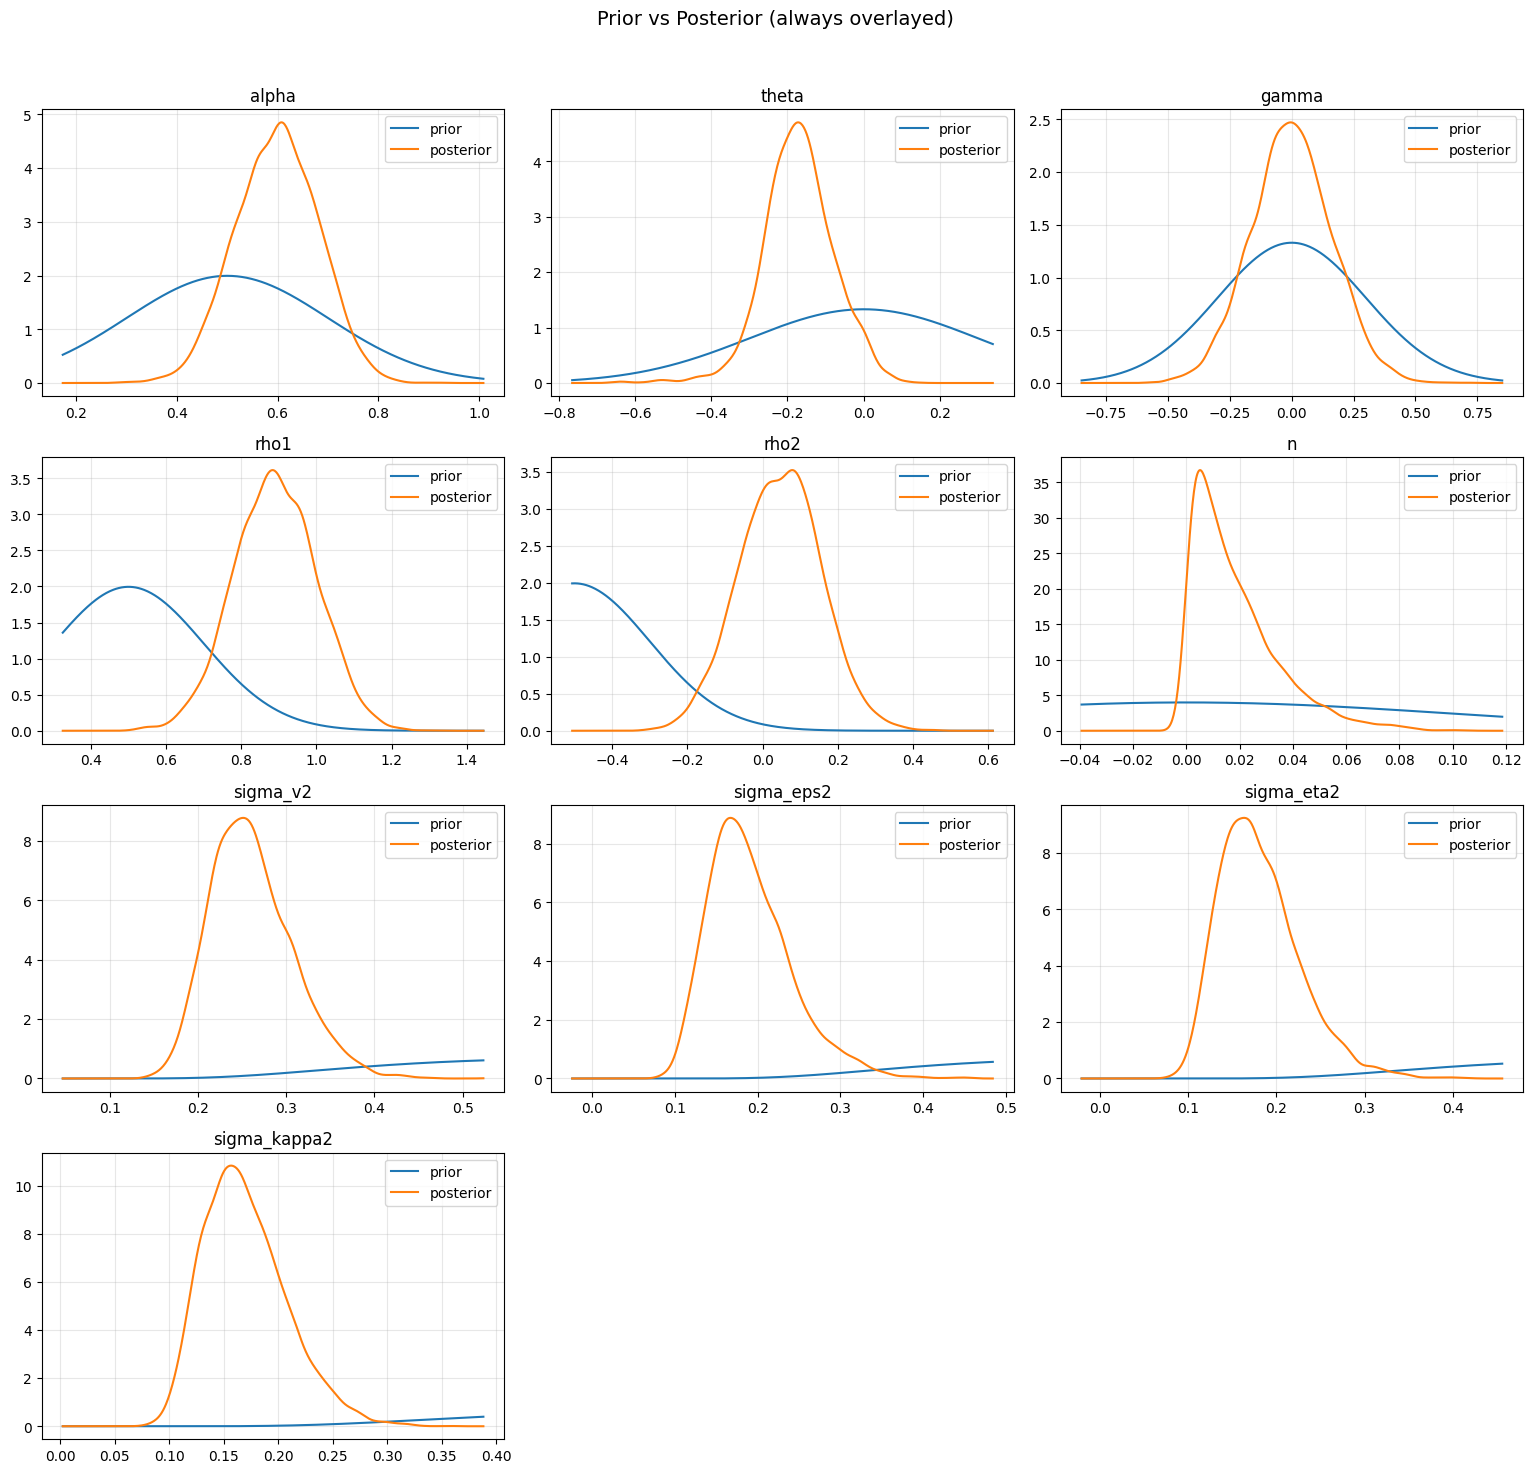

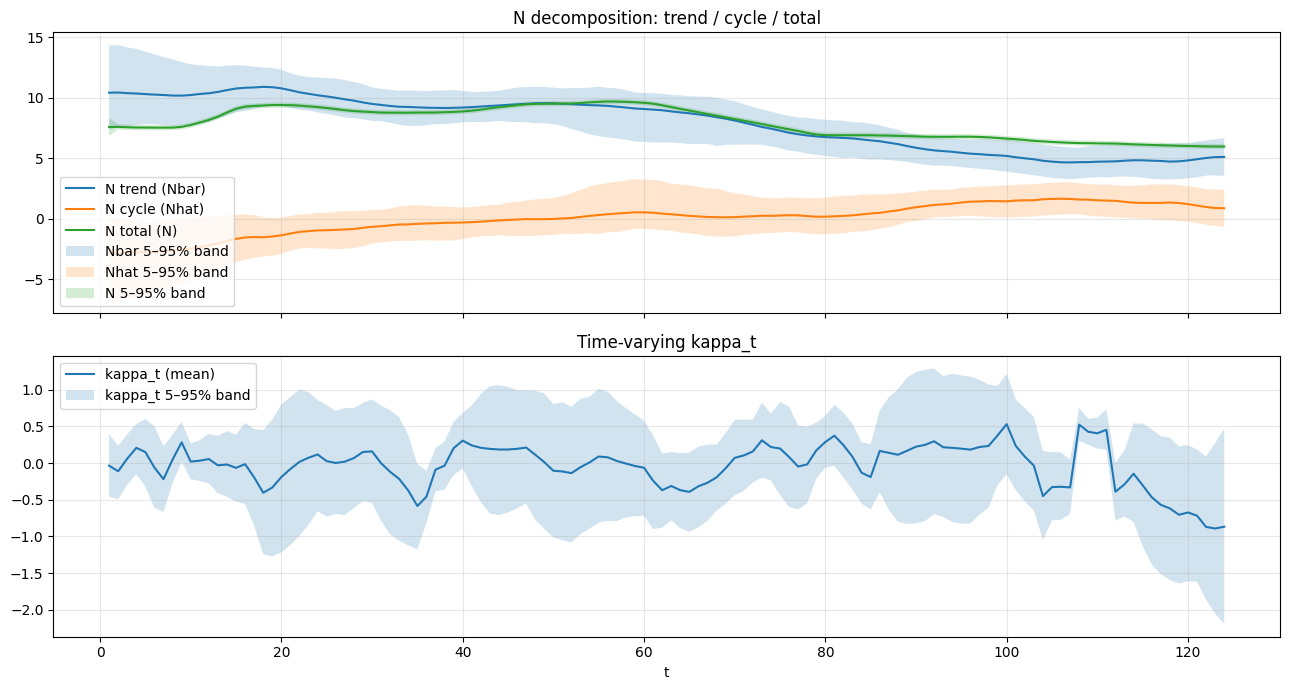

In [27]:

kappa_path = res_2["states"]["kappa_mean"]

figs = plot_nkpc_hsa_tv_kappa_results(res_2, bands=(0.05, 0.95), show_bands=True)
plt.show()

In [24]:
# -*- coding: utf-8 -*-
"""
NKPC-HSA decomposition with deterministic time-varying kappa:

  π_t = α π_{t-1} + (1-α) E_t π_{t+1} + κ_t x_t − θ N̂_t + v_t,   v_t~N(0,σ_v^2)
  κ_t = κ_{t-1} + γ ΔN̄_t         (NO error term u_t)

So κ_t is fully determined by (κ1, γ) and Nbar:
  κ_t = κ1 + γ (N̄_t − N̄_1)

We sample (κ1, γ) jointly by conjugate Gaussian regression given states and other params.
Other blocks are as before: AR(2) for Nhat, RW for Nbar, FFBS for states, Gibbs for params.

Dependencies: numpy
"""

from __future__ import annotations
from typing import Any, Dict, Optional

import numpy as np
from numpy.linalg import inv, eig


# -------- utilities --------

def getd(d: Optional[Dict[str, Any]], key: str, default: Any) -> Any:
    if isinstance(d, dict) and (key in d) and (d[key] is not None):
        return d[key]
    return default


def assert_all_pos(arr, msg: str):
    arr = np.asarray(arr, dtype=float)
    if np.any(~np.isfinite(arr)) or np.any(arr <= 0):
        raise ValueError(msg)


def is_stationary_ar2(r1: float, r2: float) -> bool:
    return (abs(r2) < 1.0) and ((r1 + r2) < 1.0) and ((r2 - r1) < 1.0)


def force_pd(S: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    S = (S + S.T) / 2.0
    vals, vecs = eig(S)
    vals = np.maximum(vals.real, eps)
    return (vecs.real @ np.diag(vals) @ vecs.real.T)


def mvnrnd(mean: np.ndarray, cov: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    return rng.multivariate_normal(mean, force_pd(cov))


def invgamma_sample_from_posterior(a_post: float, b_post: float, rng: np.random.Generator) -> float:
    return 1.0 / rng.gamma(shape=a_post, scale=1.0 / b_post)


# -------- FFBS blocks --------

def sample_rw_states_ffbs_ext(
    y_target: np.ndarray,
    n_drift: float,
    sigma_eta2: float,
    r_rw_scale: float,
    rng: np.random.Generator,
) -> np.ndarray:
    T = len(y_target)
    if T < 2:
        return y_target.copy()

    m = np.zeros(T, dtype=float)
    P = np.zeros(T, dtype=float)
    m[0] = y_target[0]
    P[0] = 10.0

    for t in range(1, T):
        m_pred = n_drift + m[t - 1]
        P_pred = P[t - 1] + sigma_eta2
        R_obs = sigma_eta2 * r_rw_scale
        K = P_pred / (P_pred + R_obs)
        m[t] = m_pred + K * (y_target[t] - m_pred)
        P[t] = (1.0 - K) * P_pred

    Nbar = np.zeros(T, dtype=float)
    Nbar[T - 1] = m[T - 1] + np.sqrt(max(P[T - 1], 1e-8)) * rng.standard_normal()

    for t in range(T - 2, -1, -1):
        A = P[t] / (P[t] + sigma_eta2)
        m_s = m[t] + A * (Nbar[t + 1] - n_drift - m[t])
        P_s = P[t] * (1.0 - A)
        Nbar[t] = m_s + np.sqrt(max(P_s, 1e-8)) * rng.standard_normal()

    return Nbar


def sample_ar2_states_ffbs_ext(
    y_target: np.ndarray,
    rho1: float,
    rho2: float,
    sigma_eps2: float,
    pi_t: np.ndarray,
    alpha: float,
    pi_tm1: np.ndarray,
    E_pi_tp1: np.ndarray,
    kappa_t: np.ndarray,
    x_t: np.ndarray,
    theta: float,
    sigma_v2: float,
    r_target_scale: float,
    rng: np.random.Generator,
) -> np.ndarray:
    T = len(y_target)
    if T < 3:
        return y_target.copy()

    F = np.array([[rho1, rho2],
                  [1.0,  0.0]], dtype=float)
    Q = np.array([[sigma_eps2, 0.0],
                  [0.0,       0.0]], dtype=float)

    m = np.zeros((2, T), dtype=float)
    P = np.zeros((2, 2, T), dtype=float)
    m_pred = np.zeros((2, T), dtype=float)
    P_pred = np.zeros((2, 2, T), dtype=float)

    m[:, 0] = np.array([y_target[0], 0.0])
    P[:, :, 0] = np.eye(2) * 10.0

    for t in range(1, T):
        if t > 1:
            m_pred[:, t] = F @ m[:, t - 1]
            P_pred[:, :, t] = F @ P[:, :, t - 1] @ F.T + Q
        else:
            m_pred[:, t] = m[:, t - 1]
            P_pred[:, :, t] = P[:, :, t - 1]

        # Obs 1: target proxy
        H1 = np.array([[1.0, 0.0]])
        R1 = sigma_eps2 * r_target_scale

        # Obs 2: NKPC implied
        nkpc_obs = alpha * pi_tm1[t] + (1.0 - alpha) * E_pi_tp1[t] + kappa_t[t] * x_t[t] - pi_t[t]
        H2 = np.array([[theta, 0.0]])
        R2 = sigma_v2

        H = np.vstack([H1, H2])
        y = np.array([y_target[t], nkpc_obs], dtype=float)
        R = np.diag([R1, R2])

        S = H @ P_pred[:, :, t] @ H.T + R
        K = P_pred[:, :, t] @ H.T @ inv(S)

        m[:, t] = m_pred[:, t] + K @ (y - H @ m_pred[:, t])
        P[:, :, t] = P_pred[:, :, t] - K @ H @ P_pred[:, :, t]

    states = np.zeros((2, T), dtype=float)
    states[:, T - 1] = mvnrnd(m[:, T - 1], P[:, :, T - 1], rng)

    C_s_next = P[:, :, T - 1].copy()
    for t in range(T - 2, -1, -1):
        if t >= 1:
            A = P[:, :, t] @ F.T @ inv(P_pred[:, :, t + 1])
            m_s = m[:, t] + A @ (states[:, t + 1] - m_pred[:, t + 1])
            P_s = P[:, :, t] - A @ (P_pred[:, :, t + 1] - C_s_next) @ A.T
            states[:, t] = mvnrnd(m_s, P_s, rng)
            C_s_next = P_s
        else:
            states[:, t] = states[:, t + 1]

    return states[0, :].copy()


# -------- deterministic kappa block: sample (kappa1, gamma) --------

def sample_kappa1_gamma(
    pi_t: np.ndarray,
    pi_tm1: np.ndarray,
    E_pi_tp1: np.ndarray,
    x_t: np.ndarray,
    Nhat: np.ndarray,
    Nbar: np.ndarray,
    alpha: float,
    theta: float,
    sigma_v2: float,
    mu_kappa: float,
    sigma_kappa: float,
    mu_gamma: float,
    sigma_gamma: float,
    rng: np.random.Generator,
) -> tuple[float, float, np.ndarray]:
    """
    Given deterministic kappa_t = kappa1 + gamma*(Nbar_t - Nbar_1),
    NKPC can be rearranged:

      y_t = x_t * (kappa1 + gamma*dNbar_level_t) + v_t
    where
      y_t = pi_t - alpha*pi_{t-1} - (1-alpha)Epi_{t+1} + theta*Nhat_t
      dNbar_level_t = Nbar_t - Nbar_1

    Conjugate normal posterior for beta = [kappa1, gamma].
    """
    T = len(pi_t)
    y = pi_t - alpha * pi_tm1 - (1.0 - alpha) * E_pi_tp1 + theta * Nhat
    dlevel = Nbar - Nbar[0]

    X = np.column_stack([x_t, x_t * dlevel])  # T x 2

    Prec0 = np.diag([1.0 / (sigma_kappa ** 2), 1.0 / (sigma_gamma ** 2)])
    m0 = np.array([mu_kappa, mu_gamma], dtype=float)

    PrecD = (X.T @ X) / sigma_v2
    PostP = Prec0 + PrecD
    PostC = inv(PostP)
    PostM = PostC @ (Prec0 @ m0 + (X.T @ y) / sigma_v2)

    beta = mvnrnd(PostM, PostC, rng)
    kappa1, gamma = float(beta[0]), float(beta[1])

    kappa_t = kappa1 + gamma * dlevel
    return kappa1, gamma, kappa_t


# -------- main function --------

def func_nkpc_hsa_decomp_tv_kappa_noerror(
    pi_data,
    pi_prev_data,
    Epi_data,
    x_data,
    N_data,
    n_burn: int,
    n_keep: int,
    priors: Optional[Dict[str, Any]] = None,
    opts: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    # ---- Data ----
    pi_t = np.asarray(pi_data, dtype=float).reshape(-1)
    pi_tm1 = np.asarray(pi_prev_data, dtype=float).reshape(-1)
    E_pi_tp1 = np.asarray(Epi_data, dtype=float).reshape(-1)
    x_t = np.asarray(x_data, dtype=float).reshape(-1)
    N_obs = np.asarray(N_data, dtype=float).reshape(-1)

    T = pi_t.size
    if not (pi_tm1.size == E_pi_tp1.size == x_t.size == N_obs.size == T):
        raise ValueError("All input series must have the same length T.")

    # ---- Priors ----
    priors = priors or {}

    mu_alpha = getd(priors, "mu_alpha", 0.5)
    sigma_alpha = getd(priors, "sigma_alpha", 0.2)

    mu_theta = getd(priors, "mu_theta", 0.0)
    sigma_theta = getd(priors, "sigma_theta", 0.3)

    mu_rho1 = getd(priors, "mu_rho1", 0.5)
    sigma_rho1 = getd(priors, "sigma_rho1", 0.2)
    mu_rho2 = getd(priors, "mu_rho2", -0.5)
    sigma_rho2 = getd(priors, "sigma_rho2", 0.2)

    mu_n = getd(priors, "mu_n", 0.0)
    sigma_n = getd(priors, "sigma_n", 0.1)

    # deterministic kappa block priors
    mu_kappa = getd(priors, "mu_kappa", 0.0)
    sigma_kappa = getd(priors, "sigma_kappa", 0.3)
    mu_gamma = getd(priors, "mu_gamma", 0.0)
    sigma_gamma = getd(priors, "sigma_gamma", 0.3)

    # variances priors (InvGamma)
    a_v = getd(priors, "a_v", 2.0)
    b_v = getd(priors, "b_v", 2.0)
    a_eps = getd(priors, "a_eps", 2.0)
    b_eps = getd(priors, "b_eps", 2.0)
    a_eta = getd(priors, "a_eta", 2.0)
    b_eta = getd(priors, "b_eta", 2.0)

    assert_all_pos(
        [sigma_alpha, sigma_theta, sigma_rho1, sigma_rho2, sigma_n,
         sigma_kappa, sigma_gamma, a_v, b_v, a_eps, b_eps, a_eta, b_eta],
        "Prior stds and IG params must be positive."
    )

    # ---- Options ----
    opts = opts or {}
    alpha = float(getd(opts, "alpha0", 0.6))
    theta = float(getd(opts, "theta0", 0.5))
    rho1 = float(getd(opts, "rho10", 0.5))
    rho2 = float(getd(opts, "rho20", -0.5))
    n_drift = float(getd(opts, "n0", 0.01))

    # initial guesses for (kappa1, gamma)
    kappa1 = float(getd(opts, "kappa10", getd(opts, "kappa0", 0.3)))
    gamma = float(getd(opts, "gamma0", 0.0))

    sigma_v2 = float(getd(opts, "sigma_v20", 1.0))
    sigma_eps2 = float(getd(opts, "sigma_eps20", 0.5))
    sigma_eta2 = float(getd(opts, "sigma_eta20", 0.1))

    seed = getd(opts, "seed", None)
    verbose = bool(getd(opts, "verbose", True))
    store_every = int(max(1, getd(opts, "store_every", 1)))
    enforce_station = bool(getd(opts, "enforce_stationary", True))
    r_target_scale = float(getd(opts, "r_target_scale", 0.1))
    r_rw_scale = float(getd(opts, "r_rw_scale", 0.1))

    rng = np.random.default_rng(seed)

    # ---- Initialize states ----
    Nbar = np.zeros(T, dtype=float)
    k0 = min(2, T)
    Nbar[:k0] = N_obs[:k0]
    for t in range(2, T):
        Nbar[t] = 0.7 * Nbar[t - 1] + 0.3 * N_obs[t]
    Nhat = N_obs - Nbar

    # deterministic kappa_t from initial guesses
    kappa_t = kappa1 + gamma * (Nbar - Nbar[0])

    # ---- Storage ----
    n_store = int(np.ceil(n_keep / store_every))
    alpha_draws = np.zeros(n_store)
    theta_draws = np.zeros(n_store)
    rho1_draws = np.zeros(n_store)
    rho2_draws = np.zeros(n_store)
    n_draws = np.zeros(n_store)
    kappa1_draws = np.zeros(n_store)
    gamma_draws = np.zeros(n_store)
    sv_draws = np.zeros(n_store)
    se_draws = np.zeros(n_store)
    seta_draws = np.zeros(n_store)

    Nbar_draws = np.zeros((n_store, T))
    Nhat_draws = np.zeros((n_store, T))
    kappa_draws = np.zeros((n_store, T))

    if verbose:
        print(f"Gibbs start: burn-in={n_burn}, keep={n_keep} (thin={store_every})")

    total_iter = n_burn + n_keep
    store_idx = 0

    for it in range(1, total_iter + 1):
        # ---- alpha | .  (uses kappa_t)
        y_a = pi_t - E_pi_tp1 - (kappa_t * x_t) + theta * Nhat
        X_a = pi_tm1 - E_pi_tp1
        XtX = float(X_a @ X_a)
        if XtX > 1e-12:
            prec0 = 1.0 / (sigma_alpha ** 2)
            precD = XtX / sigma_v2
            postV = 1.0 / (prec0 + precD)
            postM = postV * (prec0 * mu_alpha + float(X_a @ y_a) / sigma_v2)
            alpha = float(postM + np.sqrt(postV) * rng.standard_normal())

        # ---- theta | . (uses kappa_t)
        y_th = pi_t - alpha * pi_tm1 - (1.0 - alpha) * E_pi_tp1 - (kappa_t * x_t)
        X_th = -Nhat
        XtX = float(X_th @ X_th)
        if XtX > 1e-12:
            prec0 = 1.0 / (sigma_theta ** 2)
            precD = XtX / sigma_v2
            postV = 1.0 / (prec0 + precD)
            postM = postV * (prec0 * mu_theta + float(X_th @ y_th) / sigma_v2)
            theta = float(postM + np.sqrt(postV) * rng.standard_normal())

        # ---- AR(2) params for Nhat | .
        if T >= 3:
            y_r = Nhat[2:]
            X_r = np.column_stack([Nhat[1:-1], Nhat[:-2]])
            Prec0 = np.diag([1.0 / (sigma_rho1 ** 2), 1.0 / (sigma_rho2 ** 2)])
            PrecD = (X_r.T @ X_r) / sigma_eps2
            PostP = Prec0 + PrecD
            PostC = inv(PostP)
            mu0 = np.array([mu_rho1, mu_rho2], dtype=float)
            PostM = PostC @ (Prec0 @ mu0 + (X_r.T @ y_r) / sigma_eps2)

            ok = False
            tries = 0
            while (not ok) and (tries < 2000):
                rdraw = mvnrnd(PostM, PostC, rng)
                if (not enforce_station) or is_stationary_ar2(float(rdraw[0]), float(rdraw[1])):
                    rho1, rho2 = float(rdraw[0]), float(rdraw[1])
                    ok = True
                tries += 1
            if not ok:
                rho1, rho2 = float(PostM[0]), float(PostM[1])

        # ---- RW drift n | .
        if T >= 2:
            y_n = Nbar[1:] - Nbar[:-1]
            Tn = y_n.size
            prec0 = 1.0 / (sigma_n ** 2)
            precD = Tn / sigma_eta2
            postV = 1.0 / (prec0 + precD)
            postM = postV * (prec0 * mu_n + float(np.sum(y_n)) / sigma_eta2)
            n_drift = float(postM + np.sqrt(postV) * rng.standard_normal())
            tries = 0
            while (n_drift <= 0.0) and (tries < 10000):
                n_drift = float(postM + np.sqrt(postV) * rng.standard_normal())
                tries += 1
            if n_drift <= 0.0:
                n_drift = float(abs(postM))

        # ---- (kappa1, gamma) | .  (deterministic kappa_t, no state noise)
        kappa1, gamma, kappa_t = sample_kappa1_gamma(
            pi_t=pi_t,
            pi_tm1=pi_tm1,
            E_pi_tp1=E_pi_tp1,
            x_t=x_t,
            Nhat=Nhat,
            Nbar=Nbar,
            alpha=alpha,
            theta=theta,
            sigma_v2=sigma_v2,
            mu_kappa=float(mu_kappa),
            sigma_kappa=float(sigma_kappa),
            mu_gamma=float(mu_gamma),
            sigma_gamma=float(sigma_gamma),
            rng=rng,
        )

        # ---- variances
        nkpc_resid = pi_t - alpha * pi_tm1 - (1.0 - alpha) * E_pi_tp1 - (kappa_t * x_t) + theta * Nhat
        a_post = a_v + T / 2.0
        b_post = b_v + 0.5 * float(np.sum(nkpc_resid ** 2))
        sigma_v2 = float(invgamma_sample_from_posterior(a_post, b_post, rng))

        if T >= 3:
            ar_res = Nhat[2:] - rho1 * Nhat[1:-1] - rho2 * Nhat[:-2]
            a_post = a_eps + ar_res.size / 2.0
            b_post = b_eps + 0.5 * float(np.sum(ar_res ** 2))
            sigma_eps2 = float(invgamma_sample_from_posterior(a_post, b_post, rng))

        if T >= 2:
            rw_res = Nbar[1:] - n_drift - Nbar[:-1]
            a_post = a_eta + rw_res.size / 2.0
            b_post = b_eta + 0.5 * float(np.sum(rw_res ** 2))
            sigma_eta2 = float(invgamma_sample_from_posterior(a_post, b_post, rng))

        # ---- FFBS for states (uses current deterministic kappa_t)
        Nhat = sample_ar2_states_ffbs_ext(
            y_target=N_obs - Nbar,
            rho1=rho1,
            rho2=rho2,
            sigma_eps2=sigma_eps2,
            pi_t=pi_t,
            alpha=alpha,
            pi_tm1=pi_tm1,
            E_pi_tp1=E_pi_tp1,
            kappa_t=kappa_t,
            x_t=x_t,
            theta=theta,
            sigma_v2=sigma_v2,
            r_target_scale=r_target_scale,
            rng=rng,
        )

        Nbar = sample_rw_states_ffbs_ext(
            y_target=N_obs - Nhat,
            n_drift=n_drift,
            sigma_eta2=sigma_eta2,
            r_rw_scale=r_rw_scale,
            rng=rng,
        )

        # refresh deterministic kappa_t after Nbar update (important)
        kappa_t = kappa1 + gamma * (Nbar - Nbar[0])

        # ---- store
        if (it > n_burn) and ((it - n_burn) % store_every == 0):
            idx = store_idx
            alpha_draws[idx] = alpha
            theta_draws[idx] = theta
            rho1_draws[idx] = rho1
            rho2_draws[idx] = rho2
            n_draws[idx] = n_drift
            kappa1_draws[idx] = kappa1
            gamma_draws[idx] = gamma

            sv_draws[idx] = sigma_v2
            se_draws[idx] = sigma_eps2
            seta_draws[idx] = sigma_eta2

            Nbar_draws[idx, :] = Nbar
            Nhat_draws[idx, :] = Nhat
            kappa_draws[idx, :] = kappa_t

            store_idx += 1

        if verbose and (it % 5000 == 0):
            print(f"Iter {it}/{total_iter}: a={alpha:.3f} th={theta:.3f} k1={kappa1:.3f} g={gamma:.3f} r1={rho1:.3f} r2={rho2:.3f}")

    # ---- results
    def add_sum(v: np.ndarray) -> Dict[str, Any]:
        v = np.asarray(v, dtype=float)
        qs = np.quantile(v, [0.025, 0.05, 0.25, 0.5, 0.75, 0.95, 0.975])
        return {"draws": v, "mean": float(np.mean(v)),
                "std": float(np.std(v, ddof=1)) if v.size > 1 else 0.0,
                "quantiles": qs}

    results: Dict[str, Any] = {}
    results["alpha"] = add_sum(alpha_draws)
    results["theta"] = add_sum(theta_draws)
    results["rho1"] = add_sum(rho1_draws)
    results["rho2"] = add_sum(rho2_draws)
    results["n"] = add_sum(n_draws)
    results["kappa1"] = add_sum(kappa1_draws)
    results["gamma"] = add_sum(gamma_draws)

    results["sigma_v2"] = add_sum(sv_draws)
    results["sigma_eps2"] = add_sum(se_draws)
    results["sigma_eta2"] = add_sum(seta_draws)

    results["states"] = {
        "Nbar_mean": np.mean(Nbar_draws, axis=0),
        "Nhat_mean": np.mean(Nhat_draws, axis=0),
        "N_mean": np.mean(Nbar_draws + Nhat_draws, axis=0),
        "kappa_mean": np.mean(kappa_draws, axis=0),
    }
    results["state_draws"] = {"Nbar": Nbar_draws, "Nhat": Nhat_draws, "kappa": kappa_draws}
    results["priors"] = priors
    results["opts"] = opts

    if verbose:
        print("\n=== NKPC-HSA (deterministic time-varying kappa) — Posterior means and 95% CI ===")
        for key in ["alpha", "theta", "kappa1", "gamma", "rho1", "rho2", "n", "sigma_v2"]:
            q = results[key]["quantiles"]
            print(f"{key:>11s}: {results[key]['mean']:.4f}  [{q[0]:.4f}, {q[6]:.4f}]")

    return results

Gibbs start: burn-in=2000, keep=18000 (thin=1)
Iter 5000/20000: a=0.660 th=0.095 k1=0.137 g=0.047 r1=0.882 r2=-0.112
Iter 10000/20000: a=0.588 th=0.119 k1=0.098 g=0.009 r1=0.757 r2=0.176
Iter 15000/20000: a=0.666 th=0.040 k1=0.199 g=-0.120 r1=1.020 r2=-0.112
Iter 20000/20000: a=0.613 th=0.343 k1=0.152 g=0.043 r1=0.814 r2=-0.135

=== NKPC-HSA (deterministic time-varying kappa) — Posterior means and 95% CI ===
      alpha: 0.6133  [0.4855, 0.7327]
      theta: 0.1118  [-0.1693, 0.3724]
     kappa1: 0.1248  [-0.0233, 0.3028]
      gamma: 0.0139  [-0.1223, 0.1225]
       rho1: 0.8637  [0.6099, 1.1001]
       rho2: 0.0107  [-0.2171, 0.2339]
          n: 0.0279  [0.0011, 0.0815]
   sigma_v2: 0.4318  [0.3295, 0.5569]


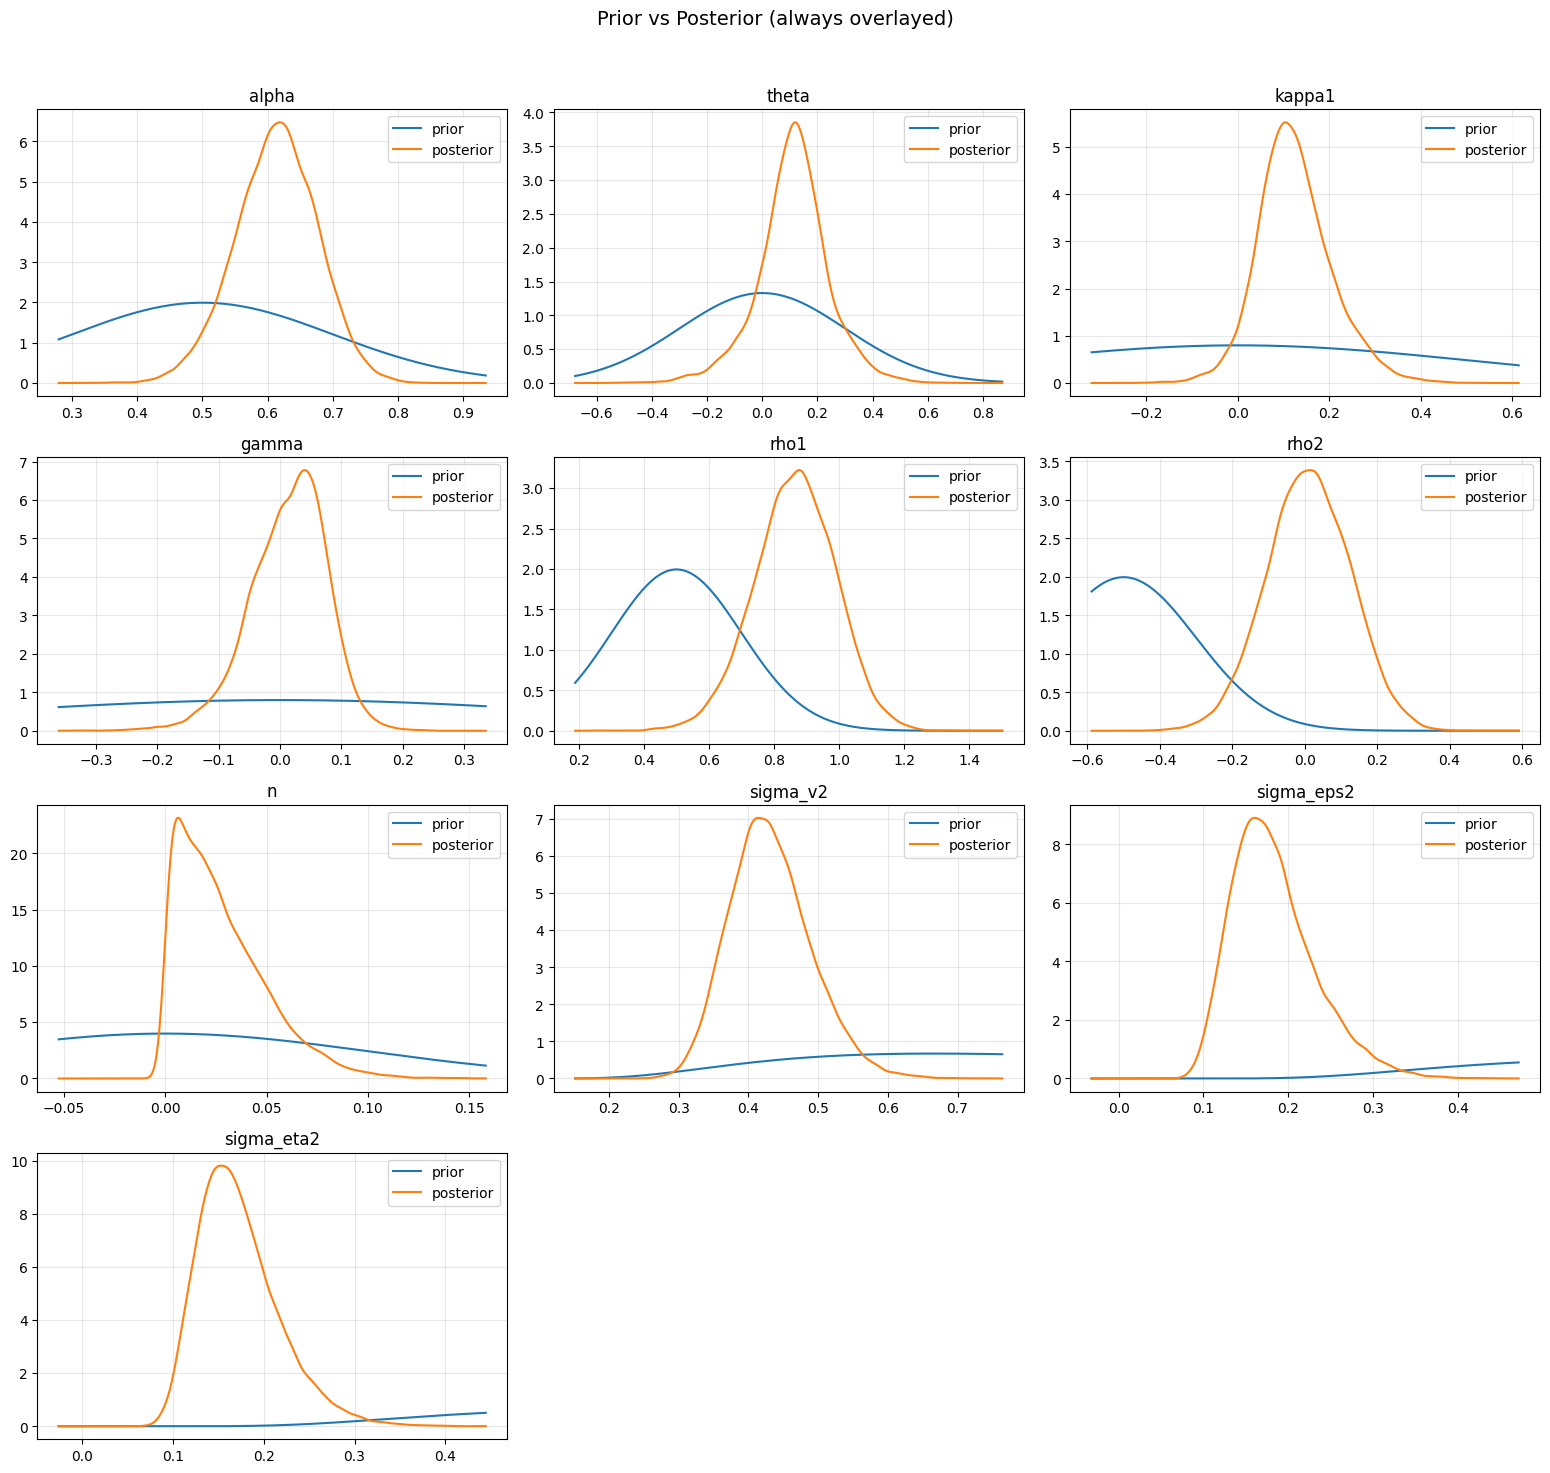

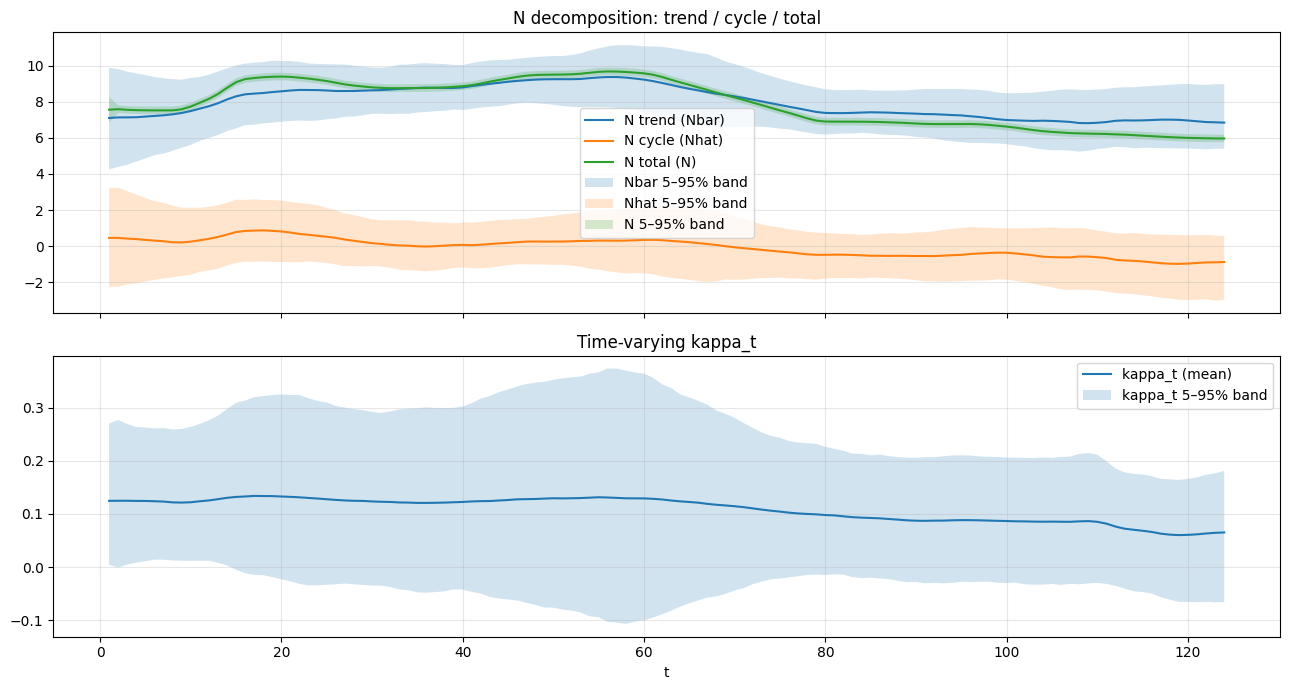

In [31]:
res_3 = func_nkpc_hsa_decomp_tv_kappa_noerror(
    pi_data=pi, pi_prev_data=pi_prev, Epi_data=pi_expect, x_data=x_unempgap, N_data=N,
    n_burn=2000, n_keep=18000,
    priors={"mu_kappa":0.0,"sigma_kappa":0.5,"mu_gamma":0.0,"sigma_gamma":0.5},
    opts={"seed":123, "verbose":True}
)

figs = plot_nkpc_hsa_tv_kappa_results(res_3, bands=(0.05, 0.95), show_bands=True)
plt.show()

Gibbs start: burn-in=2000, keep=18000 (thin=1)
Iter 5000/20000: a=0.583 th=-0.104 k1=0.030 g=-0.021 r1=0.817 r2=0.153
Iter 10000/20000: a=0.589 th=-0.148 k1=-0.039 g=-0.036 r1=0.929 r2=0.044
Iter 15000/20000: a=0.599 th=-0.316 k1=0.155 g=-0.077 r1=0.859 r2=0.037
Iter 20000/20000: a=0.650 th=-0.397 k1=0.072 g=-0.094 r1=0.742 r2=0.014

=== NKPC-HSA (deterministic time-varying kappa) — Posterior means and 95% CI ===
      alpha: 0.6109  [0.4804, 0.7380]
      theta: -0.2005  [-0.4374, -0.0606]
     kappa1: 0.0104  [-0.1727, 0.1569]
      gamma: -0.0452  [-0.1091, 0.0009]
       rho1: 0.8843  [0.6583, 1.1073]
       rho2: 0.0356  [-0.1767, 0.2461]
          n: 0.0193  [0.0006, 0.0626]
   sigma_v2: 0.3932  [0.2964, 0.5180]


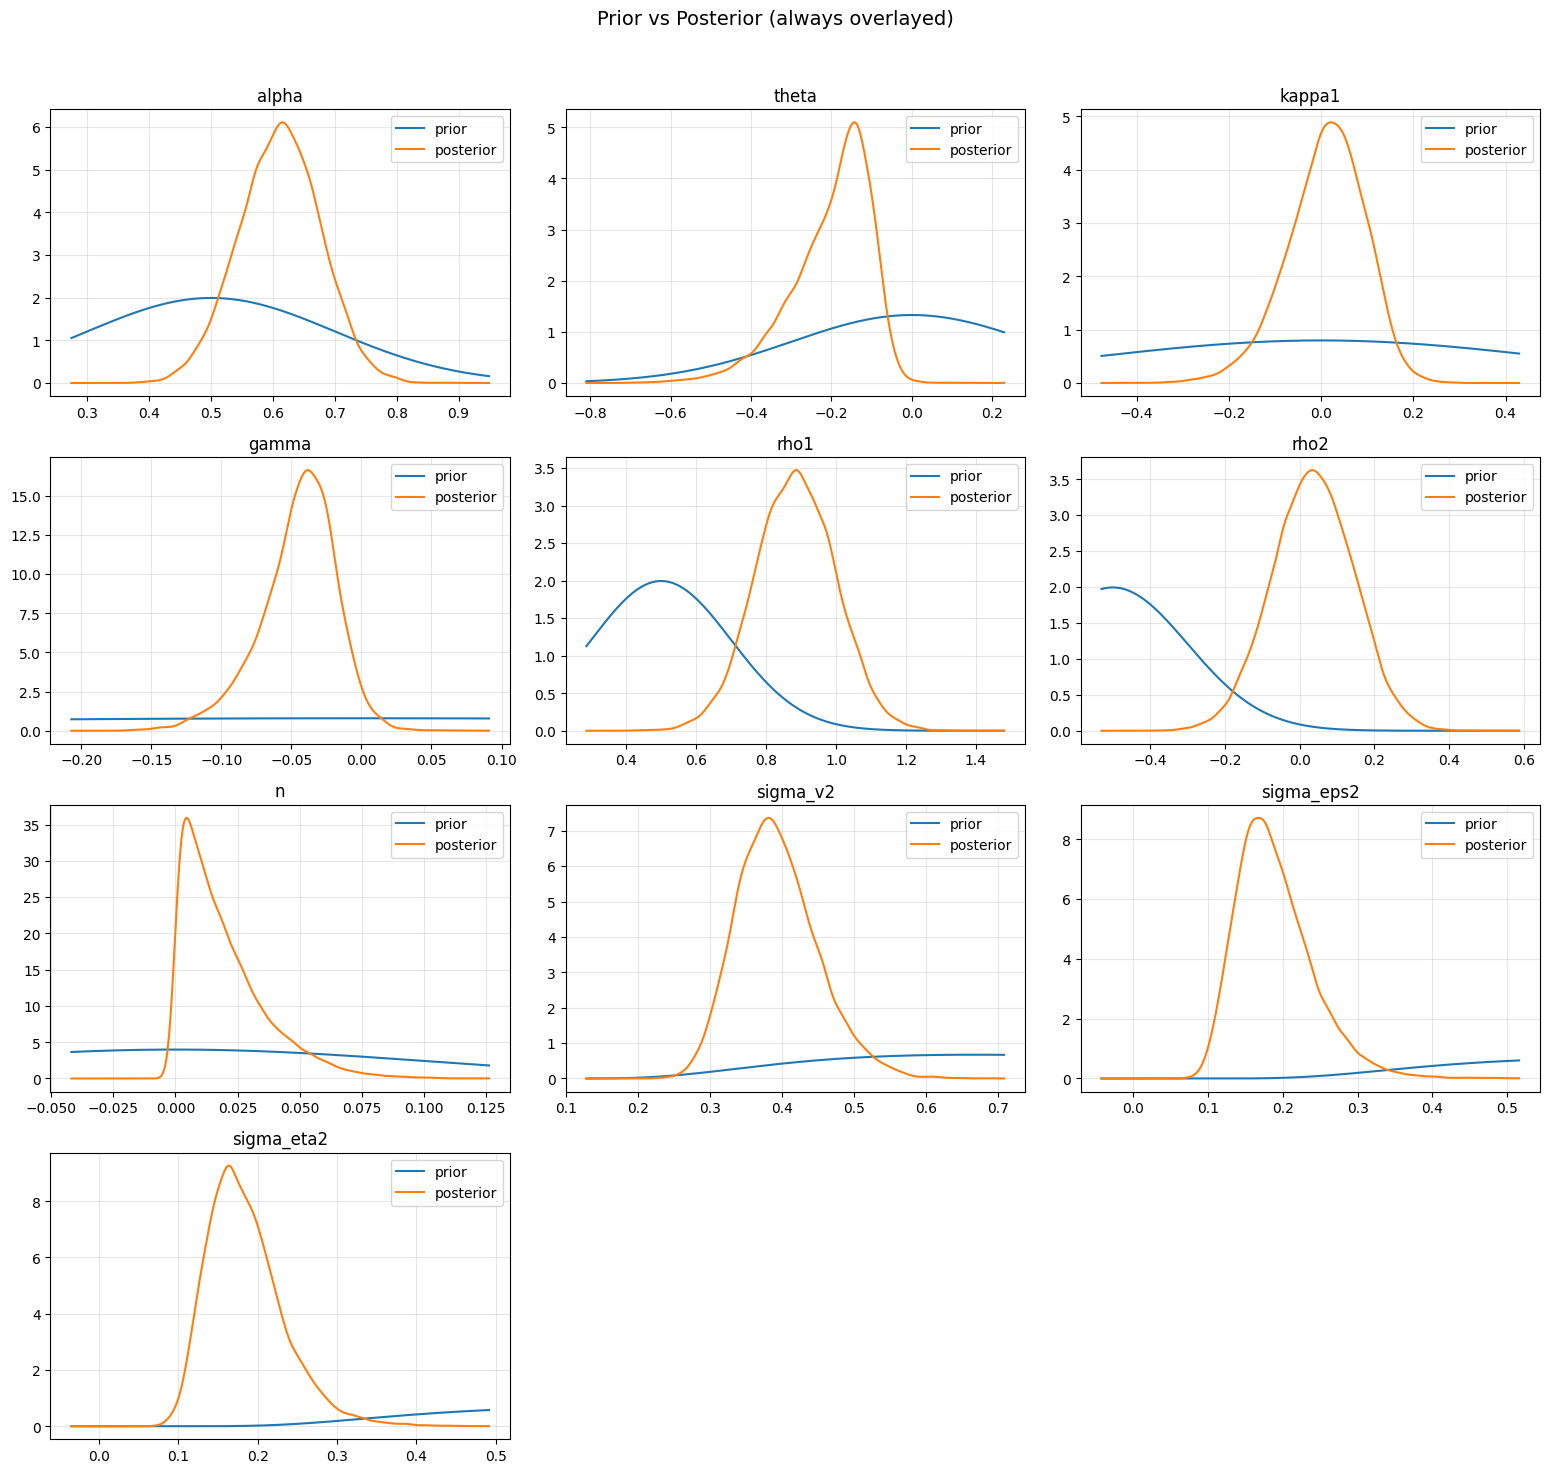

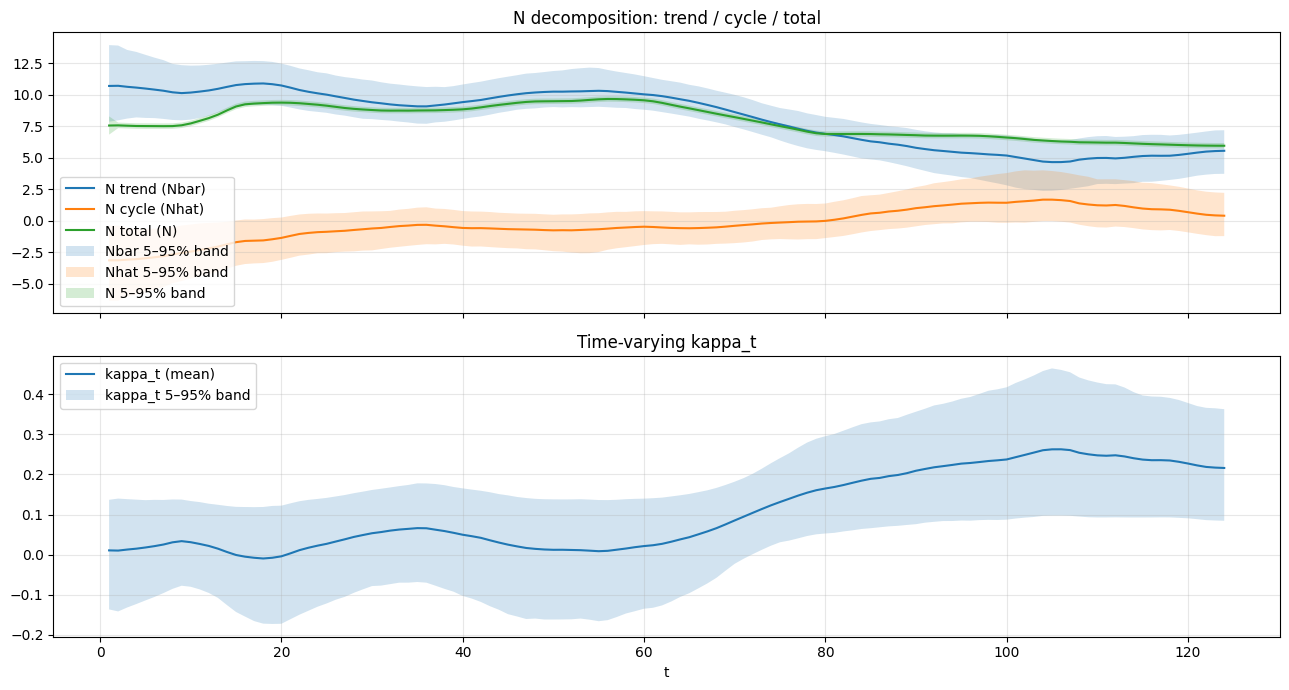

In [32]:
res_3 = func_nkpc_hsa_decomp_tv_kappa_noerror(
    pi_data=pi, pi_prev_data=pi_prev, Epi_data=pi_expect, x_data=x_output_gap, N_data=N,
    n_burn=2000, n_keep=18000,
    priors={"mu_kappa":0.0,"sigma_kappa":0.5,"mu_gamma":0.0,"sigma_gamma":0.5},
    opts={"seed":123, "verbose":True}
)

figs = plot_nkpc_hsa_tv_kappa_results(res_3, bands=(0.05, 0.95), show_bands=True)
plt.show()

Gibbs start: burn-in=2000, keep=18000 (thin=1)
Iter 5000/20000: a=0.552 th=-0.077 k1=-0.072 g=-0.109 r1=0.732 r2=0.138
Iter 10000/20000: a=0.715 th=-0.272 k1=-0.000 g=0.039 r1=0.847 r2=0.089
Iter 15000/20000: a=0.587 th=-0.277 k1=-0.321 g=-0.101 r1=0.797 r2=-0.007
Iter 20000/20000: a=0.733 th=0.064 k1=0.135 g=-0.143 r1=0.948 r2=-0.042

=== NKPC-HSA (deterministic time-varying kappa) — Posterior means and 95% CI ===
      alpha: 0.6346  [0.5112, 0.7552]
      theta: -0.0811  [-0.4276, 0.3857]
     kappa1: -0.0327  [-0.3690, 0.2988]
      gamma: -0.0210  [-0.1688, 0.1305]
       rho1: 0.8361  [0.5777, 1.0792]
       rho2: -0.0049  [-0.2338, 0.2148]
          n: 0.0221  [0.0007, 0.0705]
   sigma_v2: 0.4544  [0.3450, 0.5941]


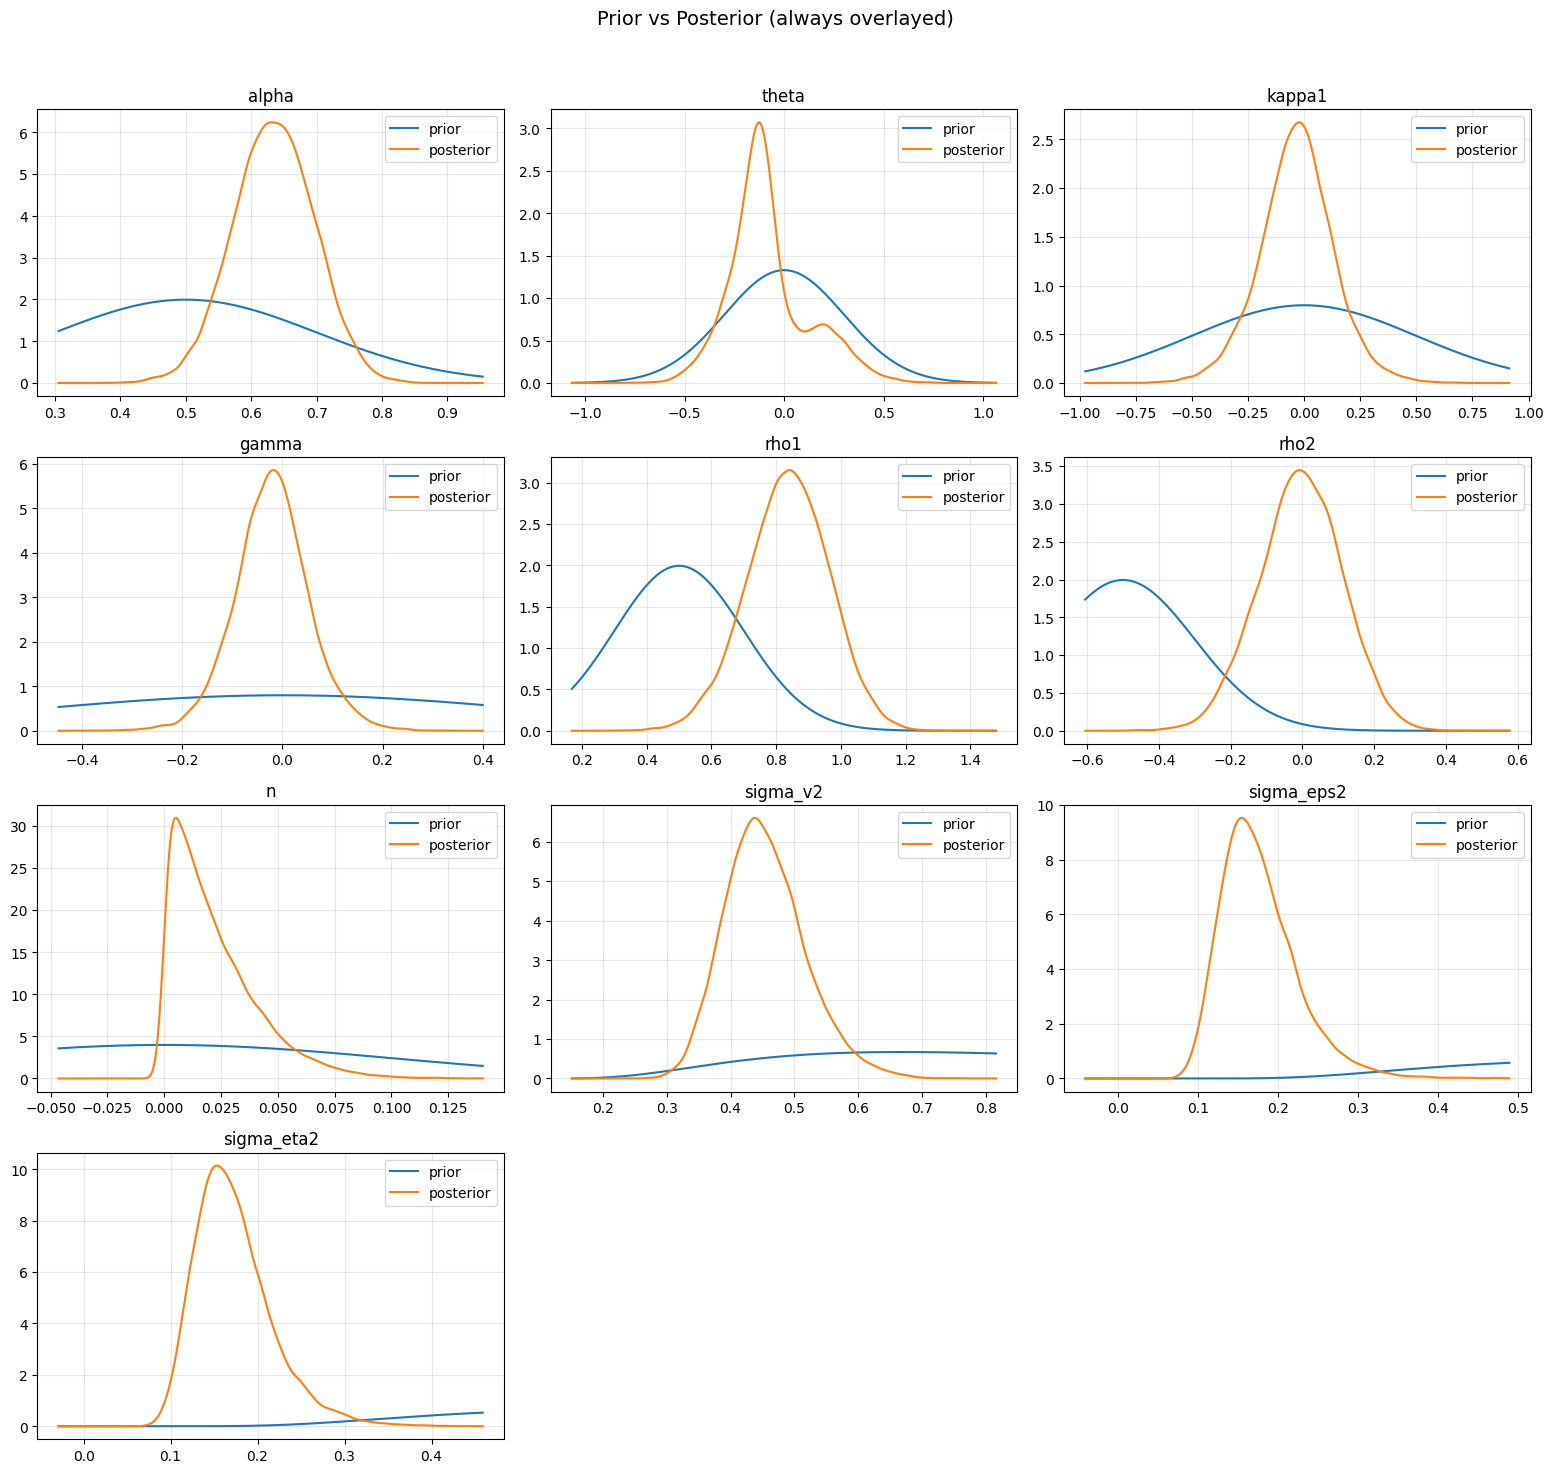

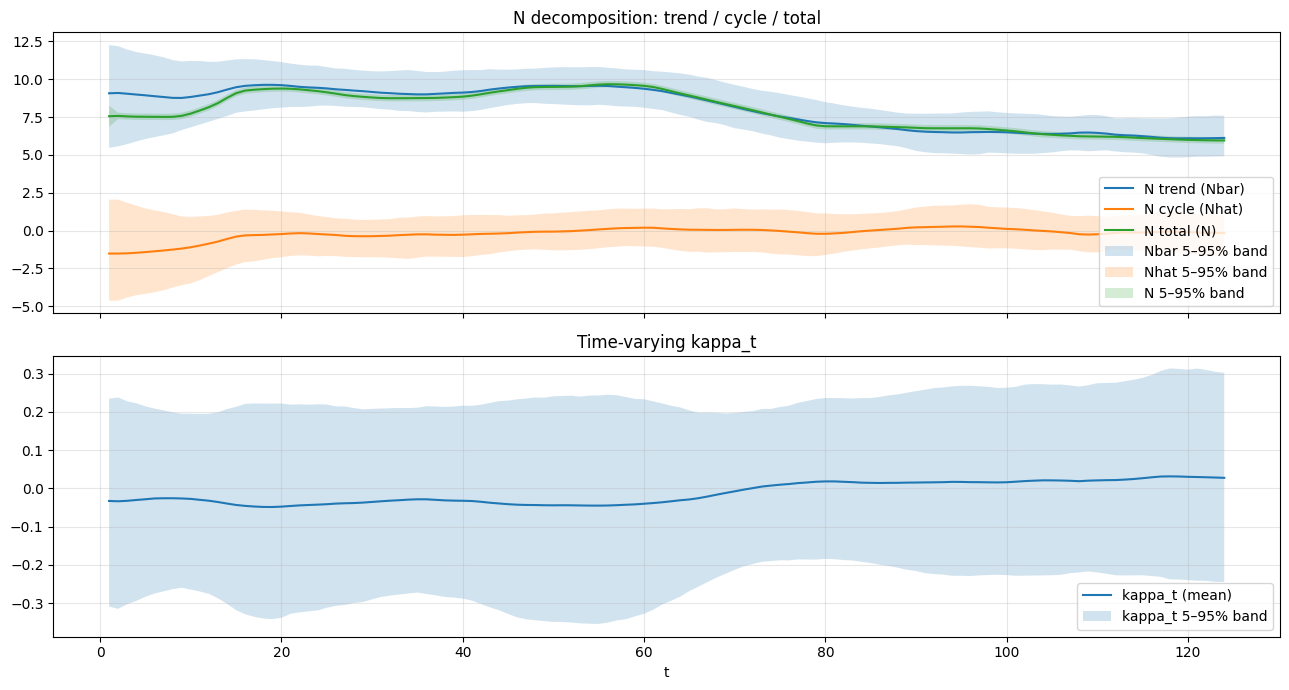

In [33]:
res_3 = func_nkpc_hsa_decomp_tv_kappa_noerror(
    pi_data=pi, pi_prev_data=pi_prev, Epi_data=pi_expect, x_data=x_markup_bn, N_data=N,
    n_burn=2000, n_keep=18000,
    priors={"mu_kappa":0.0,"sigma_kappa":0.5,"mu_gamma":0.0,"sigma_gamma":0.5},
    opts={"seed":123, "verbose":True}
)

figs = plot_nkpc_hsa_tv_kappa_results(res_3, bands=(0.05, 0.95), show_bands=True)
plt.show()

In [34]:
# -*- coding: utf-8 -*-
"""
Deterministic TV-kappa (no error in kappa law) + latent xstar combining two gaps.

Model:

  π_t = α π_{t-1} + (1-α) E_t π_{t+1} + κ_t x*_t − θ N̂_t + v_t,  v_t~N(0,σ_v^2)

  κ_t = κ_{t-1} + γ ΔN̄_t     (NO error)
  => κ_t = κ1 + γ (N̄_t − N̄_1)

  N̂_t = ρ1 N̂_{t-1} + ρ2 N̂_{t-2} + ε_t,   ε_t~N(0,σ_ε^2)
  N̄_t = N̄_{t-1} + n + η_t,                η_t~N(0,σ_η^2)

Latent combined gap:
  x*_t = β x_unempgap_t + (1-β) x_output_gap_t + e_t,   e_t~N(0,σ_e^2)

We sample:
  α, θ, (ρ1,ρ2), n, (κ1,γ), σ_v2, σ_eps2, σ_eta2,
  β, σ_e2, and latent x*_t

Dependencies: numpy
"""

from __future__ import annotations
from typing import Any, Dict, Optional, Tuple

import numpy as np
from numpy.linalg import inv, eig


# ---------- utilities ----------

def getd(d: Optional[Dict[str, Any]], key: str, default: Any) -> Any:
    if isinstance(d, dict) and (key in d) and (d[key] is not None):
        return d[key]
    return default


def assert_all_pos(arr, msg: str):
    arr = np.asarray(arr, dtype=float)
    if np.any(~np.isfinite(arr)) or np.any(arr <= 0):
        raise ValueError(msg)


def is_stationary_ar2(r1: float, r2: float) -> bool:
    return (abs(r2) < 1.0) and ((r1 + r2) < 1.0) and ((r2 - r1) < 1.0)


def force_pd(S: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    S = (S + S.T) / 2.0
    vals, vecs = eig(S)
    vals = np.maximum(vals.real, eps)
    return (vecs.real @ np.diag(vals) @ vecs.real.T)


def mvnrnd(mean: np.ndarray, cov: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    return rng.multivariate_normal(mean, force_pd(cov))


def invgamma_sample_from_posterior(a_post: float, b_post: float, rng: np.random.Generator) -> float:
    # sigma2 ~ InvGamma(shape=a, scale=b)  <=>  1/sigma2 ~ Gamma(shape=a, scale=1/b)
    return 1.0 / rng.gamma(shape=a_post, scale=1.0 / b_post)


# ---------- FFBS blocks (Nbar RW / Nhat AR2) ----------

def sample_rw_states_ffbs_ext(
    y_target: np.ndarray,
    n_drift: float,
    sigma_eta2: float,
    r_rw_scale: float,
    rng: np.random.Generator,
) -> np.ndarray:
    T = len(y_target)
    if T < 2:
        return y_target.copy()

    m = np.zeros(T, dtype=float)
    P = np.zeros(T, dtype=float)
    m[0] = y_target[0]
    P[0] = 10.0

    for t in range(1, T):
        m_pred = n_drift + m[t - 1]
        P_pred = P[t - 1] + sigma_eta2
        R_obs = sigma_eta2 * r_rw_scale
        K = P_pred / (P_pred + R_obs)
        m[t] = m_pred + K * (y_target[t] - m_pred)
        P[t] = (1.0 - K) * P_pred

    Nbar = np.zeros(T, dtype=float)
    Nbar[T - 1] = m[T - 1] + np.sqrt(max(P[T - 1], 1e-8)) * rng.standard_normal()

    for t in range(T - 2, -1, -1):
        A = P[t] / (P[t] + sigma_eta2)
        m_s = m[t] + A * (Nbar[t + 1] - n_drift - m[t])
        P_s = P[t] * (1.0 - A)
        Nbar[t] = m_s + np.sqrt(max(P_s, 1e-8)) * rng.standard_normal()

    return Nbar


def sample_ar2_states_ffbs_ext(
    y_target: np.ndarray,
    rho1: float,
    rho2: float,
    sigma_eps2: float,
    pi_t: np.ndarray,
    alpha: float,
    pi_tm1: np.ndarray,
    E_pi_tp1: np.ndarray,
    kappa_t: np.ndarray,
    xstar_t: np.ndarray,
    theta: float,
    sigma_v2: float,
    r_target_scale: float,
    rng: np.random.Generator,
) -> np.ndarray:
    T = len(y_target)
    if T < 3:
        return y_target.copy()

    F = np.array([[rho1, rho2],
                  [1.0,  0.0]], dtype=float)
    Q = np.array([[sigma_eps2, 0.0],
                  [0.0,       0.0]], dtype=float)

    m = np.zeros((2, T), dtype=float)
    P = np.zeros((2, 2, T), dtype=float)
    m_pred = np.zeros((2, T), dtype=float)
    P_pred = np.zeros((2, 2, T), dtype=float)

    m[:, 0] = np.array([y_target[0], 0.0])
    P[:, :, 0] = np.eye(2) * 10.0

    for t in range(1, T):
        if t > 1:
            m_pred[:, t] = F @ m[:, t - 1]
            P_pred[:, :, t] = F @ P[:, :, t - 1] @ F.T + Q
        else:
            m_pred[:, t] = m[:, t - 1]
            P_pred[:, :, t] = P[:, :, t - 1]

        # obs1: proxy Nhat ~ y_target
        H1 = np.array([[1.0, 0.0]])
        R1 = sigma_eps2 * r_target_scale

        # obs2: NKPC implied theta*Nhat_t ≈ alpha*pi_{t-1} + (1-alpha)Epi_{t+1} + kappa_t*xstar_t - pi_t
        nkpc_obs = alpha * pi_tm1[t] + (1.0 - alpha) * E_pi_tp1[t] + kappa_t[t] * xstar_t[t] - pi_t[t]
        H2 = np.array([[theta, 0.0]])
        R2 = sigma_v2

        H = np.vstack([H1, H2])
        y = np.array([y_target[t], nkpc_obs], dtype=float)
        R = np.diag([R1, R2])

        S = H @ P_pred[:, :, t] @ H.T + R
        K = P_pred[:, :, t] @ H.T @ inv(S)

        m[:, t] = m_pred[:, t] + K @ (y - H @ m_pred[:, t])
        P[:, :, t] = P_pred[:, :, t] - K @ H @ P_pred[:, :, t]

    states = np.zeros((2, T), dtype=float)
    states[:, T - 1] = mvnrnd(m[:, T - 1], P[:, :, T - 1], rng)

    C_s_next = P[:, :, T - 1].copy()
    for t in range(T - 2, -1, -1):
        if t >= 1:
            A = P[:, :, t] @ F.T @ inv(P_pred[:, :, t + 1])
            m_s = m[:, t] + A @ (states[:, t + 1] - m_pred[:, t + 1])
            P_s = P[:, :, t] - A @ (P_pred[:, :, t + 1] - C_s_next) @ A.T
            states[:, t] = mvnrnd(m_s, P_s, rng)
            C_s_next = P_s
        else:
            states[:, t] = states[:, t + 1]

    return states[0, :].copy()


# ---------- deterministic kappa block: sample (kappa1, gamma) ----------

def sample_kappa1_gamma(
    pi_t: np.ndarray,
    pi_tm1: np.ndarray,
    E_pi_tp1: np.ndarray,
    xstar_t: np.ndarray,
    Nhat: np.ndarray,
    Nbar: np.ndarray,
    alpha: float,
    theta: float,
    sigma_v2: float,
    mu_kappa: float,
    sigma_kappa: float,
    mu_gamma: float,
    sigma_gamma: float,
    rng: np.random.Generator,
) -> Tuple[float, float, np.ndarray]:
    """
    kappa_t = kappa1 + gamma*(Nbar_t - Nbar_1)

    NKPC rearranged:
      y_t = kappa_t * xstar_t + v_t
    BUT kappa_t depends on (kappa1,gamma) linearly:

      y_t = xstar_t*kappa1 + xstar_t*(Nbar_t-Nbar_1)*gamma + v_t
    """
    y = pi_t - alpha * pi_tm1 - (1.0 - alpha) * E_pi_tp1 + theta * Nhat
    dlevel = Nbar - Nbar[0]

    X = np.column_stack([xstar_t, xstar_t * dlevel])  # T x 2

    Prec0 = np.diag([1.0 / (sigma_kappa ** 2), 1.0 / (sigma_gamma ** 2)])
    m0 = np.array([mu_kappa, mu_gamma], dtype=float)

    PrecD = (X.T @ X) / sigma_v2
    PostP = Prec0 + PrecD
    PostC = inv(PostP)
    PostM = PostC @ (Prec0 @ m0 + (X.T @ y) / sigma_v2)

    beta = mvnrnd(PostM, PostC, rng)
    kappa1, gamma = float(beta[0]), float(beta[1])

    kappa_t = kappa1 + gamma * dlevel
    return kappa1, gamma, kappa_t


# ---------- xstar block (latent) ----------

def compute_mix(xu: np.ndarray, xo: np.ndarray, beta: float) -> np.ndarray:
    return beta * xu + (1.0 - beta) * xo


def sample_xstar_t(
    pi_t: np.ndarray,
    pi_tm1: np.ndarray,
    E_pi_tp1: np.ndarray,
    Nhat: np.ndarray,
    alpha: float,
    theta: float,
    kappa_t: np.ndarray,
    sigma_v2: float,
    mix: np.ndarray,
    sigma_e2: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Prior (measurement): x*_t ~ N(mix_t, sigma_e2)
    NKPC likelihood: y_t = kappa_t * x*_t + v_t,
        where y_t = pi_t - alpha*pi_tm1 - (1-alpha)Epi + theta*Nhat
    => posterior x*_t is Normal independently for each t.
    """
    y = pi_t - alpha * pi_tm1 - (1.0 - alpha) * E_pi_tp1 + theta * Nhat

    # precision terms
    prec_prior = 1.0 / sigma_e2
    prec_like = (kappa_t * kappa_t) / sigma_v2
    post_prec = prec_prior + prec_like
    post_var = 1.0 / np.maximum(post_prec, 1e-16)

    post_mean = post_var * (prec_prior * mix + (kappa_t * y) / sigma_v2)

    return post_mean + np.sqrt(np.maximum(post_var, 1e-16)) * rng.standard_normal(size=y.shape[0])


def sample_beta_given_xstar(
    xstar: np.ndarray,
    xu: np.ndarray,
    xo: np.ndarray,
    sigma_e2: float,
    mu_beta: float,
    sigma_beta: float,
    rng: np.random.Generator,
    constrain_01: bool = True,
) -> float:
    """
    xstar_t = xo_t + beta*(xu_t - xo_t) + e_t
    Let y = xstar - xo, z = xu - xo
    y = beta*z + e, e~N(0,sigma_e2)

    Conjugate Normal update, optionally truncated to [0,1] by rejection.
    """
    y = xstar - xo
    z = xu - xo

    prec0 = 1.0 / (sigma_beta ** 2)
    precD = float(np.sum(z * z)) / sigma_e2
    postV = 1.0 / (prec0 + precD)
    postM = postV * (prec0 * mu_beta + float(np.sum(z * y)) / sigma_e2)

    if not constrain_01:
        return float(postM + np.sqrt(postV) * rng.standard_normal())

    # truncated to [0,1] by rejection
    for _ in range(20000):
        b = float(postM + np.sqrt(postV) * rng.standard_normal())
        if 0.0 <= b <= 1.0:
            return b
    # fallback clip
    return float(np.clip(postM, 0.0, 1.0))


def sample_sigma_e2(
    xstar: np.ndarray,
    xu: np.ndarray,
    xo: np.ndarray,
    beta: float,
    a_e: float,
    b_e: float,
    rng: np.random.Generator,
) -> float:
    mix = compute_mix(xu, xo, beta)
    e = xstar - mix
    a_post = a_e + e.size / 2.0
    b_post = b_e + 0.5 * float(np.sum(e * e))
    return float(invgamma_sample_from_posterior(a_post, b_post, rng))


# ---------- main ----------

def func_nkpc_hsa_decomp_tv_kappa_noerror_xstar(
    pi_data,
    pi_prev_data,
    Epi_data,
    x_unempgap_data,
    x_output_gap_data,
    N_data,
    n_burn: int,
    n_keep: int,
    priors: Optional[Dict[str, Any]] = None,
    opts: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    # ---- Data ----
    pi_t = np.asarray(pi_data, dtype=float).reshape(-1)
    pi_tm1 = np.asarray(pi_prev_data, dtype=float).reshape(-1)
    E_pi_tp1 = np.asarray(Epi_data, dtype=float).reshape(-1)
    xu = np.asarray(x_unempgap_data, dtype=float).reshape(-1)
    xo = np.asarray(x_output_gap_data, dtype=float).reshape(-1)
    N_obs = np.asarray(N_data, dtype=float).reshape(-1)

    T = pi_t.size
    if not (pi_tm1.size == E_pi_tp1.size == xu.size == xo.size == N_obs.size == T):
        raise ValueError("All input series must have the same length T.")

    # ---- Priors ----
    priors = priors or {}

    mu_alpha = getd(priors, "mu_alpha", 0.5)
    sigma_alpha = getd(priors, "sigma_alpha", 0.2)

    mu_theta = getd(priors, "mu_theta", 0.0)
    sigma_theta = getd(priors, "sigma_theta", 0.3)

    mu_rho1 = getd(priors, "mu_rho1", 0.5)
    sigma_rho1 = getd(priors, "sigma_rho1", 0.2)
    mu_rho2 = getd(priors, "mu_rho2", -0.5)
    sigma_rho2 = getd(priors, "sigma_rho2", 0.2)

    mu_n = getd(priors, "mu_n", 0.0)
    sigma_n = getd(priors, "sigma_n", 0.1)

    # kappa1 / gamma priors
    mu_kappa = getd(priors, "mu_kappa", 0.0)
    sigma_kappa = getd(priors, "sigma_kappa", 0.3)
    mu_gamma = getd(priors, "mu_gamma", 0.0)
    sigma_gamma = getd(priors, "sigma_gamma", 0.3)

    # beta prior (convex weight)
    mu_beta = getd(priors, "mu_beta", 0.5)
    sigma_beta = getd(priors, "sigma_beta", 0.2)

    # variances priors (InvGamma)
    a_v = getd(priors, "a_v", 2.0)
    b_v = getd(priors, "b_v", 2.0)
    a_eps = getd(priors, "a_eps", 2.0)
    b_eps = getd(priors, "b_eps", 2.0)
    a_eta = getd(priors, "a_eta", 2.0)
    b_eta = getd(priors, "b_eta", 2.0)

    # xstar noise variance prior
    a_e = getd(priors, "a_e", 2.0)
    b_e = getd(priors, "b_e", 2.0)

    assert_all_pos(
        [sigma_alpha, sigma_theta, sigma_rho1, sigma_rho2, sigma_n,
         sigma_kappa, sigma_gamma, sigma_beta, a_v, b_v, a_eps, b_eps, a_eta, b_eta, a_e, b_e],
        "Prior stds and IG params must be positive."
    )

    # ---- Options ----
    opts = opts or {}
    alpha = float(getd(opts, "alpha0", 0.6))
    theta = float(getd(opts, "theta0", 0.5))
    rho1 = float(getd(opts, "rho10", 0.5))
    rho2 = float(getd(opts, "rho20", -0.5))
    n_drift = float(getd(opts, "n0", 0.01))

    kappa1 = float(getd(opts, "kappa10", getd(opts, "kappa0", 0.3)))
    gamma = float(getd(opts, "gamma0", 0.0))

    beta = float(getd(opts, "beta0", 0.5))
    sigma_e2 = float(getd(opts, "sigma_e20", 0.2))

    sigma_v2 = float(getd(opts, "sigma_v20", 1.0))
    sigma_eps2 = float(getd(opts, "sigma_eps20", 0.5))
    sigma_eta2 = float(getd(opts, "sigma_eta20", 0.1))

    seed = getd(opts, "seed", None)
    verbose = bool(getd(opts, "verbose", True))
    store_every = int(max(1, getd(opts, "store_every", 1)))
    enforce_station = bool(getd(opts, "enforce_stationary", True))
    r_target_scale = float(getd(opts, "r_target_scale", 0.1))
    r_rw_scale = float(getd(opts, "r_rw_scale", 0.1))

    constrain_beta = bool(getd(opts, "constrain_beta_01", True))

    rng = np.random.default_rng(seed)

    # ---- Initialize states ----
    Nbar = np.zeros(T, dtype=float)
    k0 = min(2, T)
    Nbar[:k0] = N_obs[:k0]
    for t in range(2, T):
        Nbar[t] = 0.7 * Nbar[t - 1] + 0.3 * N_obs[t]
    Nhat = N_obs - Nbar

    # init xstar from mix
    mix = compute_mix(xu, xo, beta)
    xstar_t = mix.copy()

    # init kappa from Nbar
    kappa_t = kappa1 + gamma * (Nbar - Nbar[0])

    # ---- Storage ----
    n_store = int(np.ceil(n_keep / store_every))
    alpha_draws = np.zeros(n_store)
    theta_draws = np.zeros(n_store)
    rho1_draws = np.zeros(n_store)
    rho2_draws = np.zeros(n_store)
    n_draws = np.zeros(n_store)
    kappa1_draws = np.zeros(n_store)
    gamma_draws = np.zeros(n_store)
    beta_draws = np.zeros(n_store)
    se2_draws = np.zeros(n_store)

    sv_draws = np.zeros(n_store)
    seps_draws = np.zeros(n_store)
    seta_draws = np.zeros(n_store)

    Nbar_draws = np.zeros((n_store, T))
    Nhat_draws = np.zeros((n_store, T))
    kappa_draws = np.zeros((n_store, T))
    xstar_draws = np.zeros((n_store, T))

    if verbose:
        print(f"Gibbs start: burn-in={n_burn}, keep={n_keep} (thin={store_every})")

    total_iter = n_burn + n_keep
    store_idx = 0

    for it in range(1, total_iter + 1):

        # ---- (1) sample latent xstar_t | beta, sigma_e2, others
        mix = compute_mix(xu, xo, beta)
        xstar_t = sample_xstar_t(
            pi_t=pi_t, pi_tm1=pi_tm1, E_pi_tp1=E_pi_tp1,
            Nhat=Nhat, alpha=alpha, theta=theta,
            kappa_t=kappa_t, sigma_v2=sigma_v2,
            mix=mix, sigma_e2=sigma_e2, rng=rng
        )

        # ---- (2) alpha | . (uses xstar_t)
        y_a = pi_t - E_pi_tp1 - (kappa_t * xstar_t) + theta * Nhat
        X_a = pi_tm1 - E_pi_tp1
        XtX = float(X_a @ X_a)
        if XtX > 1e-12:
            prec0 = 1.0 / (sigma_alpha ** 2)
            precD = XtX / sigma_v2
            postV = 1.0 / (prec0 + precD)
            postM = postV * (prec0 * mu_alpha + float(X_a @ y_a) / sigma_v2)
            alpha = float(postM + np.sqrt(postV) * rng.standard_normal())

        # ---- (3) theta | . (uses xstar_t)
        y_th = pi_t - alpha * pi_tm1 - (1.0 - alpha) * E_pi_tp1 - (kappa_t * xstar_t)
        X_th = -Nhat
        XtX = float(X_th @ X_th)
        if XtX > 1e-12:
            prec0 = 1.0 / (sigma_theta ** 2)
            precD = XtX / sigma_v2
            postV = 1.0 / (prec0 + precD)
            postM = postV * (prec0 * mu_theta + float(X_th @ y_th) / sigma_v2)
            theta = float(postM + np.sqrt(postV) * rng.standard_normal())

        # ---- (4) AR(2) params for Nhat | .
        if T >= 3:
            y_r = Nhat[2:]
            X_r = np.column_stack([Nhat[1:-1], Nhat[:-2]])
            Prec0 = np.diag([1.0 / (sigma_rho1 ** 2), 1.0 / (sigma_rho2 ** 2)])
            PrecD = (X_r.T @ X_r) / sigma_eps2
            PostP = Prec0 + PrecD
            PostC = inv(PostP)
            mu0 = np.array([mu_rho1, mu_rho2], dtype=float)
            PostM = PostC @ (Prec0 @ mu0 + (X_r.T @ y_r) / sigma_eps2)

            ok = False
            tries = 0
            while (not ok) and (tries < 2000):
                rdraw = mvnrnd(PostM, PostC, rng)
                if (not enforce_station) or is_stationary_ar2(float(rdraw[0]), float(rdraw[1])):
                    rho1, rho2 = float(rdraw[0]), float(rdraw[1])
                    ok = True
                tries += 1
            if not ok:
                rho1, rho2 = float(PostM[0]), float(PostM[1])

        # ---- (5) RW drift n | .
        if T >= 2:
            y_n = Nbar[1:] - Nbar[:-1]
            Tn = y_n.size
            prec0 = 1.0 / (sigma_n ** 2)
            precD = Tn / sigma_eta2
            postV = 1.0 / (prec0 + precD)
            postM = postV * (prec0 * mu_n + float(np.sum(y_n)) / sigma_eta2)
            n_drift = float(postM + np.sqrt(postV) * rng.standard_normal())
            tries = 0
            while (n_drift <= 0.0) and (tries < 10000):
                n_drift = float(postM + np.sqrt(postV) * rng.standard_normal())
                tries += 1
            if n_drift <= 0.0:
                n_drift = float(abs(postM))

        # ---- (6) (kappa1, gamma) | .  using xstar_t
        kappa1, gamma, kappa_t = sample_kappa1_gamma(
            pi_t=pi_t, pi_tm1=pi_tm1, E_pi_tp1=E_pi_tp1,
            xstar_t=xstar_t, Nhat=Nhat, Nbar=Nbar,
            alpha=alpha, theta=theta, sigma_v2=sigma_v2,
            mu_kappa=float(mu_kappa), sigma_kappa=float(sigma_kappa),
            mu_gamma=float(mu_gamma), sigma_gamma=float(sigma_gamma),
            rng=rng
        )

        # ---- (7) beta | xstar, sigma_e2
        beta = sample_beta_given_xstar(
            xstar=xstar_t, xu=xu, xo=xo, sigma_e2=sigma_e2,
            mu_beta=float(mu_beta), sigma_beta=float(sigma_beta),
            rng=rng, constrain_01=constrain_beta
        )

        # ---- (8) sigma_e2 | xstar, beta
        sigma_e2 = sample_sigma_e2(
            xstar=xstar_t, xu=xu, xo=xo, beta=beta,
            a_e=float(a_e), b_e=float(b_e), rng=rng
        )

        # ---- (9) variances
        nkpc_resid = pi_t - alpha * pi_tm1 - (1.0 - alpha) * E_pi_tp1 - (kappa_t * xstar_t) + theta * Nhat
        a_post = a_v + T / 2.0
        b_post = b_v + 0.5 * float(np.sum(nkpc_resid ** 2))
        sigma_v2 = float(invgamma_sample_from_posterior(a_post, b_post, rng))

        if T >= 3:
            ar_res = Nhat[2:] - rho1 * Nhat[1:-1] - rho2 * Nhat[:-2]
            a_post = a_eps + ar_res.size / 2.0
            b_post = b_eps + 0.5 * float(np.sum(ar_res ** 2))
            sigma_eps2 = float(invgamma_sample_from_posterior(a_post, b_post, rng))

        if T >= 2:
            rw_res = Nbar[1:] - n_drift - Nbar[:-1]
            a_post = a_eta + rw_res.size / 2.0
            b_post = b_eta + 0.5 * float(np.sum(rw_res ** 2))
            sigma_eta2 = float(invgamma_sample_from_posterior(a_post, b_post, rng))

        # ---- (10) FFBS for Nhat and Nbar (uses xstar_t)
        Nhat = sample_ar2_states_ffbs_ext(
            y_target=N_obs - Nbar,
            rho1=rho1, rho2=rho2, sigma_eps2=sigma_eps2,
            pi_t=pi_t, alpha=alpha, pi_tm1=pi_tm1, E_pi_tp1=E_pi_tp1,
            kappa_t=kappa_t, xstar_t=xstar_t,
            theta=theta, sigma_v2=sigma_v2,
            r_target_scale=r_target_scale,
            rng=rng
        )

        Nbar = sample_rw_states_ffbs_ext(
            y_target=N_obs - Nhat,
            n_drift=n_drift, sigma_eta2=sigma_eta2,
            r_rw_scale=r_rw_scale,
            rng=rng
        )

        # after Nbar update, refresh kappa_t (deterministic)
        kappa_t = kappa1 + gamma * (Nbar - Nbar[0])

        # ---- store
        if (it > n_burn) and ((it - n_burn) % store_every == 0):
            idx = store_idx
            alpha_draws[idx] = alpha
            theta_draws[idx] = theta
            rho1_draws[idx] = rho1
            rho2_draws[idx] = rho2
            n_draws[idx] = n_drift
            kappa1_draws[idx] = kappa1
            gamma_draws[idx] = gamma
            beta_draws[idx] = beta
            se2_draws[idx] = sigma_e2

            sv_draws[idx] = sigma_v2
            seps_draws[idx] = sigma_eps2
            seta_draws[idx] = sigma_eta2

            Nbar_draws[idx, :] = Nbar
            Nhat_draws[idx, :] = Nhat
            kappa_draws[idx, :] = kappa_t
            xstar_draws[idx, :] = xstar_t

            store_idx += 1

        if verbose and (it % 5000 == 0):
            print(f"Iter {it}/{total_iter}: a={alpha:.3f} th={theta:.3f} k1={kappa1:.3f} g={gamma:.3f} beta={beta:.3f}")

    # ---- results
    def add_sum(v: np.ndarray) -> Dict[str, Any]:
        v = np.asarray(v, dtype=float)
        qs = np.quantile(v, [0.025, 0.05, 0.25, 0.5, 0.75, 0.95, 0.975])
        return {"draws": v, "mean": float(np.mean(v)),
                "std": float(np.std(v, ddof=1)) if v.size > 1 else 0.0,
                "quantiles": qs}

    out: Dict[str, Any] = {}
    out["alpha"] = add_sum(alpha_draws)
    out["theta"] = add_sum(theta_draws)
    out["rho1"] = add_sum(rho1_draws)
    out["rho2"] = add_sum(rho2_draws)
    out["n"] = add_sum(n_draws)
    out["kappa1"] = add_sum(kappa1_draws)
    out["gamma"] = add_sum(gamma_draws)
    out["beta"] = add_sum(beta_draws)
    out["sigma_e2"] = add_sum(se2_draws)

    out["sigma_v2"] = add_sum(sv_draws)
    out["sigma_eps2"] = add_sum(seps_draws)
    out["sigma_eta2"] = add_sum(seta_draws)

    out["states"] = {
        "Nbar_mean": np.mean(Nbar_draws, axis=0),
        "Nhat_mean": np.mean(Nhat_draws, axis=0),
        "N_mean": np.mean(Nbar_draws + Nhat_draws, axis=0),
        "kappa_mean": np.mean(kappa_draws, axis=0),
        "xstar_mean": np.mean(xstar_draws, axis=0),
    }
    out["state_draws"] = {"Nbar": Nbar_draws, "Nhat": Nhat_draws, "kappa": kappa_draws, "xstar": xstar_draws}

    out["priors"] = priors
    out["opts"] = opts

    if verbose:
        print("\n=== Posterior means and 95% CI ===")
        for key in ["alpha", "theta", "kappa1", "gamma", "beta", "sigma_e2", "sigma_v2"]:
            q = out[key]["quantiles"]
            print(f"{key:>10s}: {out[key]['mean']:.4f}  [{q[0]:.4f}, {q[6]:.4f}]")

    return out

In [35]:
res = func_nkpc_hsa_decomp_tv_kappa_noerror_xstar(
    pi_data=pi,
    pi_prev_data=pi_prev,
    Epi_data=pi_expect,
    x_unempgap_data=x_unempgap,
    x_output_gap_data=x_output_gap,
    N_data=N,
    n_burn=2000,
    n_keep=5000,
    priors={
        "mu_beta": 0.5, "sigma_beta": 0.2,
        "a_e": 2.0, "b_e": 2.0,
        # 他は省略可（デフォルトを使うなら）
    },
    opts={"seed": 123, "beta0": 0.5, "sigma_e20": 0.2, "verbose": True}
)

xstar_path = res["states"]["xstar_mean"]
beta_post = res["beta"]["mean"]

Gibbs start: burn-in=2000, keep=5000 (thin=1)
Iter 5000/7000: a=0.688 th=0.007 k1=0.099 g=-0.080 beta=0.153

=== Posterior means and 95% CI ===
     alpha: 0.6369  [0.5150, 0.7628]
     theta: -0.1298  [-0.3666, 0.1365]
    kappa1: 0.0772  [-0.1154, 0.3208]
     gamma: -0.0429  [-0.1887, 0.0792]
      beta: 0.3720  [0.0530, 0.7872]
  sigma_e2: 3.2542  [0.4343, 10.1787]
  sigma_v2: 0.3214  [0.1680, 0.5184]


In [38]:
res["beta"]["mean"]

0.3720053005655971

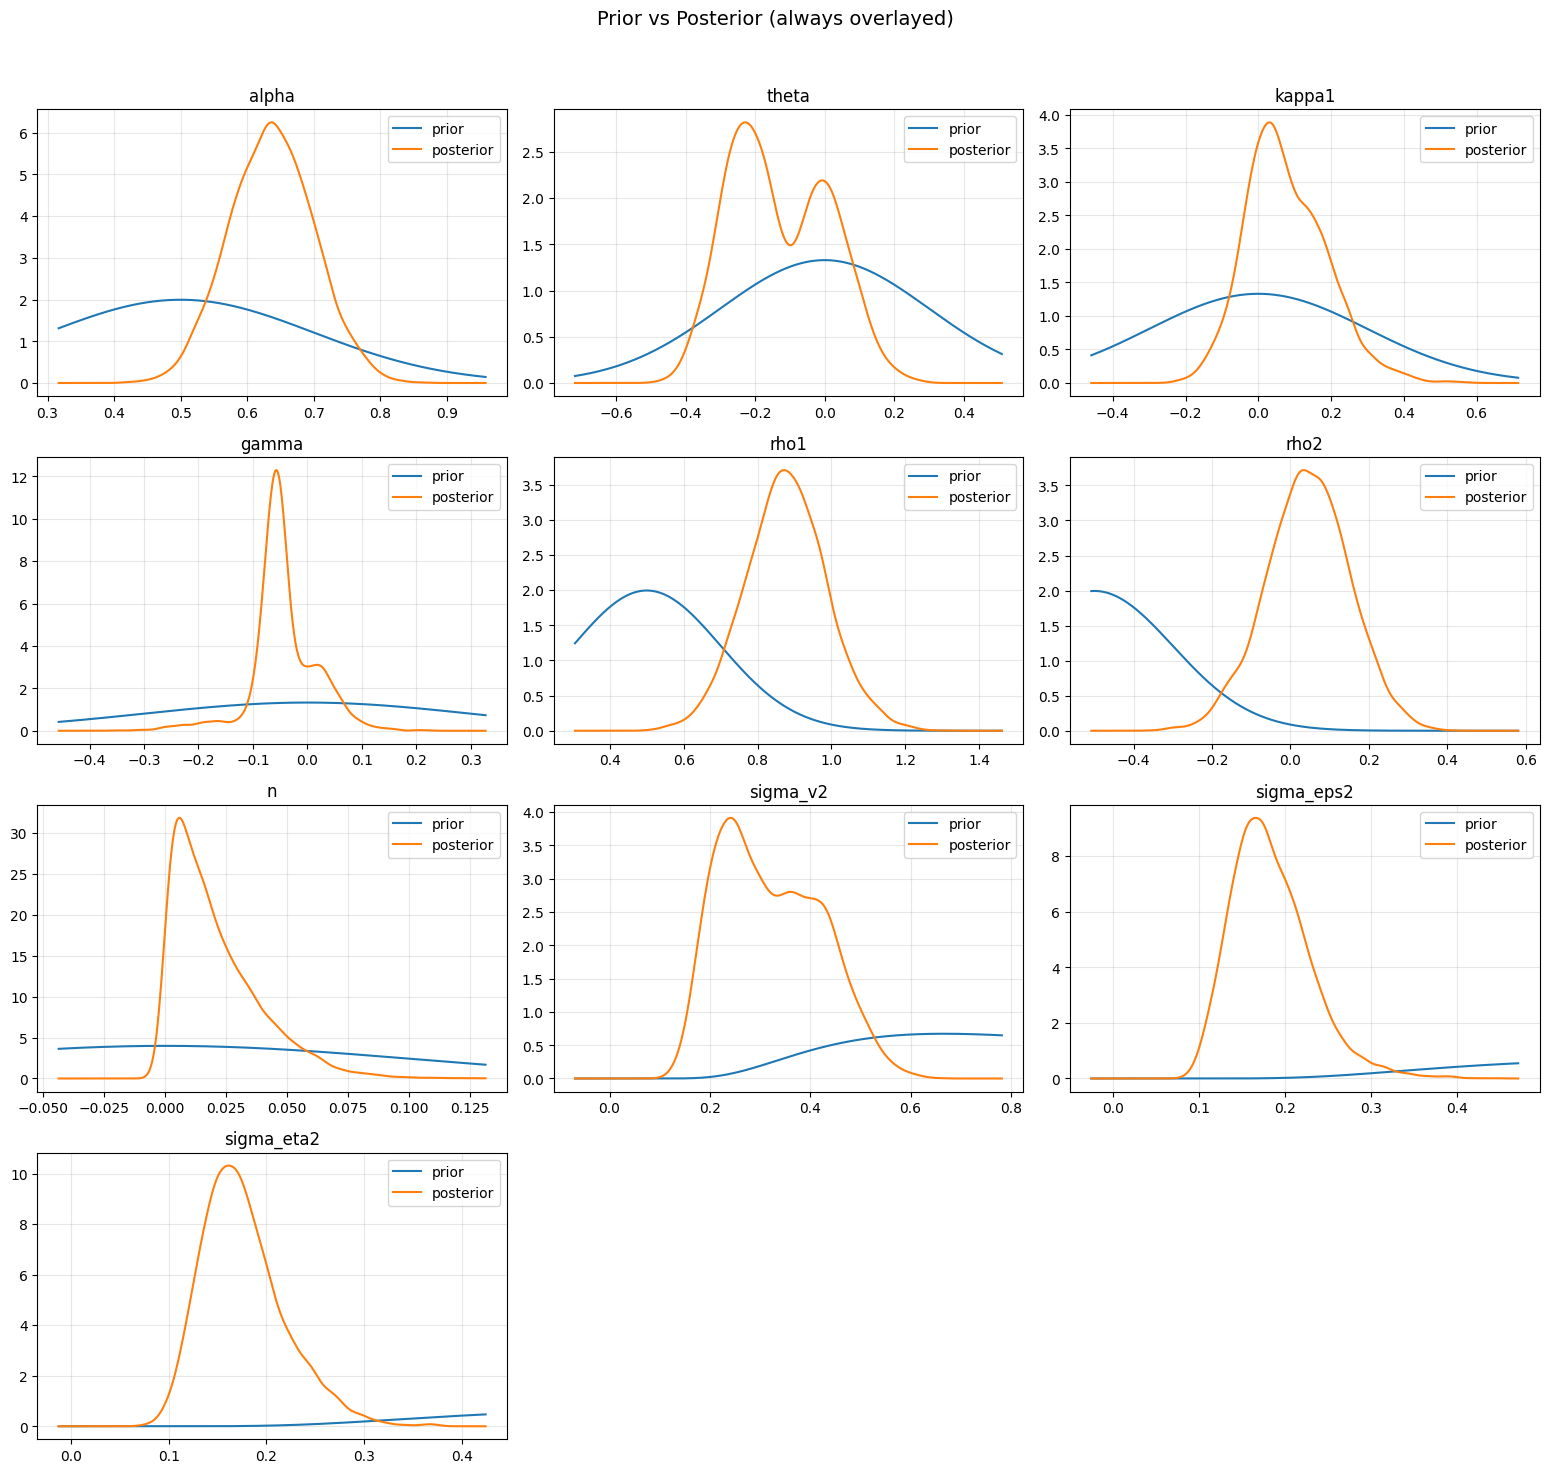

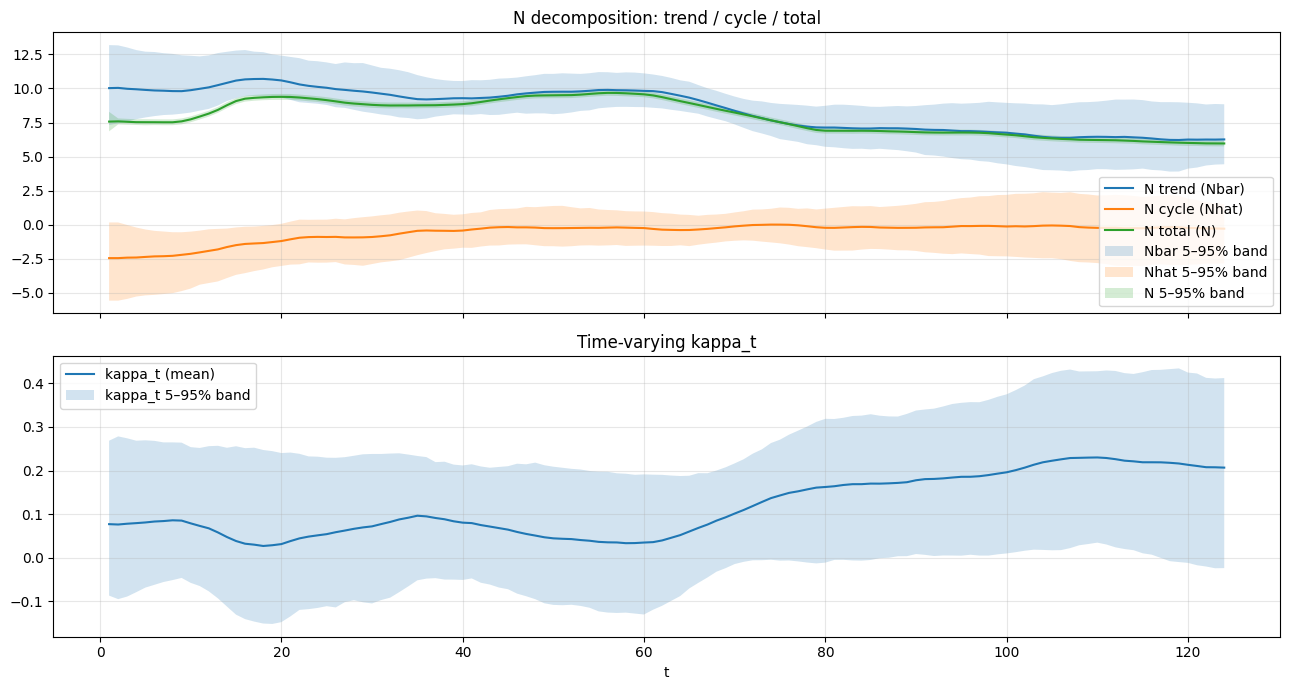

In [36]:
figs = plot_nkpc_hsa_tv_kappa_results(res, bands=(0.05, 0.95), show_bands=True)
plt.show()

In [ ]:
# ============================================================================
# Marginal Likelihood Estimation: Chib Method and Bridge Sampling
# ============================================================================
"""
This cell implements two methods for computing the marginal likelihood:
1. Chib Method (Chib & Jeliazkov, 2001) - uses posterior ordinate decomposition
2. Bridge Sampling (Meng & Wong, 1996) - uses importance sampling with bridge distribution

Both methods are used for Bayesian model comparison via Bayes factors.
"""

from scipy.stats import norm, invgamma
from scipy.special import gammaln

def log_normpdf(x, mu, sigma):
    """Log of normal PDF"""
    return -0.5 * np.log(2 * np.pi) - np.log(sigma) - 0.5 * ((x - mu) / sigma) ** 2

def log_invgampdf(x, a, b):
    """Log of inverse-gamma PDF (shape-scale parameterization)"""
    if x <= 0:
        return -np.inf
    return a * np.log(b) - gammaln(a) - (a + 1) * np.log(x) - b / x

def compute_log_likelihood_nkpc_hsa(
    pi_t, pi_tm1, E_pi_tp1, x_t, Nhat, Nbar,
    alpha, kappa, theta, sigma_v2
):
    """
    Compute log-likelihood for NKPC-HSA model
    
    Model: pi_t = alpha*pi_{t-1} + (1-alpha)*E_t[pi_{t+1}] + kappa*x_t - theta*Nhat_t + v_t
    where v_t ~ N(0, sigma_v2)
    """
    T = len(pi_t)
    residuals = pi_t - alpha * pi_tm1 - (1.0 - alpha) * E_pi_tp1 - kappa * x_t + theta * Nhat
    log_lik = -0.5 * T * np.log(2 * np.pi) - 0.5 * T * np.log(sigma_v2) - 0.5 * np.sum(residuals ** 2) / sigma_v2
    return log_lik

def compute_log_prior_nkpc_hsa(
    alpha, kappa, theta, rho1, rho2, n_drift,
    sigma_v2, sigma_eps2, sigma_eta2,
    priors
):
    """Compute log-prior for all parameters"""
    log_prior = 0.0
    
    # NKPC parameters
    log_prior += log_normpdf(alpha, priors.get("mu_alpha", 0.5), priors.get("sigma_alpha", 0.2))
    log_prior += log_normpdf(kappa, priors.get("mu_kappa", 0.0), priors.get("sigma_kappa", 0.3))
    log_prior += log_normpdf(theta, priors.get("mu_theta", 0.0), priors.get("sigma_theta", 0.3))
    
    # AR(2) parameters for Nhat
    log_prior += log_normpdf(rho1, priors.get("mu_rho1", 0.5), priors.get("sigma_rho1", 0.2))
    log_prior += log_normpdf(rho2, priors.get("mu_rho2", -0.5), priors.get("sigma_rho2", 0.2))
    
    # RW drift
    log_prior += log_normpdf(n_drift, priors.get("mu_n", 0.0), priors.get("sigma_n", 0.1))
    
    # Variances (inverse-gamma)
    log_prior += log_invgampdf(sigma_v2, priors.get("a_v", 2.0), priors.get("b_v", 2.0))
    log_prior += log_invgampdf(sigma_eps2, priors.get("a_eps", 2.0), priors.get("b_eps", 2.0))
    log_prior += log_invgampdf(sigma_eta2, priors.get("a_eta", 2.0), priors.get("b_eta", 2.0))
    
    return log_prior

def chib_method_marginal_likelihood(
    results, pi_t, pi_tm1, E_pi_tp1, x_t, N_obs,
    priors, n_reduced=5000, verbose=True, seed=None
):
    """
    Compute marginal likelihood using Chib & Jeliazkov (2001) method
    
    The method decomposes the posterior ordinate:
    log m(y) = log f(y|theta*) + log pi(theta*) - log pi(theta*|y)
    
    where theta* is typically the posterior mean.
    
    Parameters:
    -----------
    results : dict
        Output from Gibbs sampler with posterior draws
    pi_t, pi_tm1, E_pi_tp1, x_t, N_obs : array-like
        Data vectors
    priors : dict
        Prior parameters
    n_reduced : int
        Number of draws for reduced Gibbs runs
    verbose : bool
        Print progress
    seed : int or None
        Random seed
        
    Returns:
    --------
    dict with log marginal likelihood and components
    """
    rng = np.random.default_rng(seed)
    T = len(pi_t)
    
    # Convert to arrays
    pi_t = np.asarray(pi_t, dtype=float).reshape(-1)
    pi_tm1 = np.asarray(pi_tm1, dtype=float).reshape(-1)
    E_pi_tp1 = np.asarray(E_pi_tp1, dtype=float).reshape(-1)
    x_t = np.asarray(x_t, dtype=float).reshape(-1)
    N_obs = np.asarray(N_obs, dtype=float).reshape(-1)
    
    # Extract posterior means (theta*)
    alpha_star = results["alpha"]["mean"]
    kappa_star = results["kappa"]["mean"]
    theta_star = results["theta"]["mean"]
    rho1_star = results["rho1"]["mean"]
    rho2_star = results["rho2"]["mean"]
    n_star = results["n"]["mean"]
    sigma_v2_star = results["sigma_v2"]["mean"]
    sigma_eps2_star = results["sigma_eps2"]["mean"]
    sigma_eta2_star = results["sigma_eta2"]["mean"]
    
    # Use posterior mean states
    Nbar_star = results["states"]["Nbar_mean"]
    Nhat_star = results["states"]["Nhat_mean"]
    
    if verbose:
        print("=" * 60)
        print("Chib Method: Computing Marginal Likelihood")
        print("=" * 60)
    
    # Step 1: Log-likelihood at theta*
    log_lik = compute_log_likelihood_nkpc_hsa(
        pi_t, pi_tm1, E_pi_tp1, x_t, Nhat_star, Nbar_star,
        alpha_star, kappa_star, theta_star, sigma_v2_star
    )
    
    # Step 2: Log-prior at theta*
    log_prior = compute_log_prior_nkpc_hsa(
        alpha_star, kappa_star, theta_star, rho1_star, rho2_star, n_star,
        sigma_v2_star, sigma_eps2_star, sigma_eta2_star, priors
    )
    
    # Step 3: Log posterior ordinate - decompose into blocks
    # We need to estimate: pi(alpha*|y), pi(theta*|alpha*,y), pi(kappa*|alpha*,theta*,y), etc.
    
    # Get draws from main run
    alpha_draws = results["alpha"]["draws"]
    kappa_draws = results["kappa"]["draws"]
    theta_draws = results["theta"]["draws"]
    rho1_draws = results["rho1"]["draws"]
    rho2_draws = results["rho2"]["draws"]
    n_draws = results["n"]["draws"]
    sv2_draws = results["sigma_v2"]["draws"]
    seps2_draws = results["sigma_eps2"]["draws"]
    seta2_draws = results["sigma_eta2"]["draws"]
    Nbar_draws = results.get("state_draws", {}).get("Nbar", None)
    Nhat_draws = results.get("state_draws", {}).get("Nhat", None)
    
    M = len(alpha_draws)
    
    if verbose:
        print(f"Using {M} draws from main run")
        print("Estimating posterior ordinates...")
    
    # Block 1: pi(alpha* | y)
    # Average over conditional densities: pi(alpha* | theta^(g), kappa^(g), ...)
    pdf_alpha = np.zeros(M)
    for g in range(M):
        # Conditional posterior for alpha given other parameters
        y_a = pi_t - E_pi_tp1 - kappa_draws[g] * x_t + theta_draws[g] * (Nhat_draws[g] if Nhat_draws is not None else Nhat_star)
        X_a = pi_tm1 - E_pi_tp1
        XtX = float(X_a @ X_a)
        if XtX > 1e-12:
            prec0 = 1.0 / (priors.get("sigma_alpha", 0.2) ** 2)
            precD = XtX / sv2_draws[g]
            postV = 1.0 / (prec0 + precD)
            postM = postV * (prec0 * priors.get("mu_alpha", 0.5) + (X_a @ y_a) / sv2_draws[g])
            pdf_alpha[g] = norm.pdf(alpha_star, postM, np.sqrt(postV))
        else:
            pdf_alpha[g] = norm.pdf(alpha_star, priors.get("mu_alpha", 0.5), priors.get("sigma_alpha", 0.2))
    
    pi_alpha_star = np.mean(pdf_alpha)
    
    # Block 2: pi(theta* | alpha*, y)
    # Average over draws where we condition on alpha*
    pdf_theta = np.zeros(M)
    for g in range(M):
        y_th = pi_t - alpha_star * pi_tm1 - (1.0 - alpha_star) * E_pi_tp1 - kappa_draws[g] * x_t
        X_th = -(Nhat_draws[g] if Nhat_draws is not None else Nhat_star)
        XtX = float(X_th @ X_th)
        if XtX > 1e-12:
            prec0 = 1.0 / (priors.get("sigma_theta", 0.3) ** 2)
            precD = XtX / sv2_draws[g]
            postV = 1.0 / (prec0 + precD)
            postM = postV * (prec0 * priors.get("mu_theta", 0.0) + (X_th @ y_th) / sv2_draws[g])
            pdf_theta[g] = norm.pdf(theta_star, postM, np.sqrt(postV))
        else:
            pdf_theta[g] = norm.pdf(theta_star, priors.get("mu_theta", 0.0), priors.get("sigma_theta", 0.3))
    
    pi_theta_star = np.mean(pdf_theta)
    
    # Block 3: pi(kappa* | alpha*, theta*, y)
    pdf_kappa = np.zeros(M)
    for g in range(M):
        y_k = pi_t - alpha_star * pi_tm1 - (1.0 - alpha_star) * E_pi_tp1 + theta_star * (Nhat_draws[g] if Nhat_draws is not None else Nhat_star)
        X_k = x_t
        XtX = float(X_k @ X_k)
        if XtX > 1e-12:
            prec0 = 1.0 / (priors.get("sigma_kappa", 0.3) ** 2)
            precD = XtX / sv2_draws[g]
            postV = 1.0 / (prec0 + precD)
            postM = postV * (prec0 * priors.get("mu_kappa", 0.0) + (X_k @ y_k) / sv2_draws[g])
            pdf_kappa[g] = norm.pdf(kappa_star, postM, np.sqrt(postV))
        else:
            pdf_kappa[g] = norm.pdf(kappa_star, priors.get("mu_kappa", 0.0), priors.get("sigma_kappa", 0.3))
    
    pi_kappa_star = np.mean(pdf_kappa)
    
    # Block 4: pi(sigma_v2* | alpha*, theta*, kappa*, y) - analytical
    nkpc_resid = pi_t - alpha_star * pi_tm1 - (1.0 - alpha_star) * E_pi_tp1 - kappa_star * x_t + theta_star * Nhat_star
    a_post = priors.get("a_v", 2.0) + T / 2.0
    b_post = priors.get("b_v", 2.0) + 0.5 * np.sum(nkpc_resid ** 2)
    pi_sv2_star = np.exp(log_invgampdf(sigma_v2_star, a_post, b_post))
    
    # For other parameters, use simpler approximation or analytical forms
    # pi(rho1*, rho2* | ...) - approximate using draws
    pdf_rho = np.zeros(M)
    for g in range(M):
        if T >= 3:
            y_r = (Nhat_draws[g] if Nhat_draws is not None else Nhat_star)[2:]
            X_r = np.column_stack([(Nhat_draws[g] if Nhat_draws is not None else Nhat_star)[1:-1],
                                   (Nhat_draws[g] if Nhat_draws is not None else Nhat_star)[:-2]])
            if X_r.shape[0] > 0:
                Prec0 = np.diag([1.0 / (priors.get("sigma_rho1", 0.2) ** 2),
                                1.0 / (priors.get("sigma_rho2", 0.2) ** 2)])
                PrecD = (X_r.T @ X_r) / seps2_draws[g]
                PostP = Prec0 + PrecD
                PostC = inv(PostP)
                mu0 = np.array([priors.get("mu_rho1", 0.5), priors.get("mu_rho2", -0.5)], dtype=float)
                PostM = PostC @ (Prec0 @ mu0 + (X_r.T @ y_r) / seps2_draws[g])
                pdf_rho[g] = multivariate_normal.pdf([rho1_star, rho2_star], PostM, PostC)
            else:
                pdf_rho[g] = (norm.pdf(rho1_star, priors.get("mu_rho1", 0.5), priors.get("sigma_rho1", 0.2)) *
                             norm.pdf(rho2_star, priors.get("mu_rho2", -0.5), priors.get("sigma_rho2", 0.2)))
        else:
            pdf_rho[g] = (norm.pdf(rho1_star, priors.get("mu_rho1", 0.5), priors.get("sigma_rho1", 0.2)) *
                         norm.pdf(rho2_star, priors.get("mu_rho2", -0.5), priors.get("sigma_rho2", 0.2)))
    
    pi_rho_star = np.mean(pdf_rho)
    
    # pi(n* | ...) - analytical
    if T >= 2:
        rw_res = Nbar_star[1:] - Nbar_star[:-1]
        Tn = len(rw_res)
        prec0 = 1.0 / (priors.get("sigma_n", 0.1) ** 2)
        precD = Tn / sigma_eta2_star
        postV = 1.0 / (prec0 + precD)
        postM = postV * (prec0 * priors.get("mu_n", 0.0) + np.sum(rw_res) / sigma_eta2_star)
        pi_n_star = norm.pdf(n_star, postM, np.sqrt(postV))
    else:
        pi_n_star = norm.pdf(n_star, priors.get("mu_n", 0.0), priors.get("sigma_n", 0.1))
    
    # pi(sigma_eps2* | ...) - analytical
    if T >= 3:
        ar_res = Nhat_star[2:] - rho1_star * Nhat_star[1:-1] - rho2_star * Nhat_star[:-2]
        a_post = priors.get("a_eps", 2.0) + len(ar_res) / 2.0
        b_post = priors.get("b_eps", 2.0) + 0.5 * np.sum(ar_res ** 2)
        pi_seps2_star = np.exp(log_invgampdf(sigma_eps2_star, a_post, b_post))
    else:
        pi_seps2_star = np.exp(log_invgampdf(sigma_eps2_star, priors.get("a_eps", 2.0), priors.get("b_eps", 2.0)))
    
    # pi(sigma_eta2* | ...) - analytical
    if T >= 2:
        rw_res = Nbar_star[1:] - n_star - Nbar_star[:-1]
        a_post = priors.get("a_eta", 2.0) + len(rw_res) / 2.0
        b_post = priors.get("b_eta", 2.0) + 0.5 * np.sum(rw_res ** 2)
        pi_seta2_star = np.exp(log_invgampdf(sigma_eta2_star, a_post, b_post))
    else:
        pi_seta2_star = np.exp(log_invgampdf(sigma_eta2_star, priors.get("a_eta", 2.0), priors.get("b_eta", 2.0)))
    
    # Combine posterior ordinate
    log_posterior = (np.log(pi_alpha_star) + np.log(pi_theta_star) + np.log(pi_kappa_star) +
                    np.log(pi_sv2_star) + np.log(pi_rho_star) + np.log(pi_n_star) +
                    np.log(pi_seps2_star) + np.log(pi_seta2_star))
    
    # Final marginal likelihood
    log_ML = log_lik + log_prior - log_posterior
    
    if verbose:
        print(f"\nLog-likelihood at theta*: {log_lik:.4f}")
        print(f"Log-prior at theta*: {log_prior:.4f}")
        print(f"Log-posterior ordinate: {log_posterior:.4f}")
        print(f"\n{'='*60}")
        print(f"Log Marginal Likelihood (Chib): {log_ML:.4f}")
        print(f"{'='*60}\n")
    
    return {
        "log_ML": log_ML,
        "log_lik": log_lik,
        "log_prior": log_prior,
        "log_posterior": log_posterior,
        "components": {
            "pi_alpha": pi_alpha_star,
            "pi_theta": pi_theta_star,
            "pi_kappa": pi_kappa_star,
            "pi_sv2": pi_sv2_star,
            "pi_rho": pi_rho_star,
            "pi_n": pi_n_star,
            "pi_seps2": pi_seps2_star,
            "pi_seta2": pi_seta2_star
        }
    }

In [ ]:
def bridge_sampling_marginal_likelihood(
    results, pi_t, pi_tm1, E_pi_tp1, x_t, N_obs,
    priors, n_bridge=10000, max_iter=100, tol=1e-10, verbose=True, seed=None
):
    """
    Compute marginal likelihood using Bridge Sampling (Meng & Wong, 1996)
    
    The method uses an iterative scheme to estimate:
    log m(y) = log E_g[alpha(theta) * q(theta)] - log E_p[alpha(theta)]
    
    where:
    - q(theta) = prior(theta) * likelihood(theta|y) (unnormalized posterior)
    - g(theta) is a proposal distribution (typically a normal approximation)
    - alpha(theta) is a bridge function
    
    Parameters:
    -----------
    results : dict
        Output from Gibbs sampler with posterior draws
    pi_t, pi_tm1, E_pi_tp1, x_t, N_obs : array-like
        Data vectors
    priors : dict
        Prior parameters
    n_bridge : int
        Number of samples from proposal distribution
    max_iter : int
        Maximum iterations for convergence
    tol : float
        Convergence tolerance
    verbose : bool
        Print progress
    seed : int or None
        Random seed
        
    Returns:
    --------
    dict with log marginal likelihood and convergence info
    """
    rng = np.random.default_rng(seed)
    T = len(pi_t)
    
    # Convert to arrays
    pi_t = np.asarray(pi_t, dtype=float).reshape(-1)
    pi_tm1 = np.asarray(pi_tm1, dtype=float).reshape(-1)
    E_pi_tp1 = np.asarray(E_pi_tp1, dtype=float).reshape(-1)
    x_t = np.asarray(x_t, dtype=float).reshape(-1)
    N_obs = np.asarray(N_obs, dtype=float).reshape(-1)
    
    # Get posterior draws
    alpha_draws = results["alpha"]["draws"]
    kappa_draws = results["kappa"]["draws"]
    theta_draws = results["theta"]["draws"]
    rho1_draws = results["rho1"]["draws"]
    rho2_draws = results["rho2"]["draws"]
    n_draws = results["n"]["draws"]
    sv2_draws = results["sigma_v2"]["draws"]
    seps2_draws = results["sigma_eps2"]["draws"]
    seta2_draws = results["sigma_eta2"]["draws"]
    Nbar_draws = results.get("state_draws", {}).get("Nbar", None)
    Nhat_draws = results.get("state_draws", {}).get("Nhat", None)
    
    M = len(alpha_draws)
    
    if verbose:
        print("=" * 60)
        print("Bridge Sampling: Computing Marginal Likelihood")
        print("=" * 60)
        print(f"Using {M} posterior draws")
        print(f"Generating {n_bridge} proposal samples")
    
    # Step 1: Construct proposal distribution g(theta)
    # Use multivariate normal approximation based on posterior draws
    # We'll use a product of independent normals for simplicity
    
    # Compute posterior means and standard deviations
    alpha_mean = np.mean(alpha_draws)
    alpha_std = np.std(alpha_draws, ddof=1)
    
    kappa_mean = np.mean(kappa_draws)
    kappa_std = np.std(kappa_draws, ddof=1)
    
    theta_mean = np.mean(theta_draws)
    theta_std = np.std(theta_draws, ddof=1)
    
    rho1_mean = np.mean(rho1_draws)
    rho1_std = np.std(rho1_draws, ddof=1)
    
    rho2_mean = np.mean(rho2_draws)
    rho2_std = np.std(rho2_draws, ddof=1)
    
    n_mean = np.mean(n_draws)
    n_std = np.std(n_draws, ddof=1)
    
    # For variances, use log-normal approximation
    log_sv2_draws = np.log(sv2_draws)
    log_sv2_mean = np.mean(log_sv2_draws)
    log_sv2_std = np.std(log_sv2_draws, ddof=1)
    
    log_seps2_draws = np.log(seps2_draws)
    log_seps2_mean = np.mean(log_seps2_draws)
    log_seps2_std = np.std(log_seps2_draws, ddof=1)
    
    log_seta2_draws = np.log(seta2_draws)
    log_seta2_mean = np.mean(log_seta2_draws)
    log_seta2_std = np.std(log_seta2_draws, ddof=1)
    
    # For states, use posterior means
    Nbar_mean = results["states"]["Nbar_mean"]
    Nhat_mean = results["states"]["Nhat_mean"]
    
    def log_proposal_density(alpha, kappa, theta, rho1, rho2, n_drift,
                             sigma_v2, sigma_eps2, sigma_eta2):
        """Log-density of proposal distribution"""
        log_g = 0.0
        log_g += log_normpdf(alpha, alpha_mean, alpha_std)
        log_g += log_normpdf(kappa, kappa_mean, kappa_std)
        log_g += log_normpdf(theta, theta_mean, theta_std)
        log_g += log_normpdf(rho1, rho1_mean, rho1_std)
        log_g += log_normpdf(rho2, rho2_mean, rho2_std)
        log_g += log_normpdf(n_drift, n_mean, n_std)
        # Log-normal for variances
        log_g += log_normpdf(np.log(sigma_v2), log_sv2_mean, log_sv2_std) - np.log(sigma_v2)
        log_g += log_normpdf(np.log(sigma_eps2), log_seps2_mean, log_seps2_std) - np.log(sigma_eps2)
        log_g += log_normpdf(np.log(sigma_eta2), log_seta2_mean, log_seta2_std) - np.log(sigma_eta2)
        return log_g
    
    def log_unnormalized_posterior(alpha, kappa, theta, rho1, rho2, n_drift,
                                   sigma_v2, sigma_eps2, sigma_eta2, Nhat, Nbar):
        """Log of unnormalized posterior: prior * likelihood"""
        log_prior = compute_log_prior_nkpc_hsa(
            alpha, kappa, theta, rho1, rho2, n_drift,
            sigma_v2, sigma_eps2, sigma_eta2, priors
        )
        log_lik = compute_log_likelihood_nkpc_hsa(
            pi_t, pi_tm1, E_pi_tp1, x_t, Nhat, Nbar,
            alpha, kappa, theta, sigma_v2
        )
        return log_prior + log_lik
    
    # Step 2: Sample from proposal distribution
    if verbose:
        print("Sampling from proposal distribution...")
    
    # Sample proposal parameters
    alpha_prop = rng.normal(alpha_mean, alpha_std, n_bridge)
    kappa_prop = rng.normal(kappa_mean, kappa_std, n_bridge)
    theta_prop = rng.normal(theta_mean, theta_std, n_bridge)
    rho1_prop = rng.normal(rho1_mean, rho1_std, n_bridge)
    rho2_prop = rng.normal(rho2_mean, rho2_std, n_bridge)
    n_prop = rng.normal(n_mean, n_std, n_bridge)
    
    # Sample variances (log-normal)
    sigma_v2_prop = np.exp(rng.normal(log_sv2_mean, log_sv2_std, n_bridge))
    sigma_eps2_prop = np.exp(rng.normal(log_seps2_mean, log_seps2_std, n_bridge))
    sigma_eta2_prop = np.exp(rng.normal(log_seta2_mean, log_seta2_std, n_bridge))
    
    # For states, use posterior means (or could sample, but this is simpler)
    Nhat_prop = np.tile(Nhat_mean, (n_bridge, 1))
    Nbar_prop = np.tile(Nbar_mean, (n_bridge, 1))
    
    # Step 3: Compute log-unnormalized posterior for proposal samples
    log_q_prop = np.zeros(n_bridge)
    log_g_prop = np.zeros(n_bridge)
    
    for i in range(n_bridge):
        log_q_prop[i] = log_unnormalized_posterior(
            alpha_prop[i], kappa_prop[i], theta_prop[i],
            rho1_prop[i], rho2_prop[i], n_prop[i],
            sigma_v2_prop[i], sigma_eps2_prop[i], sigma_eta2_prop[i],
            Nhat_prop[i], Nbar_prop[i]
        )
        log_g_prop[i] = log_proposal_density(
            alpha_prop[i], kappa_prop[i], theta_prop[i],
            rho1_prop[i], rho2_prop[i], n_prop[i],
            sigma_v2_prop[i], sigma_eps2_prop[i], sigma_eta2_prop[i]
        )
    
    # Step 4: Compute log-unnormalized posterior for posterior draws
    log_q_post = np.zeros(M)
    log_g_post = np.zeros(M)
    
    if verbose:
        print("Computing log-posterior for MCMC draws...")
    
    for i in range(M):
        Nhat_i = Nhat_draws[i] if Nhat_draws is not None else Nhat_mean
        Nbar_i = Nbar_draws[i] if Nbar_draws is not None else Nbar_mean
        
        log_q_post[i] = log_unnormalized_posterior(
            alpha_draws[i], kappa_draws[i], theta_draws[i],
            rho1_draws[i], rho2_draws[i], n_draws[i],
            sv2_draws[i], seps2_draws[i], seta2_draws[i],
            Nhat_i, Nbar_i
        )
        log_g_post[i] = log_proposal_density(
            alpha_draws[i], kappa_draws[i], theta_draws[i],
            rho1_draws[i], rho2_draws[i], n_draws[i],
            sv2_draws[i], seps2_draws[i], seta2_draws[i]
        )
    
    # Step 5: Iterative bridge sampling algorithm
    # log m(y) = log E_g[alpha(theta) * q(theta)] - log E_p[alpha(theta)]
    # Using optimal bridge function: alpha(theta) = 1 / (s1 * q(theta) + s2 * m(y) * g(theta))
    # where s1 = n_bridge / (n_bridge + M), s2 = M / (n_bridge + M)
    
    s1 = n_bridge / (n_bridge + M)
    s2 = M / (n_bridge + M)
    
    # Initialize log_m with simple importance sampling estimate
    log_m_old = np.log(np.mean(np.exp(log_q_prop - log_g_prop)))
    
    if verbose:
        print(f"\nStarting iterative algorithm...")
        print(f"Initial estimate: {log_m_old:.4f}")
    
    for iter in range(max_iter):
        # Compute log-ratios
        log_ratio_prop = log_q_prop - log_g_prop - log_m_old
        log_ratio_post = log_q_post - log_g_post - log_m_old
        
        # Use log-sum-exp trick for numerical stability
        def log_sum_exp_stable(x):
            x_max = np.max(x)
            return x_max + np.log(np.sum(np.exp(x - x_max)))
        
        # Compute new estimate
        # log m = log E_g[q/g] - log E_p[g/q * exp(-log_m)]
        # More stable version:
        log_num = log_sum_exp_stable(log_ratio_prop + np.log(s1) + np.log(1.0 / (s1 * np.exp(log_ratio_prop) + s2)))
        log_den = log_sum_exp_stable(-log_ratio_post + np.log(s2) + np.log(1.0 / (s1 * np.exp(-log_ratio_post) + s2)))
        
        # Alternative simpler formula (Meng & Wong, 1996)
        # log m = log(mean(exp(log_q_prop - log_g_prop))) - log(mean(exp(log_g_post - log_q_post + log_m_old)))
        log_m_new = (log_sum_exp_stable(log_q_prop - log_g_prop) -
                    log_sum_exp_stable(log_g_post - log_q_post + log_m_old))
        
        # Check convergence
        diff = abs(log_m_new - log_m_old)
        if verbose and (iter % 10 == 0 or diff < tol):
            print(f"Iteration {iter}: log_ML = {log_m_new:.4f}, diff = {diff:.2e}")
        
        if diff < tol:
            if verbose:
                print(f"\nConverged after {iter+1} iterations")
            break
        
        log_m_old = log_m_new
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"Log Marginal Likelihood (Bridge Sampling): {log_m_new:.4f}")
        print(f"{'='*60}\n")
    
    return {
        "log_ML": log_m_new,
        "converged": diff < tol,
        "n_iter": iter + 1,
        "final_diff": diff,
        "initial_estimate": np.log(np.mean(np.exp(log_q_prop - log_g_prop)))
    }

In [ ]:
# ============================================================================
# Example: Computing Marginal Likelihood
# ============================================================================
"""
Example usage of Chib method and Bridge Sampling to compute marginal likelihood
for model comparison.

Note: You need to have run the Gibbs sampler first and stored the results.
"""

# Example usage (uncomment and modify as needed):
"""
# Assuming you have results from Gibbs sampler stored in 'res'
# and data stored in variables: pi, pi_prev, pi_expect, x, N

# Extract priors from results
priors_used = res.get("priors", {})

# Method 1: Chib Method
chib_result = chib_method_marginal_likelihood(
    results=res,
    pi_t=pi,
    pi_tm1=pi_prev,
    E_pi_tp1=pi_expect,
    x_t=x,
    N_obs=N,
    priors=priors_used,
    n_reduced=5000,
    verbose=True,
    seed=123
)

print(f"\nChib Method - Log Marginal Likelihood: {chib_result['log_ML']:.4f}")

# Method 2: Bridge Sampling
bridge_result = bridge_sampling_marginal_likelihood(
    results=res,
    pi_t=pi,
    pi_tm1=pi_prev,
    E_pi_tp1=pi_expect,
    x_t=x,
    N_obs=N,
    priors=priors_used,
    n_bridge=10000,
    max_iter=100,
    tol=1e-10,
    verbose=True,
    seed=123
)

print(f"\nBridge Sampling - Log Marginal Likelihood: {bridge_result['log_ML']:.4f}")

# Compare results
print(f"\n{'='*60}")
print("Comparison:")
print(f"  Chib Method:        {chib_result['log_ML']:.4f}")
print(f"  Bridge Sampling:    {bridge_result['log_ML']:.4f}")
print(f"  Difference:         {abs(chib_result['log_ML'] - bridge_result['log_ML']):.4f}")
print(f"{'='*60}")

# For model comparison, compute Bayes factor:
# BF_12 = exp(log_ML_1 - log_ML_2)
# where log_ML_1 and log_ML_2 are log marginal likelihoods for models 1 and 2
"""